# 📊 Retail Sales Data Cleaning and Exploratory Analysis

### Executive Data Analysis Project | 2020–2024

**Project Focus:** Data Quality, Feature Engineering, Commercial Performance, Profitability, Customer Experience, and Operational Risk

---

This project transforms a synthetic retail sales dataset into a clean, validated, and analysis-ready dataset and presents the resulting insights through management scorecards, visual analysis, and executive recommendations.

> **Important:** The dataset is synthetic. The findings demonstrate an analytical workflow and should not be interpreted as audited organizational performance

## 📘 Project Overview

This project analyzes order-level retail transactions recorded between 2020 and 2024.

The dataset includes customer demographics, geographic information, product details, pricing, discounts, recorded sales, recorded profit, shipping costs, payment methods, customer satisfaction, returns, order statuses, and shipping duration.

The project follows a structured analytical workflow:

1. Understand the structure and quality of the raw dataset.
2. Clean missing, duplicate, inconsistent, and invalid information.
3. Create analytical features required for exploratory analysis.
4. Conduct non-visual and visual exploratory data analysis.
5. Develop executive findings, recommendations, decisions, and monitoring KPIs.

## 🗂️ Dataset Description

Each row represents one retail order.

The raw dataset contains **4,310 rows and 21 columns**, organized into the following information groups:

### 🧾 Order Information

- `order_id`: Unique order identifier
- `order_date`: Date on which the order was placed
- `order_status`: Current or final order status
- `return_flag`: Indicates whether the order was returned

### 👤 Customer Information

- `customer_id`: Customer identifier
- `customer_name`: Customer name
- `age`: Customer age
- `gender`: Customer gender classification
- `customer_satisfaction`: Customer rating from 1 to 5

### 🌍 Geographic Information

- `region`: Geographic sales region
- `city`: City associated with the order

### 📦 Product Information

- `product_category`: Main product category
- `product_name`: Specific product
- `quantity`: Number of units ordered
- `unit_price`: Recorded price per unit

### 💰 Financial Information

- `discount_pct`: Discount percentage expressed as a decimal
- `sales_amount`: Recorded order sales amount
- `profit`: Recorded order profit
- `shipping_cost`: Recorded shipping cost

### 🚚 Operational Information

- `payment_method`: Payment method used
- `days_to_ship`: Number of days taken to ship the order

## 🎯 Project Objectives

The primary objective is to transform the raw retail dataset into a clean, validated, and analysis-ready dataset.

The project aims to:

1. Assess data completeness, consistency, validity, and uniqueness.
2. Remove duplicate and unusable records.
3. Standardize mixed dates and inconsistent categorical values.
4. Handle missing and invalid numerical values using documented assumptions.
5. Identify invalid data-entry values without removing legitimate business variation.
6. Create a focused set of analytical features.
7. Prepare the dataset for commercial, profitability, customer, product, discount, return, and shipping analysis.
8. Present management-friendly findings, recommendations, decisions, and monitoring KPIs.


## ❓ Business Questions

The prepared dataset is used to address the following management questions:

1. How do recorded sales and profit change over time?
2. Which product categories generate the highest recorded sales and profit?
3. Which regions and cities perform most strongly?
4. How does profit margin vary across categories, regions, and discount levels?
5. How do discount levels relate to sales, profitability, returns, and satisfaction?
6. Which customer age groups contribute most to recorded sales?
7. How does shipping performance vary across regions and customer groups?
8. Is customer satisfaction associated with shipping duration?
9. Which categories have the highest return and cancellation exposure?
10. How are orders distributed across Delivered, Returned, Cancelled, Shipped, and Pending statuses?

## 🔍 Phase 1: Data Understanding

Phase 1 establishes the condition of the raw dataset before any transformation is applied.

The assessment covers dataset structure, data types, completeness, categorical consistency, invalid values, duplicate records, and potential outliers.

### Environment Setup

### Import Libraries

The project uses the following Python libraries:

- **Pandas** for data loading, cleaning, transformation, grouping, and summary analysis
- **NumPy** for numerical operations and conditional feature creation
- **Matplotlib** for foundational statistical visualizations
- **Seaborn** for distributional and comparative visualizations
- **Plotly** for interactive business-focused visualizations
- **SciPy** for statistical tests where required during EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

%matplotlib inline
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings("ignore")

from plotly.subplots import make_subplots
from IPython.display import display, HTML, Markdown
import html

# Seaborn and Matplotlib configuration
sns.set_theme(style="whitegrid",context="notebook")

plt.rcParams.update({"figure.figsize": (12, 7),"figure.dpi": 110,"axes.titlesize": 16,"axes.titleweight": "bold","axes.labelsize": 11,
                     "axes.labelweight": "bold","xtick.labelsize": 10,"ytick.labelsize": 10,"legend.fontsize": 10,"axes.spines.top": False,
                     "axes.spines.right": False})


# Plotly template
PLOTLY_TEMPLATE = "plotly_white"


# Optional display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


# Executive color palette
COLORS = {"navy": "#17324D","blue": "#2E86AB","light_blue": "#A9D6E5","teal": "#1B998B","green": "#2A9D8F","gold": "#F4B942","orange": "#F28E2B",
          "red": "#D1495B","dark_red": "#8B1E2D","purple": "#6C5CE7","gray": "#667085","light_gray": "#F2F4F7"}



### Data Loading

The raw retail sales dataset is loaded into a Pandas DataFrame.

A separate copy of the original dataset should be retained where necessary so that cleaning results can be compared against the source data without modifying the original file.

In [2]:
from pathlib import Path
data_candidates = [Path("retail_sales_dataset.csv")]
data_path = next((path for path in data_candidates if path.exists()),None)
if data_path is None:raise FileNotFoundError("Retail sales source file was not found.")
raw_df = pd.read_csv(data_path)
df = raw_df.copy(deep=True)
print("Dataset loaded successfully from:",data_path)
print("Raw dataset shape:",raw_df.shape)

Dataset loaded successfully from: retail_sales_dataset.csv
Raw dataset shape: (4310, 21)


### Initial Data Understanding

Initial data understanding is performed before applying any transformation.

This stage examines:

- The first and last records
- Dataset dimensions
- Column names
- Data types
- Missing-value counts
- Numerical summary statistics
- Categorical distributions
- Random sample records
- Potential numerical outliers

This assessment establishes the baseline condition of the raw dataset and guides subsequent cleaning decisions.

#### Preview the Dataset

The first and last records are reviewed to confirm that the data loaded correctly, identify the general structure, and detect visible formatting or completeness issues.

##### Display First 5 Rows

In [3]:
df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.00,Other,Central,Raipur,Groceries,Sugar,8.00,346.32,NaN,"4,043.14",289.18,56.04,Debit Card,NaN,True,Returned,7.00
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.00,Male,West,Mumbai,Beauty,Sunscreen,8.00,858.66,0.08,"9,147.31","5,355.56",64.49,Debit Card,5.00,False,Delivered,2.00
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.00,Other,West,Surat,Furniture,Sofa,4.00,"25,941.32",0.14,"110,156.97","36,956.51",67.65,Debit Card,4.00,False,Delivered,5.00
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.00,Other,West,Ahmedabad,Furniture,Bed Frame,9.00,"22,071.92",0.17,"262,066.11","66,644.99",54.47,EMI,3.00,False,Delivered,4.00
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.00,Male,Central,Nagpur,Groceries,Cooking Oil,1.00,320.06,0.31,323.95,31.38,48.81,Net Banking,4.00,False,Pending,4.00


##### Display Last 5 Rows

In [4]:
df.tail()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
4305,ORD-00056,2020-01-21,CUST85136,Sanjay Sharma,45.00,F,West,Pune,Sports,Football,6.00,"1,871.46",0.22,"6,895.34","1,811.03",62.59,EMI,NaN,True,Returned,9.00
4306,ORD-03458,2024-02-08,CUST09746,Karan Pillai,25.00,m,South,Chennai,Clothing,Kurta,7.00,"3,147.97",0.13,"22,125.94","10,153.44",38.76,EMI,2.00,False,Cancelled,2.00
4307,ORD-01769,2022-02-22,CUST64190,Karan Reddy,39.00,Male,East,Guwahati,Beauty,Face Cream,7.00,422.45,0.02,"2,726.49",759.36,39.41,Credit Card,NaN,False,Delivered,5.00
4308,ORD-01738,2022-02-11,CUST50460,Amit Mehta,40.00,Female,East,Bhubaneswar,Books,Biography,5.00,"1,456.57",0.27,"4,835.66","2,312.44",71.90,Cash on Delivery,1.00,False,Cancelled,4.00
4309,ORD-03241,2023-11-01,CUST36164,Nikhil Rao,23.00,Other,North,Delhi,Furniture,Desk,10.00,"28,349.81",0.14,"211,857.48","59,966.21",53.88,Debit Card,2.00,False,Delivered,2.00


#### Dataset Dimensions

The dataset shape is reviewed to establish the original number of rows and columns. This baseline is later used to reconcile records removed during cleaning.

In [5]:
df.shape

(4310, 21)

#### View Column Names

In [6]:
list(df.columns)

['order_id',
 'order_date',
 'customer_id',
 'customer_name',
 'age',
 'gender',
 'region',
 'city',
 'product_category',
 'product_name',
 'quantity',
 'unit_price',
 'discount_pct',
 'sales_amount',
 'profit',
 'shipping_cost',
 'payment_method',
 'customer_satisfaction',
 'return_flag',
 'order_status',
 'days_to_ship']

#### Dataset Information

Dataset information is reviewed to identify data types, non-null counts, and memory usage.

The initial review shows that the order-date column is stored as text and that several numerical and categorical columns contain missing values.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   object 
 1   order_date             4280 non-null   object 
 2   customer_id            4280 non-null   object 
 3   customer_name          4280 non-null   object 
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   object 
 6   region                 4280 non-null   object 
 7   city                   4280 non-null   object 
 8   product_category       4280 non-null   object 
 9   product_name           4280 non-null   object 
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  ship

#### Statistical Summary

Summary statistics are generated for numerical fields to understand their central tendency, spread, minimum, maximum, and quartile values.

The raw summary reveals invalid and extreme values, including negative ages, extreme ages, negative or zero quantities, negative shipping costs, and unusually high shipping durations.

In [8]:
df.describe()

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,"4,150.00","4,170.00","4,280.00","4,143.00","4,280.00","4,280.00","4,280.00","3,932.00","4,180.00"
mean,35.34,7.38,"10,621.15",0.20,"62,358.64","11,687.13",63.36,3.02,5.62
std,35.71,43.58,"17,323.70",0.12,"316,699.81","52,875.22",18.31,1.41,4.18
min,-7.00,-1.00,50.26,0.00,39.45,1.56,-4.29,1.00,-1.00
25%,26.00,3.00,672.22,0.10,"2,462.16",701.82,50.82,2.00,3.00
50%,34.00,5.00,"2,228.43",0.21,"9,548.08","3,128.01",63.47,3.00,6.00
75%,42.00,8.00,"12,717.43",0.31,"50,069.64","10,403.72",75.65,4.00,8.00
max,999.00,999.00,"79,957.92",0.40,"17,360,314.17","2,445,648.43",133.35,5.00,100.00


#### Summary Including Categorical Columns

In [9]:
df.describe(include='all')

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
count,4280,4280,4280,4280,"4,150.00",4280,4280,4280,4280,4280,"4,170.00","4,280.00","4,143.00","4,280.00","4,280.00","4,280.00",4280,"3,932.00",4280,4280,"4,180.00"
unique,4200,1837,4112,400,NaN,11,5,20,7,42,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,2,9,NaN
top,ORD-02268,2024-08-09,CUST85913,Priya Verma,NaN,Other,South,Amritsar,Clothing,Dal (1kg),NaN,NaN,NaN,NaN,NaN,NaN,UPI,NaN,False,Delivered,NaN
freq,2,9,3,21,NaN,1442,885,242,645,120,NaN,NaN,NaN,NaN,NaN,NaN,761,NaN,3657,2666,NaN
mean,NaN,NaN,NaN,NaN,35.34,NaN,NaN,NaN,NaN,NaN,7.38,"10,621.15",0.20,"62,358.64","11,687.13",63.36,NaN,3.02,NaN,NaN,5.62
std,NaN,NaN,NaN,NaN,35.71,NaN,NaN,NaN,NaN,NaN,43.58,"17,323.70",0.12,"316,699.81","52,875.22",18.31,NaN,1.41,NaN,NaN,4.18
min,NaN,NaN,NaN,NaN,-7.00,NaN,NaN,NaN,NaN,NaN,-1.00,50.26,0.00,39.45,1.56,-4.29,NaN,1.00,NaN,NaN,-1.00
25%,NaN,NaN,NaN,NaN,26.00,NaN,NaN,NaN,NaN,NaN,3.00,672.22,0.10,"2,462.16",701.82,50.82,NaN,2.00,NaN,NaN,3.00
50%,NaN,NaN,NaN,NaN,34.00,NaN,NaN,NaN,NaN,NaN,5.00,"2,228.43",0.21,"9,548.08","3,128.01",63.47,NaN,3.00,NaN,NaN,6.00
75%,NaN,NaN,NaN,NaN,42.00,NaN,NaN,NaN,NaN,NaN,8.00,"12,717.43",0.31,"50,069.64","10,403.72",75.65,NaN,4.00,NaN,NaN,8.00


#### Check Data Types

In [10]:
df.dtypes

order_id                  object
order_date                object
customer_id               object
customer_name             object
age                      float64
gender                    object
region                    object
city                      object
product_category          object
product_name              object
quantity                 float64
unit_price               float64
discount_pct             float64
sales_amount             float64
profit                   float64
shipping_cost            float64
payment_method            object
customer_satisfaction    float64
return_flag               object
order_status              object
days_to_ship             float64
dtype: object

#### Random Sample Records

In [11]:
df.sample(10)

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
3034,ORD-02952,2023-07-02,CUST41320,Aarav Kumar,35.00,female,Central,Nagpur,Groceries,Dal (1kg),3.00,130.57,0.23,529.30,61.59,41.29,Net Banking,1.00,False,Cancelled,8.00
2792,ORD-01126,24/05/2021,CUST35386,Meera Sharma,43.00,Female,North,Ludhiana,Clothing,Jeans,7.00,"2,698.40",0.21,"23,690.17","9,129.70",40.03,UPI,4.00,False,Delivered,4.00
3293,ORD-02005,"June 03, 2022",CUST62519,Priya Joshi,46.00,Female,South,Bangalore,Beauty,Sunscreen,10.00,"1,635.87",0.21,"18,889.25","9,364.27",65.41,Cash on Delivery,4.00,False,Delivered,4.00
142,ORD-01905,2022-04-21,CUST28422,Ananya Nair,35.00,Female,West,Pune,Books,Cook Book,5.00,540.77,0.28,"2,814.83","1,625.95",54.23,EMI,5.00,False,Delivered,7.00
555,ORD-02223,2022-08-28,CUST98444,Ritu Mehta,15.00,Male,East,Guwahati,Sports,Dumbbells,1.00,"8,591.44",0.03,"11,764.77","2,988.26",69.66,UPI,3.00,False,delivered,8.00
998,ORD-01217,2021-07-03,CUST73651,Sunita Das,37.00,Other,North,Delhi,Books,Cook Book,9.00,"1,146.99",0.35,"9,257.42","2,753.44",59.09,UPI,4.00,False,shipped,9.00
3015,ORD-00401,2020-06-21,CUST43114,Karan Singh,35.00,Other,East,Patna,Furniture,Bed Frame,3.00,"31,841.24",0.32,"78,919.02","21,204.15",78.26,Cash on Delivery,4.00,True,Returned,6.00
3697,ORD-00111,2020-02-10,CUST10397,Pooja Chatterjee,67.00,Female,East,Guwahati,Furniture,Chair,7.00,"2,426.56",0.27,"10,073.57","2,367.69",93.56,Credit Card,NaN,False,Delivered,8.00
4250,ORD-02398,2022-11-03,CUST32655,Shreya Gupta,23.00,Male,East,Kolkata,Clothing,Dress,1.00,978.49,0.12,736.31,317.25,92.46,EMI,2.00,False,Delivered,2.00
1006,ORD-02994,2023-07-20,CUST67685,Shreya Pillai,42.00,Male,South,Kochi,Clothing,Jeans,5.00,"2,755.15",0.35,"12,440.45","4,470.63",73.32,UPI,5.00,False,Delivered,7.00


#### Initial Data Understanding

The dataset is initially reviewed to understand its structure, dimensions, data types, numerical distributions, categorical values, missing information, duplicates, and potential outliers.

This assessment establishes the raw-data condition and guides the cleaning decisions applied in the next stage.

#### Outliers

##### Outliers in Numeric Values

In [12]:
def create_outlier_summary(data,numeric_columns=None):
   

    if numeric_columns is None:
            numeric_columns = (data.select_dtypes(include=["number"]).columns.tolist())

    records = []

    for column in numeric_columns:
        values = data[column].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        lower_outliers = int(values.lt(lower_bound).sum())

        upper_outliers = int(values.gt(upper_bound).sum())

        records.append({
            "Column": column,
            "Minimum": values.min(),
            "Q1": q1,
            "Q3": q3,
            "Maximum": values.max(),
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Lower Outliers": lower_outliers,
            "Upper Outliers": upper_outliers,
            "Total Outliers": (lower_outliers + upper_outliers)})

    return pd.DataFrame(records)


initial_outlier_summary = (create_outlier_summary(df))

display(initial_outlier_summary)

,Column,Minimum,Q1,Q3,Maximum,Lower Bound,Upper Bound,Lower Outliers,Upper Outliers,Total Outliers
0,age,-7.00,26.00,42.00,999.00,2.00,66.00,20,18,38
1,quantity,-1.00,3.00,8.00,999.00,-4.50,15.50,0,8,8
2,unit_price,50.26,672.22,"12,717.43","79,957.92","-17,395.60","30,785.25",0,476,476
3,discount_pct,0.00,0.10,0.31,0.40,-0.21,0.62,0,0,0
4,sales_amount,39.45,"2,462.16","50,069.64","17,360,314.17","-68,949.05","121,480.86",0,597,597
5,profit,1.56,701.82,"10,403.72","2,445,648.43","-13,851.02","24,956.57",0,558,558
6,shipping_cost,-4.29,50.82,75.65,133.35,13.57,112.90,9,10,19
7,customer_satisfaction,1.00,2.00,4.00,5.00,-1.00,7.00,0,0,0
8,days_to_ship,-1.00,3.00,8.00,100.00,-4.50,15.50,0,6,6


##### Outlier Visualization

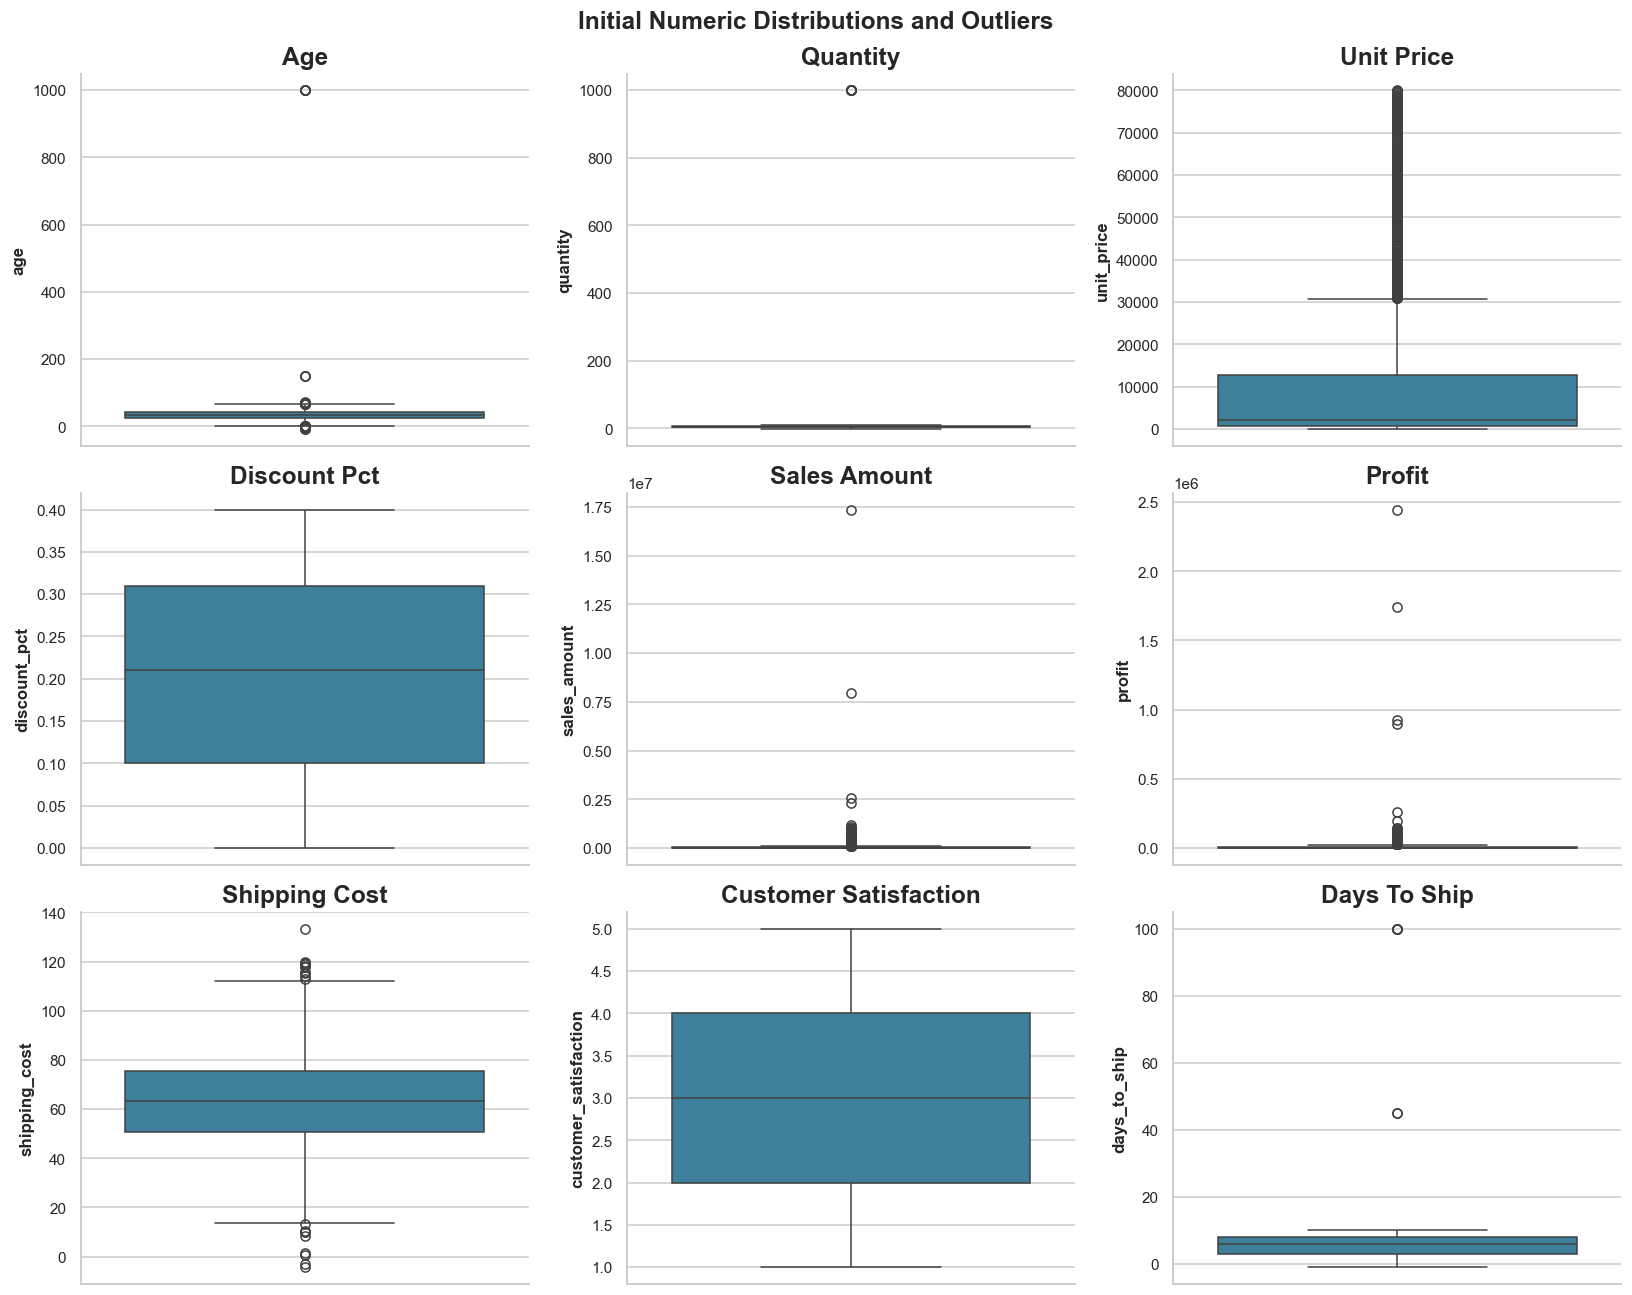

In [13]:
def plot_numeric_boxplots(data,title):

    numeric_columns = (data.select_dtypes(include=["number"]).columns.tolist())

    columns_per_row = 3

    rows = (len(numeric_columns) + columns_per_row- 1) // columns_per_row

    figure, axes = plt.subplots(rows,columns_per_row,figsize=(15,rows * 4))

    axes = np.array(axes).reshape(-1)

    for index, column in enumerate(numeric_columns):
        sns.boxplot(y=data[column],ax=axes[index],color=COLORS["blue"])

        axes[index].set_title(column.replace("_", " ").title())

    for index in range(len(numeric_columns),len(axes)):
        figure.delaxes(axes[index])

    figure.suptitle(title,fontsize=16,fontweight="bold")

    plt.tight_layout()
    plt.show()


plot_numeric_boxplots(df,"Initial Numeric Distributions and Outliers")

##### Initial Numerical Outlier Assessment

The interquartile range method and boxplots are used to identify statistically unusual numerical observations.

Statistical outliers are not automatically removed. An unusual value may represent:

1. An impossible data-entry value
2. A plausible but uncommon observation
3. A valid high-value business transaction

For example, quantity values such as 999 and shipping durations such as 100 days are treated as probable data-entry errors. In contrast, high unit prices, sales amounts, and profits may be valid for electronics or furniture orders and are retained.

#### Missing Values Analysis

##### Count Missing Values

In [14]:
df.isnull().sum()

order_id                  30
order_date                30
customer_id               30
customer_name             30
age                      160
gender                    30
region                    30
city                      30
product_category          30
product_name              30
quantity                 140
unit_price                30
discount_pct             167
sales_amount              30
profit                    30
shipping_cost             30
payment_method            30
customer_satisfaction    378
return_flag               30
order_status              30
days_to_ship             130
dtype: int64

##### Missing Value Percentage

In [15]:
missing_percentage = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({"Missing Count": df.isnull().sum(),
"Missing Percentage": missing_percentage})

missing_df = missing_df.sort_values("Missing Percentage",ascending=False)


missing_df["Missing Percentage"] = missing_df["Missing Percentage"].map(lambda x: f"{x:.2f}%")


missing_df

,Missing Count,Missing Percentage
customer_satisfaction,378,8.77%
discount_pct,167,3.87%
age,160,3.71%
quantity,140,3.25%
days_to_ship,130,3.02%
gender,30,0.70%
region,30,0.70%
city,30,0.70%
product_category,30,0.70%
product_name,30,0.70%


##### Visualize Missing Values

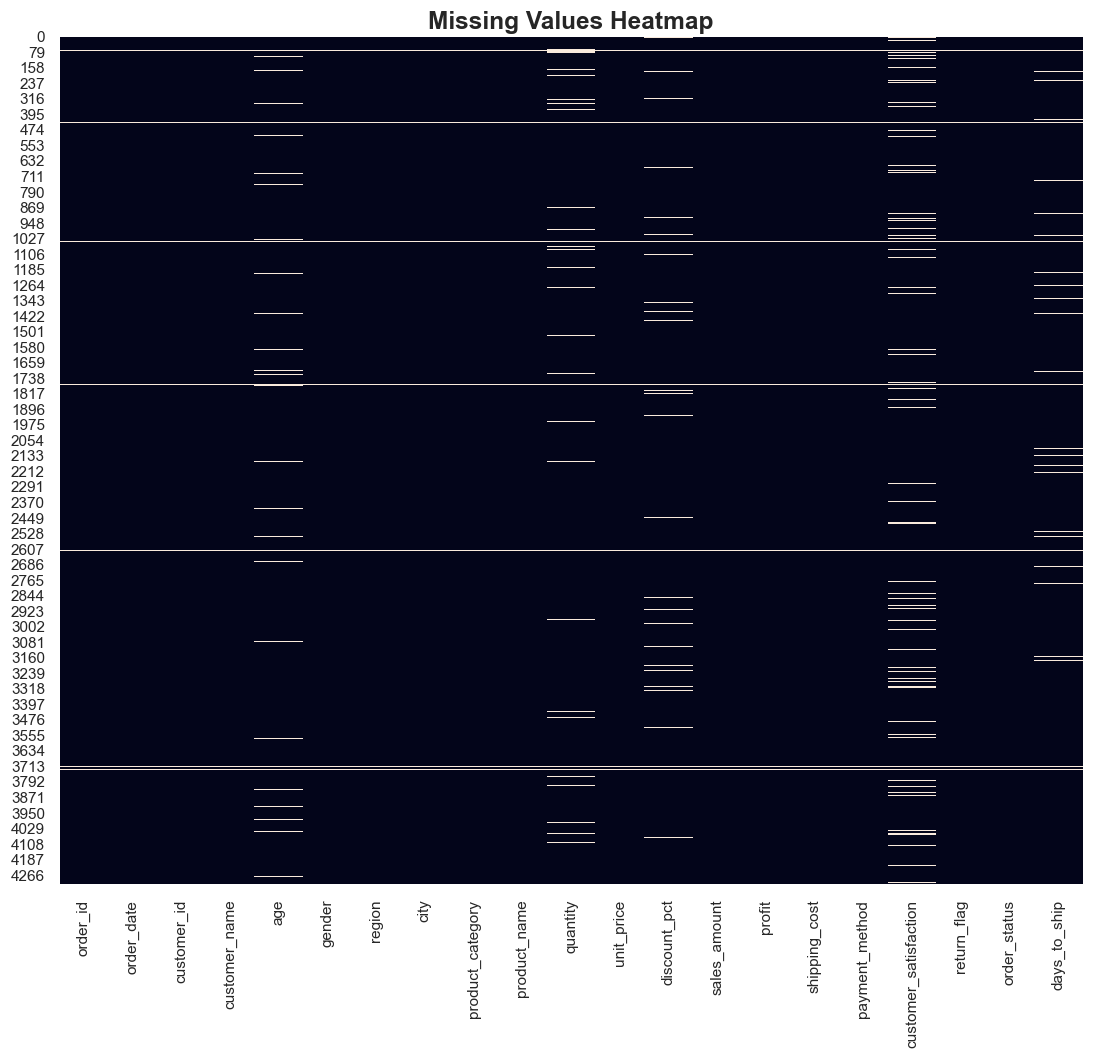

In [16]:
plt.figure(figsize=(12,10))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

##### Initial Missing-Value Analysis

Missing values are counted and expressed as a percentage of the total number of records.

The purpose of this analysis is to determine:

- Which columns contain missing information
- The extent of missingness
- Whether the missing value represents absent information, an invalid value, or an unusable record
- Whether the appropriate treatment is removal, imputation, assumption-based replacement, or retention

Customer satisfaction has the largest missing proportion. A missing rating is interpreted as feedback not being submitted, rather than a neutral rating.

#### Initial Data-Quality Assessment

The raw dataset is assessed for completeness, uniqueness, consistency, and validity.

The review identifies duplicate and empty records, missing values, mixed date formats, inconsistent categorical labels, invalid numerical values, and statistical outliers.

Statistical outliers are not removed automatically. Values are excluded only when they represent clear data-entry errors, while plausible high-value transactions are retained for analysis.

### Phase 1 Conclusion

The initial data-understanding phase identified duplicate records, completely empty rows, mixed date formats, inconsistent categorical labels, missing information, invalid numerical values, and statistical outliers.

The assessment distinguished clear data-entry errors from plausible high-value transactions. These findings defined the cleaning rules, validation checks, and feature-engineering requirements applied during Phase 2.


## 🧹 Phase 2: Data Cleaning and Feature Engineering

Phase 2 transforms the raw dataset into a validated analytical dataset.

The phase is divided into:

- **Phase 2A:** Data Cleaning
- **Phase 2B:** Feature Engineering

### Phase 2A: Data Cleaning

The cleaning process addresses duplicate records, empty rows, mixed date formats, inconsistent categories, missing values, invalid numerical values, and confirmed extreme data-entry errors.

Cleaning decisions are based on business-valid ranges, logical consistency, statistical review, analytical requirements, and documented assumptions.

Valid observations are preserved wherever possible. Complete records are removed only when a critical transaction value contains an extreme error that cannot be reliably corrected.

#### Remove Duplicate and Empty Records

Duplicate transactions can inflate order counts, sales, profit, and product-performance measures. Exact duplicate rows are therefore removed.

Completely empty records do not contain useful transaction information and are also excluded.

After these steps, the dataset contains 4,200 unique populated orders before field-level cleaning.

#### Duplicate Records Handling

##### Check Duplicate Rows

In [17]:
Duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows : {Duplicate_rows}")

Duplicate Rows : 109


##### View Duplicates

In [18]:
df[df.duplicated()]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
540,ORD-00881,2021-02-02,CUST31073,Kavya Shah,48.00,Male,East,Bhubaneswar,Groceries,Flour,7.00,474.48,0.26,"2,258.19",189.80,40.18,Debit Card,1.00,True,Returned,2.00
630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4257,ORD-00725,2020-11-29,CUST53613,Sanjay Mishra,40.00,Male,West,Ahmedabad,Groceries,Rice (5kg),7.00,486.89,0.23,"1,947.86",122.41,56.74,Debit Card,5.00,False,Delivered,4.00
4264,ORD-02348,2022-10-12,CUST12889,Rohan Mehta,27.00,Female,North,Ludhiana,Sports,Yoga Mat,9.00,"13,142.88",0.37,"69,394.08","16,164.46",32.88,UPI,5.00,True,Returned,1.00
4277,ORD-02822,2023-05-11,CUST92489,Vikram Kumar,29.00,FEMALE,North,Ludhiana,Sports,Cricket Bat,4.00,"3,625.13",0.28,"14,299.68","4,907.54",52.29,Credit Card,1.00,False,Delivered,8.00
4278,ORD-00844,2021-01-20,CUST33448,Rahul Joshi,48.00,Other,South,Hyderabad,Clothing,Saree,2.00,"2,685.53",0.16,"3,463.77","1,147.86",69.17,Cash on Delivery,2.00,True,Returned,6.00


##### Remove Duplicates

In [19]:
# Number of rows before removing duplicates
rows_before = len(df)

# Number of duplicate rows
duplicate_count = df.duplicated().sum()

# Remove duplicates
df = df.drop_duplicates()

# Number of rows after removing duplicates
rows_after = len(df)

print(f"Rows before removing duplicates : {rows_before}")
print(f"Duplicate rows found            : {duplicate_count}")
print(f"Rows after removing duplicates  : {rows_after}")
print(f"Rows removed                    : {rows_before - rows_after}")
print("Shape :",df.shape)

Rows before removing duplicates : 4310
Duplicate rows found            : 109
Rows after removing duplicates  : 4201
Rows removed                    : 109
Shape : (4201, 21)


#### Handle Empty Rows

##### Check completely empty rows

In [20]:
empty_rows = df.isnull().all(axis=1).sum()

print(f"Number of completely empty rows: {empty_rows}")


Number of completely empty rows: 1


##### Remove Completely Blank Rows

In [21]:
rows_before = len(df)


df = df.dropna(how='all')


rows_after = len(df)

print(f"Rows before removing empty rows: {rows_before}")
print(f"Rows after removing empty rows: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")



Rows before removing empty rows: 4201
Rows after removing empty rows: 4200
Rows removed: 1


##### Missing Values after removing Duplicates and blank rows 

In [22]:
df.isnull().sum()

order_id                   0
order_date                 0
customer_id                0
customer_name              0
age                      125
gender                     0
region                     0
city                       0
product_category           0
product_name               0
quantity                 108
unit_price                 0
discount_pct             135
sales_amount               0
profit                     0
shipping_cost              0
payment_method             0
customer_satisfaction    346
return_flag                0
order_status               0
days_to_ship              97
dtype: int64

#### Standardize Dates and Categorical Values

The order-date column contains ISO, day-month-year, and month-name formats. A mixed-date parser is used to convert all valid dates into a consistent datetime format.

Gender and order-status values are standardized to prevent identical categories with different capitalization or abbreviations from being analyzed separately.

The standardized order statuses are Delivered, Returned, Cancelled, Shipped, and Pending.
``

#### Handle Order Date Column Issues

##### Check Order Date Format

In [23]:
df['order_date'].sample(20)

4211    2021-07-31
1334    2022-08-20
1567    2022-05-26
3985    2022-10-08
993     2023-09-27
2551    2024-11-25
1069    2023-11-19
508     2023-03-25
929     2023-11-29
4129    2022-07-16
3275    2023-10-03
2786    2024-08-09
782     2022-05-30
1288    2020-07-12
1974    2022-02-18
3618    2020-03-31
2833    2021-12-26
260     2024-11-09
2385    2023-12-12
2777    2024-06-19
Name: order_date, dtype: object

##### Convert Date Format

In [24]:
def parse_mixed_date(value):
    if pd.isna(value):
        return pd.NaT

    value = str(value).strip()

    # Slash-formatted dates are day/month/year
    if "/" in value:
        return pd.to_datetime(value,format="%d/%m/%Y",errors="coerce")

    # Handles ISO and month-name dates
    return pd.to_datetime(value,errors="coerce")
df["order_date"] = df["order_date"].apply(parse_mixed_date)

##### Verify Conversion

In [25]:
df['order_date'].sample(20)

879    2024-12-04
110    2021-05-08
1049   2022-11-25
642    2020-10-06
537    2023-08-13
3541   2020-05-20
652    2020-02-07
1455   2024-06-01
3174   2022-05-10
96     2024-05-22
1413   2023-01-15
204    2020-08-22
23     2023-07-17
218    2023-05-12
2212   2021-12-26
1351   2021-05-14
2646   2022-03-10
3182   2020-01-19
2020   2023-02-21
2739   2023-01-07
Name: order_date, dtype: datetime64[ns]

#### Clean Gender Column

##### Check unique values

In [26]:
df['gender'].value_counts()

gender
Other     1419
Male      1178
Female    1172
male        67
MALE        61
f           55
F           53
m           53
M           49
FEMALE      48
female      45
Name: count, dtype: int64

##### Standardize Gender Values

In [27]:
df['gender'] = df['gender'].str.strip().str.lower()
gender_mapping = {'m': 'Male','male': 'Male','f': 'Female','female': 'Female','other': 'Other'}
df['gender'] = df['gender'].map(gender_mapping)

##### Verify

In [28]:
df['gender'].value_counts()

gender
Other     1419
Male      1408
Female    1373
Name: count, dtype: int64

#### Clean Order Status

##### Check Unique Order Status

In [29]:
df['order_status'].value_counts()

order_status
Delivered    2613
Returned      612
Cancelled     333
Shipped       312
Pending       178
delivered     118
shipped        15
cancelled      13
pending         6
Name: count, dtype: int64

##### Standardize Status

In [30]:
df['order_status'] = (df['order_status'].str.strip().str.title())

##### Verify

In [31]:
df['order_status'].value_counts()

order_status
Delivered    2731
Returned      612
Cancelled     346
Shipped       327
Pending       184
Name: count, dtype: int64

#### Handle Missing and Invalid Numerical Values

Numerical fields are reviewed using documented business-valid ranges.

- Customer ages outside 15 to 80 are treated as invalid.
- Missing, zero, and negative quantities are corrected before extreme quantities are reviewed.
- Negative shipping costs are treated as invalid.
- Missing and non-positive shipping durations are corrected.
- Missing discounts are interpreted as no discount and replaced with zero.

Median imputation is used where appropriate because it is less sensitive to extreme values than the mean.

#### Handle Age Issues

##### Check Age Distribution

In [32]:
df['age'].describe()

count   4,075.00
mean       35.37
std        36.00
min        -7.00
25%        26.00
50%        34.00
75%        42.00
max       999.00
Name: age, dtype: float64

##### Find Invalid Ages

In [33]:
df[(df['age'] < 15) | (df['age'] > 80)]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.00,Male,Central,Nagpur,Groceries,Cooking Oil,1.00,320.06,0.31,323.95,31.38,48.81,Net Banking,4.00,False,Pending,4.00
11,ORD-01701,2022-01-28,CUST47772,Shreya Bose,14.00,Female,West,Ahmedabad,Groceries,Dal (1kg),2.00,274.81,0.15,379.50,24.26,46.69,EMI,4.00,False,Delivered,4.00
42,ORD-00415,2020-07-01,CUST39948,Nikhil Kapoor,-6.00,Female,North,Chandigarh,Furniture,Desk,2.00,"33,115.91",0.28,"53,911.88","13,232.77",39.83,EMI,5.00,False,Delivered,1.00
44,ORD-00757,2020-12-09,CUST29818,Meera Gupta,999.00,Female,South,Kochi,Furniture,Bookshelf,4.00,"11,267.50",0.20,"24,230.41","7,321.53",70.73,UPI,4.00,False,Delivered,1.00
89,ORD-02956,2023-07-04,CUST64061,Rohan Pillai,10.00,Other,South,Chennai,Clothing,T-Shirt,9.00,"1,340.20",0.38,"12,757.93","3,852.39",105.03,Cash on Delivery,3.00,False,Cancelled,4.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4168,ORD-01529,2021-11-18,CUST01982,Meera Rao,150.00,Male,Central,Bhopal,Clothing,Dress,6.00,574.04,0.07,"2,308.91",810.17,68.91,Credit Card,3.00,False,Delivered,5.00
4185,ORD-03926,2024-08-22,CUST32277,Priya Shah,14.00,Other,North,Ludhiana,Electronics,Tablet,7.00,"56,616.08",0.37,"409,146.20","52,669.59",72.56,Net Banking,1.00,False,Delivered,9.00
4224,ORD-01682,2022-01-20,CUST60153,Meera Verma,3.00,Male,North,Chandigarh,Beauty,Sunscreen,3.00,790.57,0.33,"1,419.61",752.09,45.71,UPI,1.00,False,Delivered,2.00
4279,ORD-01453,2021-10-20,CUST65544,Aditya Verma,11.00,Other,West,Ahmedabad,Clothing,Dress,10.00,"1,794.59",0.29,"11,310.93","5,145.36",72.92,Credit Card,5.00,False,Delivered,6.00


##### Replace Invalid Ages

In [34]:
df.loc[(df['age'] < 15) | (df['age'] > 80),'age'] = np.nan

##### Fill Missing Ages

In [35]:
df['age'] = df['age'].fillna(df['age'].median())

##### Check Age Distribution

In [36]:
df['age'].describe()

count   4,200.00
mean       35.42
std        10.31
min        15.00
25%        28.00
50%        35.00
75%        42.00
max        72.00
Name: age, dtype: float64

#### Handle Quantity Issues

##### Check for Quantity Distribution

In [37]:
df['quantity'].describe()

count   4,092.00
mean        7.42
std        43.99
min        -1.00
25%         3.00
50%         5.00
75%         8.00
max       999.00
Name: quantity, dtype: float64

##### Find Invalid Quantity

In [38]:
df[(df['quantity']<=0)]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
112,ORD-03804,2024-07-12,CUST42902,Rahul Kumar,50.00,Other,South,Hyderabad,Groceries,Sugar,-1.00,84.21,0.13,125.78,8.90,47.91,Cash on Delivery,4.00,False,Delivered,2.00
179,ORD-00542,2020-08-29,CUST19508,Arjun Rao,28.00,Male,West,Pune,Electronics,Smartwatch,0.00,"9,189.44",0.19,"8,306.29",916.95,59.91,Debit Card,4.00,False,Delivered,5.00
295,ORD-00034,2020-01-12,CUST21613,Arjun Das,49.00,Other,West,Mumbai,Groceries,Flour,0.00,315.85,0.13,203.41,13.82,60.46,Cash on Delivery,5.00,False,Delivered,10.00
403,ORD-02274,2022-09-15,CUST66737,Ananya Patel,43.00,Female,South,Chennai,Clothing,T-Shirt,0.00,803.12,0.07,911.76,328.33,73.01,Credit Card,3.00,False,Delivered,7.00
914,ORD-00414,2020-07-01,CUST38493,Arjun Iyer,30.00,Other,East,Bhubaneswar,Beauty,Perfume,0.00,"1,076.68",0.32,"1,005.23",335.77,72.70,Debit Card,NaN,False,Cancelled,8.00
1081,ORD-03344,2023-12-18,CUST66556,Ananya Nair,42.00,Male,North,Chandigarh,Sports,Yoga Mat,0.00,935.36,0.06,727.57,161.08,50.09,UPI,1.00,True,Returned,3.00
1129,ORD-03770,2024-06-28,CUST96876,Nikhil Sharma,35.00,Other,South,Bangalore,Electronics,Smartwatch,-1.00,"21,887.79",0.34,"27,456.59","3,466.29",71.52,Debit Card,5.00,False,Delivered,9.00
1472,ORD-03766,2024-06-27,CUST36068,Aarav Singh,30.00,Other,East,Bhubaneswar,Clothing,Jeans,-1.00,"3,154.09",0.01,"4,594.66","1,520.00",69.59,UPI,3.00,False,Delivered,9.00
1495,ORD-01154,2021-06-02,CUST61383,Vikram Sharma,44.00,Female,South,Bangalore,Clothing,Kurta,0.00,"2,696.46",0.29,"2,622.68",977.15,101.51,EMI,2.00,False,Delivered,6.00
1527,ORD-00533,2020-08-23,CUST56679,Shreya Sharma,33.00,Other,North,Ludhiana,Clothing,Saree,-1.00,774.58,0.31,670.73,287.27,49.67,UPI,3.00,False,Delivered,6.00


##### Replace Invalid Values

In [39]:
df.loc[df["quantity"] <= 0,"quantity"] = np.nan

##### Fill Missing Quantity

In [40]:
df['quantity'] = df['quantity'].fillna(df['quantity'].median())

##### Check Quantity Distribution

In [41]:
df['quantity'].describe()

count   4,200.00
mean        7.38
std        43.42
min         1.00
25%         3.00
50%         5.00
75%         8.00
max       999.00
Name: quantity, dtype: float64

#### Handle Shipping Cost Issues

##### Check for Shipping Cost Distribution

In [42]:
df['shipping_cost'].describe()

count   4,200.00
mean       63.38
std        18.32
min        -4.29
25%        50.83
50%        63.46
75%        75.66
max       133.35
Name: shipping_cost, dtype: float64

##### Find Invalid Shipping Cost

In [43]:
df[(df['shipping_cost']<=0)]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
1878,ORD-03203,2023-10-17,CUST79007,Rahul Chatterjee,47.00,Other,North,Amritsar,Furniture,Bookshelf,5.00,"30,014.40",0.11,"131,495.05","42,093.32",-3.11,Credit Card,3.00,False,Delivered,2.00
2012,ORD-00576,2020-09-15,CUST60901,Amit Mishra,38.00,Male,North,Delhi,Furniture,Bookshelf,10.00,"2,950.98",0.23,"23,921.04","3,847.48",-4.29,Credit Card,3.00,False,Delivered,9.00


##### Replace Invalid Values

In [44]:
df.loc[df['shipping_cost'] < 0, 'shipping_cost'] = np.nan

##### Fill Missing Shipping Cost

In [45]:
df['shipping_cost'] = df['shipping_cost'].fillna(df['shipping_cost'].median())

##### Check Shipping Cost Distribution

In [46]:
df['shipping_cost'].describe()

count   4,200.00
mean       63.41
std        18.26
min         0.51
25%        50.86
50%        63.47
75%        75.66
max       133.35
Name: shipping_cost, dtype: float64

#### Handle Days to Ship Issues

##### Check for Days to Ship Distribution

In [47]:
df['days_to_ship'].describe()

count   4,103.00
mean        5.62
std         4.20
min        -1.00
25%         3.00
50%         6.00
75%         8.00
max       100.00
Name: days_to_ship, dtype: float64

##### Find Invalid Days to Ship

In [48]:
df[(df['days_to_ship']<=0)]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
159,ORD-01208,2021-06-29,CUST72453,Arjun Joshi,31.00,Male,South,Hyderabad,Furniture,Chair,6.00,"3,208.32",0.25,"24,685.74","5,146.10",81.25,UPI,4.00,False,Pending,0.00
183,ORD-04015,2024-10-01,CUST50530,Nikhil Patel,36.00,Male,North,Amritsar,Furniture,Bed Frame,5.00,"16,493.24",0.10,"95,102.09","29,222.30",63.55,Cash on Delivery,5.00,False,Delivered,-1.00
330,ORD-01775,2022-02-25,CUST42783,Ritu Das,25.00,Other,Central,Indore,Sports,Tennis Racket,1.00,"7,835.77",0.08,"6,868.24","1,599.65",44.20,Credit Card,NaN,True,Returned,-1.00
1863,ORD-02465,2022-12-05,CUST74998,Kavya Bhat,25.00,Female,North,Delhi,Clothing,Kurta,1.00,336.77,0.25,197.49,67.26,67.65,UPI,5.00,False,Delivered,0.00
2575,ORD-01571,2021-12-03,CUST56653,Nisha Sharma,30.00,Male,Central,Raipur,Clothing,T-Shirt,8.00,"3,931.30",0.21,"17,747.79","5,566.53",73.66,UPI,3.00,True,Returned,-1.00
2994,ORD-01159,2021-06-04,CUST72570,Shreya Pillai,37.00,Female,Central,Indore,Groceries,Cooking Oil,10.00,134.60,0.03,"1,594.09",134.34,105.77,Net Banking,1.00,False,Delivered,-1.00
3468,ORD-03283,2023-11-18,CUST59848,Rohan Gupta,29.00,Male,East,Kolkata,Sports,Dumbbells,4.00,"11,596.28",0.22,"32,114.67","7,605.77",87.57,Cash on Delivery,1.00,False,Shipped,-1.00


##### Replace Invalid Values

In [49]:
df.loc[df['days_to_ship'] <= 0, 'days_to_ship'] = np.nan

##### Fill Missing Shipping Duration


In [50]:
df['days_to_ship'] = df['days_to_ship'].fillna(df['days_to_ship'].median())

##### Validate Shipping-Duration Distribution


In [51]:
df['days_to_ship'].describe()

count   4,200.00
mean        5.64
std         4.14
min         1.00
25%         3.00
50%         6.00
75%         8.00
max       100.00
Name: days_to_ship, dtype: float64

#### Handle Missing Values in 'discount_pct'

##### Fill Missing Values in Discount

In [52]:
df['discount_pct'] = df['discount_pct'].fillna(0)

#### Handle Customer Satisfaction Issues

Customer-satisfaction values are validated against the permitted rating scale of 1 to 5.

Missing ratings are retained rather than imputed because a customer who did not provide feedback should not be interpreted as giving a neutral rating.

A separate rating-status feature classifies each order as Rated or Not Rated.

##### Convert satisfaction to numeric

In [53]:
df["customer_satisfaction"] = pd.to_numeric(df["customer_satisfaction"],errors="coerce")

##### Replace invalid ratings with missing

In [54]:
df.loc[~df["customer_satisfaction"].between(1, 5),"customer_satisfaction"] = np.nan

##### Create Rating Response Status Column

In [55]:
df["rating_status"] = np.where(df["customer_satisfaction"].notna(),"Rated","Not Rated")

##### Validate Customer Satisfaction and Rating Status Column

In [56]:
print("Valid ratings:",df['customer_satisfaction'].count())
print(df["customer_satisfaction"].value_counts().sort_index())
print("Not Rated:",df["customer_satisfaction"].isnull().sum())
print("\nRating status:")
print(df["rating_status"].value_counts())

Valid ratings: 3854
customer_satisfaction
1.00    761
2.00    763
3.00    748
4.00    810
5.00    772
Name: count, dtype: int64
Not Rated: 346

Rating status:
rating_status
Rated        3854
Not Rated     346
Name: count, dtype: int64


#### Handle Quantity Outliers


##### Check for Outliers in Quantity

In [57]:
quantity_outliers = df[df['quantity'] > 15.5]
print("\nNumber of Quantity Outliers:", len(quantity_outliers))


Number of Quantity Outliers: 8


##### Show Quantity Outliers

In [58]:
quantity_outliers

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,rating_status
242,ORD-00751,2020-12-07,CUST41385,Rohan Patel,32.00,Male,North,Amritsar,Books,Cook Book,999.00,403.63,0.15,"203,951.50","80,603.27",48.70,EMI,5.00,False,Delivered,1.00,Rated
1012,ORD-01242,2021-07-14,CUST50699,Rohan Chatterjee,16.00,Female,East,Patna,Books,Self-Help Book,999.00,545.25,0.02,"729,651.06","258,878.20",54.26,Debit Card,4.00,False,Delivered,2.00,Rated
1112,ORD-00539,2020-08-25,CUST19345,Ananya Pillai,53.00,Other,Central,Indore,Clothing,Jacket,999.00,"2,567.40",0.31,"2,281,458.22","899,209.60",74.46,EMI,3.00,False,Delivered,5.00,Rated
1138,ORD-01025,2021-04-09,CUST16923,Nisha Bhat,36.00,Male,North,Amritsar,Sports,Tennis Racket,999.00,"9,380.72",0.29,"7,936,261.20","1,739,854.00",72.62,Net Banking,4.00,False,Delivered,4.00,Rated
1700,ORD-00689,2020-11-08,CUST06352,Sunita Singh,43.00,Other,North,Delhi,Groceries,Rice (5kg),999.00,195.29,0.10,"140,042.31","9,617.93",60.48,Credit Card,NaN,False,Delivered,7.00,Not Rated
2178,ORD-01732,2022-02-08,CUST51801,Shreya Gupta,18.00,Male,South,Bangalore,Books,Fiction Novel,999.00,709.64,0.16,"533,420.31","141,347.64",82.77,Debit Card,2.00,True,Returned,2.00,Rated
2582,ORD-00809,2021-01-05,CUST99388,Ritu Kapoor,33.00,Male,South,Chennai,Clothing,Jeans,999.00,"3,280.13",0.03,"2,586,345.13","921,794.60",83.69,EMI,1.00,True,Returned,7.00,Rated
3865,ORD-02560,2023-01-14,CUST90788,Kavya Kapoor,35.00,Female,South,Kochi,Electronics,Tablet,999.00,"18,619.45",0.00,"17,360,314.17","2,445,648.43",82.19,EMI,1.00,False,Delivered,5.00,Rated


##### Drop Rows with Quantity Outliers

In [59]:
rows_before = len(df)
df = df[df['quantity'] <= 15.5]
rows_after = len(df)
print("Rows Before:", rows_before)
print("Rows After :", rows_after)
print("Rows Removed:", rows_before - rows_after)

Rows Before: 4200
Rows After : 4192
Rows Removed: 8


#### Handle Shipping-Duration Outliers


##### Check for Outliers in Days to Ship

In [60]:
daystoship_outliers = df[df['days_to_ship'] > 15.5]
print("\nNumber of Outliers in Days to Ship:", len(daystoship_outliers))


Number of Outliers in Days to Ship: 6


##### Show Days to Ship Outliers

In [61]:
daystoship_outliers

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,rating_status
57,ORD-00357,2020-06-02,CUST75375,Priya Joshi,41.00,Female,Central,Nagpur,Clothing,Jeans,2.00,"1,548.43",0.38,"2,480.54",866.50,49.01,EMI,1.00,False,Delivered,45.00,Rated
929,ORD-03303,2023-11-29,CUST73772,Nisha Reddy,15.00,Male,East,Kolkata,Electronics,Tablet,1.00,"19,475.10",0.27,"12,588.84","1,124.34",70.91,Net Banking,NaN,False,Delivered,100.00,Not Rated
2226,ORD-01210,2021-06-30,CUST18457,Rohan Das,35.00,Female,Central,Raipur,Furniture,Wardrobe,3.00,"21,424.67",0.06,"89,031.36","26,411.55",50.15,Debit Card,4.00,False,Delivered,100.00,Rated
2803,ORD-01340,2021-08-24,CUST16922,Deepa Gupta,32.00,Female,South,Chennai,Beauty,Hair Oil,4.00,154.86,0.33,476.99,235.99,64.40,Debit Card,3.00,False,Delivered,100.00,Rated
2866,ORD-01918,2022-04-28,CUST04256,Ananya Bhat,35.00,Male,South,Bangalore,Electronics,Smartphone,6.00,"39,743.58",0.06,"290,848.39","32,188.69",78.10,UPI,5.00,False,Delivered,45.00,Rated
3504,ORD-00470,2020-07-26,CUST56203,Rohan Mehta,47.00,Other,East,Patna,Books,Comic Book,8.00,744.90,0.28,"6,083.41","2,337.37",84.44,Debit Card,2.00,False,Delivered,100.00,Rated


##### Drop Rows with Days to Ship Outliers

In [62]:
rows_before = len(df)
df = df[df['days_to_ship'] <= 15.5]
rows_after = len(df)
print("Rows Before:", rows_before)
print("Rows After :", rows_after)
print("Rows Removed:", rows_before - rows_after)

Rows Before: 4192
Rows After : 4186
Rows Removed: 6


#### Post-Cleaning Validation

Automated checks are applied to verify that the cleaning process produced a complete and internally consistent transaction dataset.

The validation confirms:

- 4,186 final records
- No duplicate rows
- Unique and complete order IDs
- Complete and valid order dates
- Ages between 15 and 80
- Quantities between 1 and 10
- Positive unit prices and sales amounts
- Discounts between 0 and 1
- Non-negative shipping costs
- Satisfaction values between 1 and 5 or missing
- Shipping durations between 1 and 10 days

##### Verify missing values and Duplicates

In [63]:
df.isnull().sum()

order_id                   0
order_date                 0
customer_id                0
customer_name              0
age                        0
gender                     0
region                     0
city                       0
product_category           0
product_name               0
quantity                   0
unit_price                 0
discount_pct               0
sales_amount               0
profit                     0
shipping_cost              0
payment_method             0
customer_satisfaction    344
return_flag                0
order_status               0
days_to_ship               0
rating_status              0
dtype: int64

In [64]:
duplicate_count = df.duplicated().sum()
duplicate_order_ids = df['order_id'].duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Duplicate Order IDs: {duplicate_order_ids}")

Number of duplicate rows: 0
Duplicate Order IDs: 0


##### Dataset Information

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4186 entries, 0 to 4309
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               4186 non-null   object        
 1   order_date             4186 non-null   datetime64[ns]
 2   customer_id            4186 non-null   object        
 3   customer_name          4186 non-null   object        
 4   age                    4186 non-null   float64       
 5   gender                 4186 non-null   object        
 6   region                 4186 non-null   object        
 7   city                   4186 non-null   object        
 8   product_category       4186 non-null   object        
 9   product_name           4186 non-null   object        
 10  quantity               4186 non-null   float64       
 11  unit_price             4186 non-null   float64       
 12  discount_pct           4186 non-null   float64       
 13  sales_am

##### Summary Including Categorical Columns

In [66]:
df.describe(include='all')

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,rating_status
count,4186,4186,4186,4186,"4,186.00",4186,4186,4186,4186,4186,"4,186.00","4,186.00","4,186.00","4,186.00","4,186.00","4,186.00",4186,"3,842.00",4186,4186,"4,186.00",4186
unique,4186,NaN,4099,400,NaN,3,5,20,7,42,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,2,5,NaN,2
top,ORD-03903,NaN,CUST00213,Priya Verma,NaN,Other,West,Amritsar,Clothing,Shampoo,NaN,NaN,NaN,NaN,NaN,NaN,UPI,NaN,False,Delivered,NaN,Rated
freq,1,NaN,3,21,NaN,1416,869,234,629,115,NaN,NaN,NaN,NaN,NaN,NaN,748,NaN,3576,2719,NaN,3842
mean,NaN,2022-07-07 16:34:51.543239168,NaN,NaN,35.43,NaN,NaN,NaN,NaN,NaN,5.49,"10,710.15",0.20,"55,445.97","10,262.55",63.39,NaN,3.02,NaN,NaN,5.54,NaN
min,NaN,2020-01-01 00:00:00,NaN,NaN,15.00,NaN,NaN,NaN,NaN,NaN,1.00,50.26,0.00,39.45,1.56,0.51,NaN,1.00,NaN,NaN,1.00,NaN
25%,NaN,2021-04-21 00:00:00,NaN,NaN,28.00,NaN,NaN,NaN,NaN,NaN,3.00,681.23,0.09,"2,469.16",704.97,50.84,NaN,2.00,NaN,NaN,3.00,NaN
50%,NaN,2022-07-16 00:00:00,NaN,NaN,35.00,NaN,NaN,NaN,NaN,NaN,5.00,"2,246.01",0.20,"9,595.14","3,146.63",63.46,NaN,3.00,NaN,NaN,6.00,NaN
75%,NaN,2023-09-28 18:00:00,NaN,NaN,42.00,NaN,NaN,NaN,NaN,NaN,8.00,"12,823.62",0.30,"50,071.29","10,421.60",75.65,NaN,4.00,NaN,NaN,8.00,NaN
max,NaN,2024-12-30 00:00:00,NaN,NaN,72.00,NaN,NaN,NaN,NaN,NaN,10.00,"79,957.92",0.40,"1,182,709.24","198,109.98",133.35,NaN,5.00,NaN,NaN,10.00,NaN


##### Sample Dataset

In [67]:
df.sample(20)

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship,rating_status
3960,ORD-02363,2022-10-18,CUST91997,Karan Bose,38.00,Male,West,Surat,Electronics,Laptop,5.00,"5,729.21",0.26,"21,082.56","2,258.77",47.72,Net Banking,4.00,False,Cancelled,8.00,Rated
2837,ORD-00373,2020-06-08,CUST27217,Nisha Gupta,35.00,Male,Central,Raipur,Furniture,Desk,4.00,"26,538.28",0.28,"110,728.91","35,173.48",70.37,UPI,3.00,False,Delivered,5.00,Rated
478,ORD-00781,2020-12-21,CUST92097,Nisha Gupta,44.00,Male,South,Hyderabad,Sports,Cycle,8.00,"12,540.64",0.16,"54,877.82","12,900.73",44.66,UPI,1.00,False,Delivered,8.00,Rated
2132,ORD-03994,2024-09-20,CUST52703,Nisha Iyer,36.00,Other,East,Patna,Beauty,Sunscreen,3.00,"1,494.83",0.26,"3,664.34","2,210.93",96.38,Net Banking,1.00,False,Delivered,8.00,Rated
615,ORD-03243,2023-11-02,CUST21449,Rahul Bose,36.00,Other,Central,Nagpur,Furniture,Bed Frame,6.00,"12,617.99",0.05,"66,859.47","19,527.70",32.57,Debit Card,4.00,False,Delivered,9.00,Rated
1161,ORD-01156,2021-06-03,CUST97655,Sanjay Kapoor,45.00,Female,North,Amritsar,Groceries,Sugar,2.00,346.78,0.30,705.38,68.49,0.51,Net Banking,1.00,False,Delivered,2.00,Rated
1372,ORD-03019,2023-07-31,CUST46142,Nisha Mehta,30.00,Other,West,Pune,Clothing,Kurta,2.00,"1,744.92",0.39,"3,236.74","1,198.84",44.94,Credit Card,3.00,True,Returned,7.00,Rated
3915,ORD-02796,2023-04-27,CUST56780,Arjun Chatterjee,24.00,Other,East,Guwahati,Groceries,Cooking Oil,8.00,132.40,0.32,"1,145.95",93.32,91.90,Debit Card,2.00,False,Delivered,2.00,Rated
1581,ORD-00173,2020-03-16,CUST46878,Sunita Mishra,33.00,Female,East,Bhubaneswar,Books,Biography,8.00,"1,355.07",0.25,"7,286.92","3,585.80",86.98,Debit Card,4.00,False,Shipped,5.00,Rated
2238,ORD-00081,2020-01-29,CUST60867,Deepa Sharma,35.00,Male,Central,Indore,Electronics,Laptop,9.00,"61,637.72",0.29,"298,694.87","29,985.13",20.79,EMI,4.00,False,Cancelled,5.00,Rated


##### Outliers After Cleaning

In [68]:
post_cleaning_outlier_summary = (create_outlier_summary(df))
display(post_cleaning_outlier_summary)

,Column,Minimum,Q1,Q3,Maximum,Lower Bound,Upper Bound,Lower Outliers,Upper Outliers,Total Outliers
0,age,15.00,28.00,42.00,72.00,7.00,63.00,0,25,25
1,quantity,1.00,3.00,8.00,10.00,-4.50,15.50,0,0,0
2,unit_price,50.26,681.23,"12,823.62","79,957.92","-17,532.37","31,037.21",0,466,466
3,discount_pct,0.00,0.09,0.30,0.40,-0.23,0.61,0,0,0
4,sales_amount,39.45,"2,469.16","50,071.29","1,182,709.24","-68,934.03","121,474.48",0,581,581
5,profit,1.56,704.97,"10,421.60","198,109.98","-13,869.98","24,996.55",0,542,542
6,shipping_cost,0.51,50.84,75.65,133.35,13.64,112.86,7,10,17
7,customer_satisfaction,1.00,2.00,4.00,5.00,-1.00,7.00,0,0,0
8,days_to_ship,1.00,3.00,8.00,10.00,-4.50,15.50,0,0,0


##### Outlier Visualization

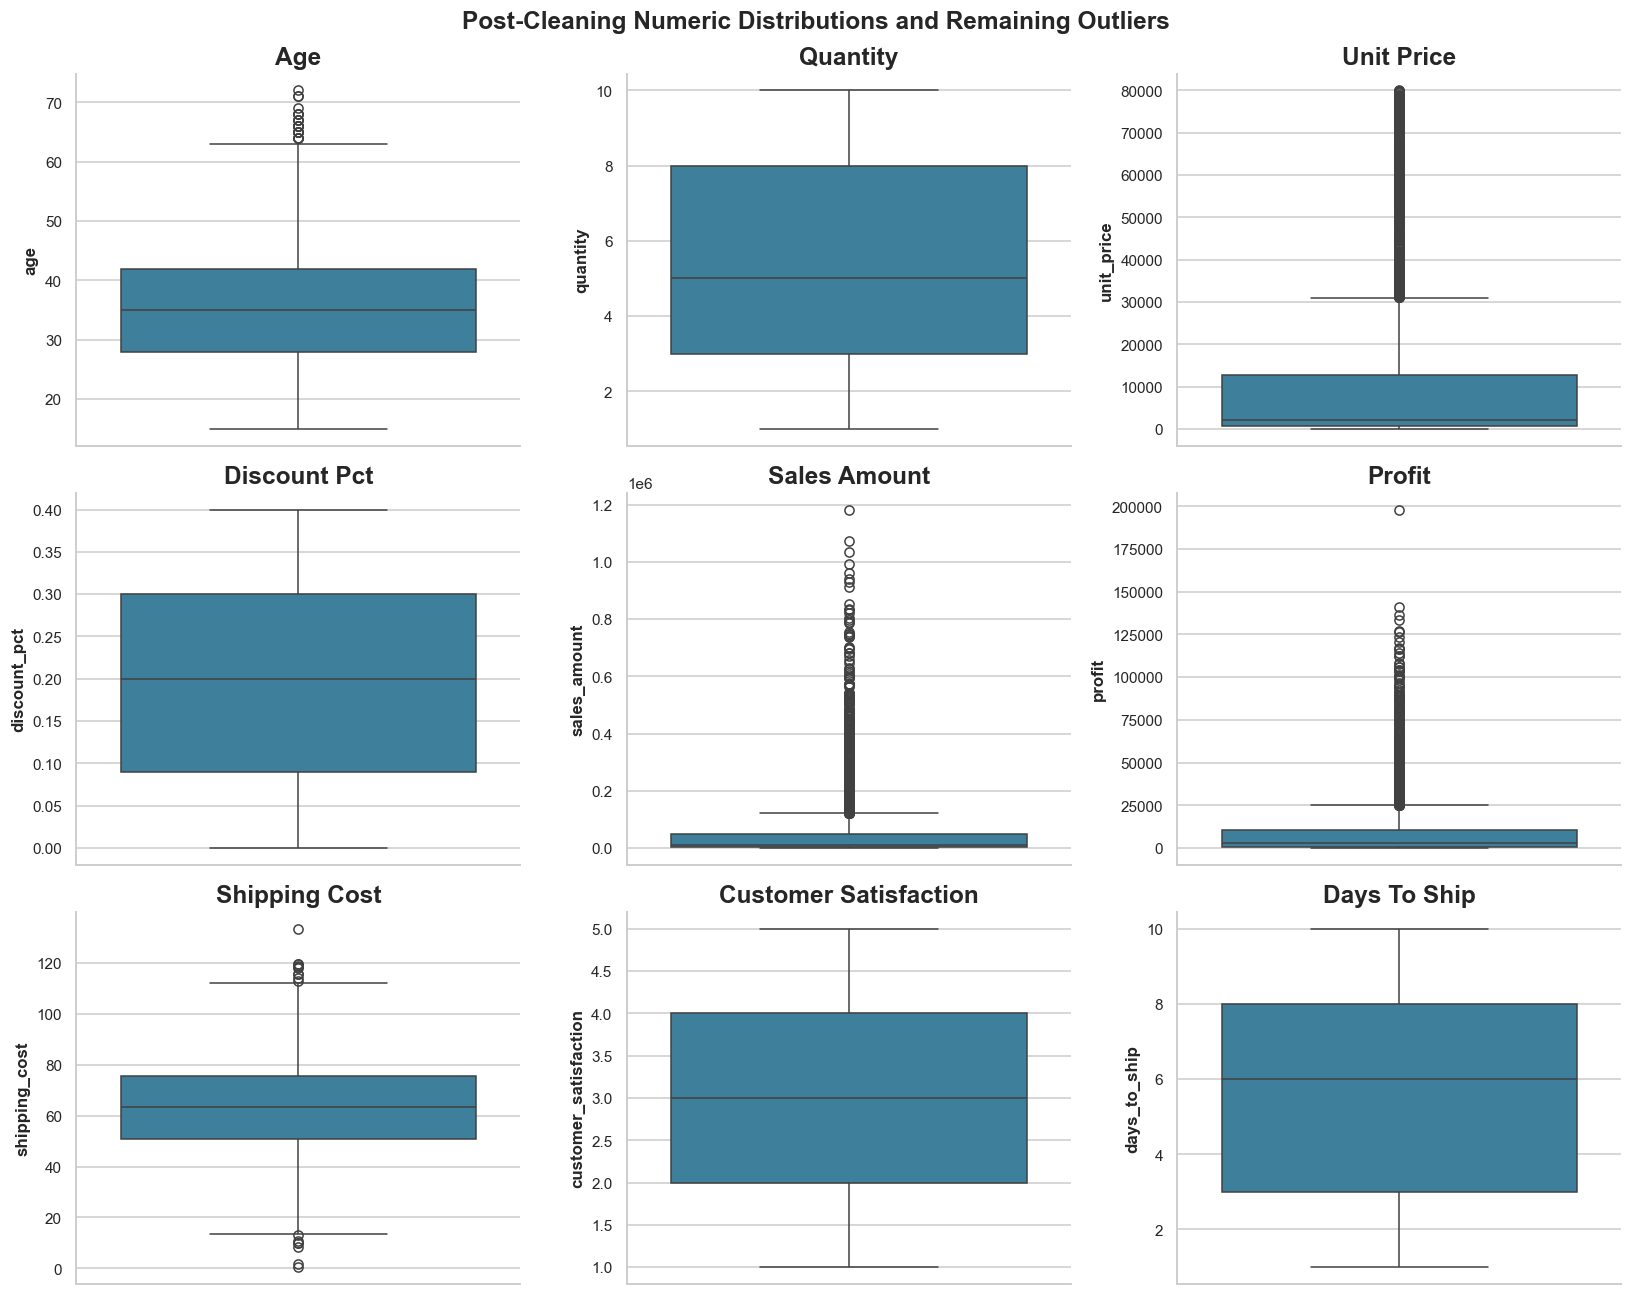

In [69]:
plot_numeric_boxplots(df,"Post-Cleaning Numeric Distributions and Remaining Outliers")

##### Final Validation

In [70]:
validation_results = {"Final row count is 4,186":len(df) == 4186,
    "No duplicate rows":df.duplicated().sum() == 0,
    "Order IDs are unique":df["order_id"].is_unique,
    "No missing order IDs":df["order_id"].notna().all(),
    "All dates are valid":df["order_date"].notna().all(),
    "Age is between 15 and 80":df["age"].between(15, 80).all(),
    "Quantity is between 1 and 10":df["quantity"].between(1, 10).all(),
    "Unit prices are positive":df["unit_price"].gt(0).all(),
    "Discount is between 0 and 1":df["discount_pct"].between(0, 1).all(),
    "Sales amounts are positive":df["sales_amount"].gt(0).all(),
    "Shipping costs are non-negative":df["shipping_cost"].ge(0).all(),
    "Satisfaction is 1-5 or missing":df["customer_satisfaction"].dropna().between(1, 5).all(),
    "Shipping duration is 1-10 days":df["days_to_ship"].between(1, 10).all()}

validation_table = pd.Series(validation_results,name="Passed").to_frame()
display(validation_table)
assert all(validation_results.values())

,Passed
"Final row count is 4,186",True
No duplicate rows,True
Order IDs are unique,True
No missing order IDs,True
All dates are valid,True
Age is between 15 and 80,True
Quantity is between 1 and 10,True
Unit prices are positive,True
Discount is between 0 and 1,True
Sales amounts are positive,True



#### Phase 2A: Cleaning Conclusion

The data-cleaning phase was completed successfully, and all final validation checks passed.

The raw dataset contained duplicate records, fully empty rows, mixed date formats, inconsistent categorical values, missing information, invalid numerical values, and extreme data-entry errors. These issues were systematically identified, treated, and validated.

##### Cleaning Results

- The final dataset contains 4,186 valid and unique order records.
- Duplicate rows and duplicate order IDs were removed.
- Fully empty records were excluded.
- Mixed order-date formats were converted into a consistent datetime format.
- Gender and order-status categories were standardized.
- Invalid and missing age values were treated while retaining valid customers aged 15 and above.
- Missing, zero, negative, and extreme quantity values were addressed.
- Negative shipping costs and invalid shipping durations were treated.
- Missing discounts were interpreted as no discount and replaced with zero.
- Missing customer-satisfaction responses were retained and classified as Not Rated.
- Extreme invalid quantity and shipping-duration records were excluded.
- Legitimate high-value monetary observations were retained because transaction values differ substantially across product categories.

##### Final Data-Quality Status

The final dataset has:

- No duplicate rows
- Unique and complete order IDs
- Complete and valid order dates
- Valid customer ages
- Quantities between 1 and 10
- Positive unit prices and sales amounts
- Discounts between 0 and 1
- Non-negative shipping costs
- Shipping durations between 1 and 10 days
- Customer-satisfaction values between 1 and 5 or missing

The dataset is now clean, internally consistent, and ready for feature engineering and exploratory data analysis.


### Phase 2B: Feature Engineering

Feature engineering creates analytical variables from the cleaned transaction data.

Only features directly required for the planned exploratory analysis are included. The original transaction fields are retained, and unsupported financial assumptions are avoided because the dataset is synthetic.

The engineered features support:

- Chronological analysis
- Seasonal analysis
- Customer demographic comparisons
- Discount analysis
- Profitability analysis
- Shipping analysis
- Return and cancellation analysis
- Customer-feedback coverage

#### Time and Analytical Segments

Time-based features are created for monthly, quarterly, weekday, and weekend analysis.

Continuous age, discount, and shipping-duration values are also grouped into business-friendly segments to simplify comparisons across customer groups, promotional levels, and shipping performance.

The original numerical columns are retained for distributional and correlation analysis.

#### Date and Time Features

##### Create New Columns

In [71]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()
df['quarter'] = df['order_date'].dt.quarter
df["year_month"] = (df["order_date"].dt.to_period("M").astype(str))
df["day_of_week"] = (df["order_date"].dt.day_name())
df["is_weekend"] = (df["order_date"].dt.dayofweek >= 5)

##### Validation

In [72]:
assert df["year"].between(2020, 2024).all()
assert df["month"].between(1, 12).all()

df[["order_date","year","quarter","month","month_name","year_month","day_of_week","is_weekend"]].sample(10)

,order_date,year,quarter,month,month_name,year_month,day_of_week,is_weekend
2156,2022-07-27,2022,3,7,July,2022-07,Wednesday,False
2399,2020-09-24,2020,3,9,September,2020-09,Thursday,False
1864,2024-12-25,2024,4,12,December,2024-12,Wednesday,False
2724,2021-11-18,2021,4,11,November,2021-11,Thursday,False
1242,2024-02-05,2024,1,2,February,2024-02,Monday,False
2340,2022-05-28,2022,2,5,May,2022-05,Saturday,True
3425,2024-11-27,2024,4,11,November,2024-11,Wednesday,False
1798,2023-07-29,2023,3,7,July,2023-07,Saturday,True
484,2022-10-29,2022,4,10,October,2022-10,Saturday,True
3967,2023-12-09,2023,4,12,December,2023-12,Saturday,True


#### Customer Segmentation

##### Age Grouped

In [73]:
age_bins = [14,24,34,44,54,64,80]
age_labels = ["15-24","25-34","35-44","45-54","55-64","65+"]
df["age_group"] = pd.cut(df["age"],bins=age_bins,labels=age_labels,include_lowest=True)

##### Validation

In [74]:
assert df["age_group"].notna().all()
df["age_group"].value_counts(dropna=False).sort_index()

age_group
15-24     617
25-34    1253
35-44    1511
45-54     622
55-64     162
65+        21
Name: count, dtype: int64

#### Discount Segmentation

##### Create Discount Bands

In [75]:
discount_bins = [-0.001,0,0.10,0.20,0.30,1.00]
discount_labels = ["No Discount","1-10%","11-20%","21-30%","Above 30%"]
df["discount_band"] = pd.cut(df["discount_pct"],bins=discount_bins,labels=discount_labels,include_lowest=True)

##### Validation

In [76]:
display(df.groupby("discount_band",observed=True)["discount_pct"].agg(orders="count",minimum_discount="min",maximum_discount="max"))
assert df["discount_band"].notna().all()

,orders,minimum_discount,maximum_discount
discount_band,,,
No Discount,178,0.00,0.00
1-10%,1026,0.01,0.10
11-20%,943,0.11,0.20
21-30%,1019,0.21,0.30
Above 30%,1020,0.31,0.40


#### Shipping-Speed Segmentation

##### Create Shipping Speed Band

In [77]:
shipping_bins = [0,2,5,7,10]
shipping_labels = ["Fast: 1-2 Days","Standard: 3-5 Days","Moderate: 6-7 Days","Slow: 8-10 Days"]
df["shipping_speed"] = pd.cut(df["days_to_ship"],bins=shipping_bins,labels=shipping_labels,include_lowest=True)

##### Validation

In [78]:
display(df.groupby("shipping_speed",observed=True).agg(orders=("order_id", "nunique"),minimum_days=("days_to_ship", "min"),maximum_days=("days_to_ship", "max")))
assert df["shipping_speed"].notna().all()

,orders,minimum_days,maximum_days
shipping_speed,,,
Fast: 1-2 Days,787,1.00,2.00
Standard: 3-5 Days,1237,3.00,5.00
Moderate: 6-7 Days,912,6.00,7.00
Slow: 8-10 Days,1250,8.00,10.00


#### Operational Status Indicators

Boolean indicators are created for delivered, returned, and cancelled orders to simplify operational KPI calculations.

Shipped and pending orders remain available through the original order-status column because separate indicators are not required for the planned analysis.

##### Status Columns Creation

In [79]:
df["is_delivered"] = (df["order_status"] == "Delivered")
df["is_returned"] = (df["return_flag"].astype(bool)| df["order_status"].eq("Returned"))
df["is_cancelled"] = (df["order_status"] == "Cancelled")

##### Validation

In [80]:
status_validation = pd.DataFrame({"Indicator": ["Delivered","Returned","Cancelled"],"Orders": [df["is_delivered"].sum(),df["is_returned"].sum(),df["is_cancelled"].sum()]})
display(status_validation)

,Indicator,Orders
0,Delivered,2719
1,Returned,610
2,Cancelled,346


#### Profit Margin Percentage

Profit margin percentage is calculated as recorded profit divided by recorded sales amount, multiplied by 100.

This feature allows profitability to be compared across products, categories, regions, discount levels, and periods. Absolute profit alone may favor high-value categories, while profit margin reflects profit relative to sales.

Because the data is synthetic, no additional assumptions are introduced about product cost, tax, shipping allocation, or accounting treatment.

##### Profit margin percentage

In [81]:
df["profit_margin_pct"] = np.where(df["sales_amount"] > 0,(df["profit"]/ df["sales_amount"]* 100),np.nan)

##### Validation

In [82]:
display(df["profit_margin_pct"].describe())
print("Missing profit margins:",df["profit_margin_pct"].isna().sum())
assert df["profit_margin_pct"].notna().all()

count   4,186.00
mean       27.02
std        14.26
min         2.24
25%        13.23
50%        26.78
75%        37.76
max        70.95
Name: profit_margin_pct, dtype: float64

Missing profit margins: 0


#### Phase 2B: Feature Engineering Conclusion

The feature-engineering phase was completed using a focused set of analytical variables required for exploratory analysis.

- Time-based features support monthly, seasonal, weekday, and weekend analysis.
- Age groups support customer demographic comparisons.
- Discount bands support promotional-performance analysis.
- Shipping-speed groups support logistics, satisfaction, and return analysis.
- Delivered, returned, and cancelled indicators support operational KPI calculations.
- Rating status distinguishes rated and unrated orders.
- Profit margin percentage supports comparable profitability analysis across different business segments.

All engineered features were validated successfully, with no missing values or unclassified records introduced. The original transaction columns were retained, and unsupported financial assumptions were avoided because the dataset is synthetic.

The dataset is now ready for non-visual and visual exploratory data analysis.

### Phase 2 Conclusion

Phase 2 was completed successfully.

The raw dataset contained 4,310 records with duplicate rows, empty records, mixed date formats, inconsistent categories, missing information, invalid numerical values, and extreme data-entry errors.

After cleaning, the final dataset contains 4,186 valid and unique orders. All critical identifiers, dates, customer attributes, product information, transaction values, order statuses, and shipping fields passed the final validation checks.

A focused set of analytical features was created for time-series, customer demographic, discount, profitability, shipping, order-status, and customer-feedback analysis. All engineered features were validated without introducing missing or unclassified values.

Legitimate monetary outliers were retained because product categories have substantially different transaction-value ranges. Unsupported financial calculations were avoided because the source dataset is synthetic.

The prepared dataset is ready for Phase 3 exploratory data analysis.

## 📈 Phase 3: Exploratory Data Analysis

Phase 3 evaluates commercial scale, profitability quality, customer experience, product performance, geographic contribution, discount effectiveness, fulfillment, and order-outcome risk.

The analysis is divided into:

- **Phase 3A:** Non-Visual Exploratory Data Analysis
- **Phase 3B:** Visual Exploratory Data Analysis

### 🧭 Phase 3 Overview

The exploratory analysis translates the prepared dataset into management-focused performance evidence.

The analysis combines scorecards, summary tables, statistical distributions, interactive visuals, geographic analysis, executive interpretations, recommendations, decisions, and monitoring KPIs.

### 📐 Analytical Standards

The following standards are applied throughout the exploratory analysis:

- Recorded sales and recorded profit are analyzed as supplied by the dataset.
- Weighted margin is calculated as total recorded profit divided by total recorded sales.
- Satisfaction averages exclude orders without valid ratings.
- Rating coverage is reported alongside customer satisfaction.
- Return and cancellation rates use unique prepared order records.
- Financial values associated with different order statuses are not treated as accounting-recognized revenue.
- Statistical and visual relationships are descriptive and do not establish causality.
- Executive recommendations remain subject to management review and validation using actual business data.

##### Helper functions

In [83]:
import re

def weighted_profit_margin(data):
    """Calculate weighted profit margin as total profit divided by total sales."""
    total_sales_value = float(data["sales_amount"].sum())
    total_profit_value = float(data["profit"].sum())

    if total_sales_value == 0:
        return np.nan
    return total_profit_value / total_sales_value * 100

def rating_coverage(values):
    """Calculate the percentage of records with a valid rating."""
    return float(values.notna().mean() * 100)

def percentage_of_true(values):
    """Calculate the percentage of True values in a Boolean field."""
    return float(values.mean() * 100)

def format_currency(value):
    """Format a numeric value as INR currency."""
    return f"INR {float(value):,.2f}"

def format_percentage(value):
    """Format a numeric value as a percentage."""
    return f"{float(value):,.2f}%"

def format_card_text(value):
    """Escape HTML while preserving Markdown-style bold text and line breaks."""
    formatted_value = html.escape(str(value).strip())
    formatted_value = re.sub(r"\*\*(.*?)\*\*", r"<strong>\1</strong>", formatted_value)
    formatted_value = formatted_value.replace("\n\n", "<br><br>")
    formatted_value = formatted_value.replace("\n", " ")
    return formatted_value

def display_executive_card(
    card_title,
    finding,
    implication,
    recommendation,
    decision,
    monitoring_kpis,
    interpretation_note=None,
    decision_owner=None,
    decision_horizon=None,
):
    """Display a standardized analyst-to-executive assessment card."""
    kpi_items = "".join(
        f"<li>{format_card_text(kpi)}</li>" for kpi in monitoring_kpis
    )

    owner_section = ""
    if decision_owner:
        owner_section = f"""
        <div style="background-color:#F8F9FA;border-left:5px solid #2E86AB;padding:14px 18px;margin-top:14px;border-radius:6px;">
            <strong>👤 Suggested Decision Owner</strong>
            <p style="margin:6px 0 0 0;">{format_card_text(decision_owner)}</p>
        </div>"""

    horizon_section = ""
    if decision_horizon:
        horizon_section = f"""
        <div style="background-color:#F8F9FA;border-left:5px solid #6C5CE7;padding:14px 18px;margin-top:14px;border-radius:6px;">
            <strong>⏱️ Decision Horizon</strong>
            <p style="margin:6px 0 0 0;">{format_card_text(decision_horizon)}</p>
        </div>"""

    note_section = ""
    if interpretation_note:
        note_section = f"""
        <div style="background-color:#FFF8E7;border-left:5px solid #F4B942;padding:14px 18px;margin-top:14px;border-radius:6px;">
            <strong>⚠️ Interpretation Note</strong>
            <p style="margin:6px 0 0 0;">{format_card_text(interpretation_note)}</p>
        </div>"""

    executive_card = f"""
    <div style="border:1px solid #D0D5DD;border-radius:10px;padding:20px;margin:18px 0 32px 0;background-color:#FFFFFF;box-shadow:0 3px 10px rgba(0,0,0,0.06);font-family:Arial,sans-serif;line-height:1.5;">
        <div style="background-color:#17324D;color:white;padding:14px 18px;margin:-20px -20px 18px -20px;border-radius:10px 10px 0 0;font-size:18px;font-weight:bold;">
            {format_card_text(card_title)}
        </div>
        <div style="background-color:#EEF6FA;border-left:5px solid #2E86AB;padding:14px 18px;margin-bottom:14px;border-radius:6px;">
            <strong>🔎 Analytical Finding</strong>
            <p style="margin:6px 0 0 0;">{format_card_text(finding)}</p>
        </div>
        <div style="background-color:#F0F9F7;border-left:5px solid #1B998B;padding:14px 18px;margin-bottom:14px;border-radius:6px;">
            <strong>💼 Executive Implication</strong>
            <p style="margin:6px 0 0 0;">{format_card_text(implication)}</p>
        </div>
        <div style="background-color:#F6F2FF;border-left:5px solid #6C5CE7;padding:14px 18px;margin-bottom:14px;border-radius:6px;">
            <strong>🎯 Analyst Recommendation</strong>
            <p style="margin:6px 0 0 0;">{format_card_text(recommendation)}</p>
        </div>
        <div style="background-color:#FFF1F3;border-left:5px solid #D1495B;padding:14px 18px;margin-bottom:14px;border-radius:6px;">
            <strong>✅ Executive Decision Required</strong>
            <p style="margin:6px 0 0 0;">{format_card_text(decision)}</p>
        </div>
        <div style="background-color:#F8F9FA;border-left:5px solid #667085;padding:14px 18px;border-radius:6px;">
            <strong>📌 Monitoring KPIs</strong>
            <ul style="margin:8px 0 0 20px;">{kpi_items}</ul>
        </div>
        {owner_section}
        {horizon_section}
        {note_section}
    </div>"""

    display(HTML(executive_card))


def display_nonvisual_interpretation(
    analysis_title,
    finding,
    implication,
    recommendation,
    decision,
    monitoring_kpis,
    interpretation_note=None,
    decision_owner=None,
    decision_horizon=None,
):
    """Display a non-visual executive assessment card."""
    display_executive_card(
        card_title=f"Executive Assessment | {analysis_title}",
        finding=finding,
        implication=implication,
        recommendation=recommendation,
        decision=decision,
        monitoring_kpis=monitoring_kpis,
        interpretation_note=interpretation_note,
        decision_owner=decision_owner,
        decision_horizon=decision_horizon,
    )

def display_visual_interpretation(
    visual_title,
    finding,
    implication,
    recommendation,
    decision,
    monitoring_kpis,
    interpretation_note=None,
):
    """Display a visual executive interpretation card."""
    display_executive_card(
        card_title=f"Executive Interpretation | {visual_title}",
        finding=finding,
        implication=implication,
        recommendation=recommendation,
        decision=decision,
        monitoring_kpis=monitoring_kpis,
        interpretation_note=interpretation_note,
    )


### 📋 Phase 3A: Non-Visual Exploratory Data Analysis

The non-visual analysis evaluates commercial scale, profitability, annual growth, product categories, regional performance, discount effectiveness, fulfillment, and order-status exposure.

Each analysis contains:

- A defined executive question
- A management-oriented scorecard or summary table
- 🔎 Analytical finding
- 💼 Executive implication
- 🎯 Analyst recommendation
- ✅ Executive decision required
- 📌 Monitoring KPIs
- ⚠️ Interpretation note, where required

The analysis is prepared by the analyst for presentation to top management and executive stakeholders.

Because the dataset is synthetic, findings are directional and should be validated using actual operational and financial data before implementation.

#### 📏 Non-Visual Analysis Standards

The following standards are applied throughout the non-visual EDA:

- Every analysis addresses a defined executive question.
- Recorded sales and recorded profit are analyzed as supplied by the dataset.
- Group-level weighted profit margin is calculated as total profit divided by total sales.
- Customer-satisfaction averages exclude orders without valid ratings.
- Rating coverage is reported together with average satisfaction.
- Return and cancellation rates are calculated using unique prepared order records.
- Recorded values associated with different order statuses are not interpreted as accounting-recognized or realized revenue.
- Relationships identified during the analysis are descriptive and do not establish causality.
- Recommendations are presented by the analyst for executive consideration.
- Final implementation decisions remain with top management.

#### 📋 Non-Visual Analysis 1: Executive KPI Scorecard

**Executive Question:** What is the overall commercial, profitability, order-outcome, customer-experience, and fulfillment position of the prepared dataset?

**Business Purpose:** Establish the executive performance baseline against which annual, category, regional, discount, and order-status results are evaluated.

**Analysis Coverage:**

- Recorded sales and recorded profit
- Weighted profit margin
- Average order value
- Delivery, return, and cancellation rates
- Customer satisfaction and rating coverage
- Average shipping duration

In [84]:
total_orders = int(df["order_id"].nunique())
total_customers = int(df["customer_id"].nunique())
total_sales = float(df["sales_amount"].sum())
total_profit = float(df["profit"].sum())
weighted_margin = float(weighted_profit_margin(df))
average_order_value = float(df["sales_amount"].mean())
delivery_rate = float(df["is_delivered"].mean() * 100)
return_rate = float(df["is_returned"].mean() * 100)
cancellation_rate = float(df["is_cancelled"].mean() * 100)
average_satisfaction = float(df["customer_satisfaction"].mean())
rating_coverage_pct = float(df["customer_satisfaction"].notna().mean()*100)
average_shipping_days = float(df["days_to_ship"].mean())
executive_scorecard = pd.DataFrame({"KPI": ["Total Orders","Unique Customers","Recorded Sales","Recorded Profit","Weighted Profit Margin",
                                            "Average Order Value","Delivery Rate","Return Rate","Cancellation Rate","Average Satisfaction",
                                            "Rating Coverage","Average Shipping Days"],
    "Value": [f"{total_orders:,}",f"{total_customers:,}",format_currency(total_sales),format_currency(total_profit),format_percentage(weighted_margin),
         format_currency(average_order_value),format_percentage(delivery_rate),format_percentage(return_rate),format_percentage(cancellation_rate),
        f"{average_satisfaction:.2f} / 5",
        format_percentage(rating_coverage_pct),
        f"{average_shipping_days:.2f} days"]})

display(executive_scorecard)

,KPI,Value
0,Total Orders,"4,186"
1,Unique Customers,"4,099"
2,Recorded Sales,"INR 232,096,851.11"
3,Recorded Profit,"INR 42,959,036.96"
4,Weighted Profit Margin,18.51%
5,Average Order Value,"INR 55,445.97"
6,Delivery Rate,64.95%
7,Return Rate,14.57%
8,Cancellation Rate,8.27%
9,Average Satisfaction,3.02 / 5


In [85]:
executive_finding = f""" The prepared dataset contains **{total_orders:,} unique orders** from **{total_customers:,} customers**, generating **{format_currency(total_sales)}** in recorded sales and **{format_currency(total_profit)}** in recorded profit. 
The overall weighted profit margin is **{weighted_margin:.2f}%**, and the average order value is **{format_currency(average_order_value)}**.

The delivery rate is **{delivery_rate:.2f}%**, while the return and cancellation rates are **{return_rate:.2f}%** and **{cancellation_rate:.2f}%**, respectively.

Average satisfaction is **{average_satisfaction:.2f} out of 5**, based on rating coverage of **{rating_coverage_pct:.2f}%**. Average shipping duration is **{average_shipping_days:.2f} days**."""

executive_implication = """Recorded sales alone do not represent the overall quality of business performance.

Profitability, returns, cancellations, incomplete order statuses, shipping performance, customer satisfaction, and feedback coverage should be reviewed together when evaluating overall performance. """

executive_recommendation = """ The analyst recommends implementing a recurring executive scorecard that combines commercial scale, profitability quality, order outcomes, fulfillment performance, customer satisfaction, and rating coverage. 

Delivered and non-Delivered order activity should be clearly separated in executive reporting.
"""

executive_decision = """ Top management should approve formal KPI targets, departmental ownership, reporting frequency, escalation criteria, and the treatment of different order statuses in management reporting. """

executive_monitoring_kpis = ["Monthly recorded sales",
    "Monthly recorded profit",
    "Weighted profit margin",
    "Average order value",
    "Delivery rate",
    "Return rate",
    "Cancellation rate",
    "Pending and Shipped order share",
    "Average shipping duration",
    "Average satisfaction",
    "Rating coverage"]


display_nonvisual_interpretation( analysis_title="Executive KPI Scorecard", finding=executive_finding, implication=executive_implication, recommendation=executive_recommendation, decision=executive_decision, monitoring_kpis=executive_monitoring_kpis, decision_owner=( "Executive Committee, supported by Finance, Commercial, " "Operations, Supply Chain, and Customer Experience"),
    decision_horizon=( "Immediate governance decision, followed by monthly monitoring" ),
    interpretation_note=( "Recorded financial values are analyzed as supplied by the " "synthetic dataset and do not represent audited performance."))

#### 📈 Non-Visual Analysis 2: Annual Performance and Growth

**Executive Question:** Are changes in annual recorded sales supported by corresponding changes in recorded profit, order volume, and weighted margin?

**Business Purpose:** Distinguish commercial growth from profitable and sustainable growth and identify years requiring deeper contribution analysis.

**Analysis Coverage:**

- Annual orders and customers
- Recorded sales and profit
- Average order value
- Weighted profit margin
- Year-over-year sales, profit, and order growth
- Customer satisfaction and shipping performance

In [86]:
annual_performance = (df.groupby("year", as_index=False).agg(orders=("order_id", "nunique"),
        customers=("customer_id", "nunique"),
        recorded_sales=("sales_amount", "sum"),
        recorded_profit=("profit", "sum"),
        average_order_value=("sales_amount", "mean"),
        average_satisfaction=("customer_satisfaction", "mean"),
        rating_coverage_pct=("customer_satisfaction", rating_coverage),
        average_shipping_days=("days_to_ship", "mean"),
        return_rate_pct=("is_returned", percentage_of_true),
        cancellation_rate_pct=("is_cancelled", percentage_of_true),).sort_values("year").reset_index(drop=True))

annual_performance["weighted_profit_margin_pct"] = np.where(annual_performance["recorded_sales"] > 0,annual_performance["recorded_profit"] / annual_performance["recorded_sales"] * 100,np.nan,)
annual_performance["sales_growth_pct"] = annual_performance["recorded_sales"].pct_change().mul(100)
annual_performance["profit_growth_pct"] = annual_performance["recorded_profit"].pct_change().mul(100)
annual_performance["order_growth_pct"] = annual_performance["orders"].pct_change().mul(100)
annual_performance["customer_growth_pct"] = annual_performance["customers"].pct_change().mul(100)

display(annual_performance.round(2))


,year,orders,customers,recorded_sales,recorded_profit,average_order_value,average_satisfaction,rating_coverage_pct,average_shipping_days,return_rate_pct,cancellation_rate_pct,weighted_profit_margin_pct,sales_growth_pct,profit_growth_pct,order_growth_pct,customer_growth_pct
0,2020,799,793,"38,421,256.26","6,993,962.96","48,086.68",3.08,91.61,5.48,14.89,8.51,18.20,NaN,NaN,NaN,NaN
1,2021,831,826,"46,304,351.14","8,300,238.17","55,721.24",2.94,92.18,5.58,16.49,7.70,17.93,20.52,18.68,4.01,4.16
2,2022,881,877,"49,521,848.66","9,397,223.68","56,210.95",3.02,92.05,5.40,14.98,7.83,18.98,6.95,13.22,6.02,6.17
3,2023,854,853,"47,157,566.98","8,951,386.03","55,219.63",2.94,91.80,5.63,12.88,9.60,18.98,-4.77,-4.74,-3.06,-2.74
4,2024,821,819,"50,691,828.07","9,316,226.12","61,744.00",3.12,91.23,5.60,13.64,7.67,18.38,7.49,4.08,-3.86,-3.99


In [87]:
highest_sales_row = annual_performance.loc[annual_performance["recorded_sales"].idxmax()]
highest_profit_row = annual_performance.loc[annual_performance["recorded_profit"].idxmax()]
highest_margin_row = annual_performance.loc[annual_performance["weighted_profit_margin_pct"].idxmax()]
latest_year_row = annual_performance.loc[    annual_performance["year"].idxmax()]

annual_finding = f""" **{int(highest_sales_row['year'])}** records the highest annual sales at **{format_currency(highest_sales_row['recorded_sales'])}**.

**{int(highest_profit_row['year'])}** records the highest annual profit at **{format_currency(highest_profit_row['recorded_profit'])}**.

**{int(highest_margin_row['year'])}** records the highest weighted margin at **{highest_margin_row['weighted_profit_margin_pct']:.4f}%**.

In **{int(latest_year_row['year'])}**, recorded sales changed by **{latest_year_row['sales_growth_pct']:.2f}%**, while recorded profit changed by **{latest_year_row['profit_growth_pct']:.2f}%** and order volume changed by **{latest_year_row['order_growth_pct']:.2f}%**.

The latest-year average order value was **{format_currency(latest_year_row['average_order_value'])}**. """


annual_implication = f""" The difference between latest-year sales growth of **{latest_year_row['sales_growth_pct']:.2f}%** and profit growth of **{latest_year_row['profit_growth_pct']:.2f}%** indicates that the sales movement did not translate proportionately into recorded profit.

Because order volume changed by **{latest_year_row['order_growth_pct']:.2f}%**, the sales movement was also influenced by average order value and transaction mix. """


annual_recommendation = """ The analyst recommends a year-over-year contribution analysis covering product category, product, region, discount band, average order value, returns, cancellations, weighted profit margin, and high-value-order concentration. """


annual_decision = """ Top management should determine whether the next-period priority is sales growth, profit recovery, margin protection, product-mix improvement, return reduction, or reduced dependence on high-value transactions. """


annual_monitoring_kpis = ["Year-over-year sales growth",
    "Year-over-year profit growth",
    "Weighted annual profit margin",
    "Order growth",
    "Customer growth",
    "Average order value",
    "Category contribution to sales",
    "Category contribution to profit",
    "Annual return rate",
    "Annual cancellation rate",
    "High-value order concentration"]


display_nonvisual_interpretation(analysis_title="Annual Performance and Growth",
    finding=annual_finding,
    implication=annual_implication,
    recommendation=annual_recommendation,
    decision=annual_decision,
    monitoring_kpis=annual_monitoring_kpis,
    decision_owner=("Executive Committee, Finance, Commercial, and Category Management"),
    decision_horizon=("Near term: use findings in the next planning and target-setting cycle"),
    interpretation_note=("Annual sales growth should not be interpreted as profitable growth without reviewing recorded profit, weighted margin, order volume, and average order value."))

#### 📦 Non-Visual Analysis 3: Product-Category Performance

**Executive Question:** Which product categories provide the strongest balance of commercial scale, profitability, customer experience, and manageable order-outcome risk?

**Business Purpose:** Support category investment, portfolio prioritization, growth testing, and corrective-action decisions.

**Analysis Coverage:**

- Orders and units sold
- Recorded sales and recorded profit
- Sales and profit contribution
- Weighted profit margin
- Average order value
- Customer satisfaction and rating coverage
- Return and cancellation rates

In [88]:
category_performance = (df.groupby("product_category",observed=True).agg(orders=("order_id", "nunique"),
        units_sold=("quantity", "sum"),recorded_sales=("sales_amount", "sum"),recorded_profit=("profit", "sum"),
        average_order_value=("sales_amount", "mean"),average_satisfaction=("customer_satisfaction","mean"),
        rating_coverage_pct=("customer_satisfaction",lambda values:values.notna().mean() * 100),
        return_rate_pct=("is_returned",lambda values:values.mean() * 100),
        cancellation_rate_pct=("is_cancelled",lambda values:values.mean() * 100)))

category_performance["weighted_profit_margin_pct"] = (category_performance["recorded_profit"] / category_performance["recorded_sales"] * 100)
category_performance["sales_share_pct"] = (category_performance[ "recorded_sales"] / category_performance[ "recorded_sales"].sum() * 100)
category_performance["profit_share_pct"] = (category_performance["recorded_profit"]/ category_performance["recorded_profit"].sum()* 100)
category_performance = (category_performance.sort_values("recorded_sales",ascending=False))

display(category_performance.round(2))

,orders,units_sold,recorded_sales,recorded_profit,average_order_value,average_satisfaction,rating_coverage_pct,return_rate_pct,cancellation_rate_pct,weighted_profit_margin_pct,sales_share_pct,profit_share_pct
product_category,,,,,,,,,,,,
Electronics,605,"3,386.00","137,978,826.17","16,628,515.11","228,064.18",3.00,92.56,15.87,7.44,12.05,59.45,38.71
Furniture,575,"3,292.00","56,620,171.67","15,979,321.50","98,469.86",3.03,91.65,13.74,9.22,28.22,24.40,37.20
Sports,613,"3,220.00","23,750,404.28","5,251,269.66","38,744.54",2.91,93.15,15.50,6.36,22.11,10.23,12.22
Clothing,629,"3,397.00","6,693,451.86","2,359,330.65","10,641.42",3.07,91.10,13.83,9.70,35.25,2.88,5.49
Beauty,600,"3,266.00","3,880,611.86","1,748,481.38","6,467.69",3.04,92.83,13.83,7.50,45.06,1.67,4.07
Books,558,"3,044.00","2,304,407.75","922,535.27","4,129.76",3.11,88.35,13.44,9.50,40.03,0.99,2.15
Groceries,606,"3,374.00","868,977.52","69,583.39","1,433.96",2.98,92.57,15.68,8.25,8.01,0.37,0.16


In [89]:
highest_sales_category = (category_performance["recorded_sales" ].idxmax())
highest_profit_category = (category_performance[ "recorded_profit"].idxmax())
highest_margin_category = (category_performance["weighted_profit_margin_pct"].idxmax())
lowest_margin_category = (category_performance["weighted_profit_margin_pct"].idxmin())
highest_return_category = (category_performance["return_rate_pct"].idxmax())
highest_cancellation_category = (category_performance["cancellation_rate_pct"].idxmax())
highest_satisfaction_category = (category_performance[ "average_satisfaction"].idxmax())


category_finding = f"""**{highest_sales_category}** leads category sales at
**{format_currency(category_performance.loc[highest_sales_category, 'recorded_sales'])}** and contributes **{category_performance.loc[highest_sales_category, 'sales_share_pct']:.2f}%**  of total recorded sales.

**{highest_profit_category}** leads recorded profit at **{format_currency(category_performance.loc[highest_profit_category, 'recorded_profit'])}**.

**{highest_margin_category}** records the strongest weighted margin at **{category_performance.loc[highest_margin_category, 'weighted_profit_margin_pct']:.2f}%**, while **{lowest_margin_category}** records the lowest margin at **{category_performance.loc[lowest_margin_category, 'weighted_profit_margin_pct']:.2f}%**.

**{highest_return_category}** has the highest return rate at **{category_performance.loc[highest_return_category, 'return_rate_pct']:.2f}%**, while **{highest_cancellation_category}** has the highest cancellation rate.

**{highest_satisfaction_category}** records the highest average customer satisfaction among rated orders."""

category_implication = """The category with the greatest commercial scale is not necessarily the category with the strongest profitability quality.

Category investment decisions should consider sales contribution, profit contribution, weighted margin, returns, cancellations, customer feedback, and order value together."""

category_recommendation = f"""
The analyst recommends protecting profitable growth in **{highest_profit_category}**, evaluating controlled growth opportunities in **{highest_margin_category}**, and conducting product-level root-cause analysis within **{highest_return_category}**.

**{lowest_margin_category}** should be reviewed for pricing, sourcing, product mix, discounting, and fulfillment economics."""

category_decision = """Top management should approve category investment priorities, margin targets, return-reduction ownership, cancellation-reduction ownership, controlled growth tests, and corrective-action plans for weaker categories."""

category_monitoring_kpis = ["Recorded sales by category",
    "Recorded profit by category",
    "Sales and profit contribution",
    "Weighted category profit margin",
    "Average order value",
    "Units sold",
    "Return rate",
    "Cancellation rate",
    "Average satisfaction",
    "Rating coverage",
    "Product contribution within each category"]


display_nonvisual_interpretation(analysis_title="Product-Category Performance",
    finding=category_finding,
    implication=category_implication,
    recommendation=category_recommendation,
    decision=category_decision,
    monitoring_kpis=category_monitoring_kpis,
    decision_owner=("Category Management and Commercial, supported by Operations, Supply Chain, and Customer Experience"),
    decision_horizon=("Immediate review for high-return or low-margin categories; controlled growth decisions within 1 to 3 months"),
    interpretation_note=("Category investment should not be based on recorded sales alone. Profit, weighted margin, returns, cancellations, and customer experience must be reviewed together."))

#### 🌐 Non-Visual Analysis 4: Regional Operating Performance

**Executive Question:** Which regions combine commercial strength, profitability, customer experience, and operational performance most effectively?

**Business Purpose:** Identify regional growth opportunities, operating constraints, shipping-cost exposure, and areas requiring management intervention.

**Analysis Coverage:**

- Orders and customers
- Recorded sales and recorded profit
- Regional sales contribution
- Weighted profit margin
- Average order value
- Shipping cost and shipping duration
- Customer satisfaction and rating coverage
- Return and cancellation rates

In [90]:
regional_performance = (df.groupby("region",observed=True).agg(orders=("order_id", "nunique"),customers=("customer_id", "nunique"),
        recorded_sales=("sales_amount", "sum"),recorded_profit=("profit", "sum"),average_order_value=("sales_amount", "mean"),
        average_shipping_cost=("shipping_cost", "mean"),average_shipping_days=("days_to_ship", "mean"),
        average_satisfaction=("customer_satisfaction","mean"),
        rating_coverage_pct=("customer_satisfaction",lambda values:values.notna().mean()* 100),
        return_rate_pct=("is_returned",lambda values:values.mean()* 100),
        cancellation_rate_pct=( "is_cancelled",lambda values:values.mean() * 100)))
regional_performance["weighted_profit_margin_pct"] = (regional_performance["recorded_profit"]/ regional_performance["recorded_sales"]* 100)
regional_performance["sales_share_pct"] = (regional_performance["recorded_sales"] / regional_performance[ "recorded_sales"].sum() * 100)
regional_performance = (regional_performance.sort_values("recorded_sales",ascending=False))

display(regional_performance.round(2))

,orders,customers,recorded_sales,recorded_profit,average_order_value,average_shipping_cost,average_shipping_days,average_satisfaction,rating_coverage_pct,return_rate_pct,cancellation_rate_pct,weighted_profit_margin_pct,sales_share_pct
region,,,,,,,,,,,,,
South,861,856,"52,747,688.84","9,720,758.89","61,263.29",69.94,5.51,3.08,90.94,15.56,8.36,18.43,22.73
West,869,860,"47,962,618.16","8,862,052.09","55,192.89",59.87,5.58,2.94,92.52,14.61,7.59,18.48,20.66
East,830,828,"47,753,228.54","8,471,075.65","57,534.01",80.39,5.60,3.12,91.81,13.13,8.19,17.74,20.57
North,845,843,"45,332,775.15","8,547,486.86","53,648.25",51.20,5.45,3.01,91.48,15.38,8.28,18.85,19.53
Central,781,779,"38,300,540.42","7,357,663.47","49,040.38",55.23,5.55,2.94,92.19,14.08,8.96,19.21,16.50


In [91]:
highest_sales_region = (regional_performance["recorded_sales"].idxmax())
highest_profit_region = (regional_performance["recorded_profit"].idxmax())
highest_margin_region = (regional_performance["weighted_profit_margin_pct"].idxmax())
lowest_margin_region = (regional_performance["weighted_profit_margin_pct"].idxmin())
slowest_shipping_region = (regional_performance["average_shipping_days"].idxmax())
fastest_shipping_region = (regional_performance["average_shipping_days"].idxmin())
highest_shipping_cost_region = (regional_performance["average_shipping_cost"].idxmax())
highest_return_region = (regional_performance["return_rate_pct"].idxmax())
highest_cancellation_region = (regional_performance["cancellation_rate_pct"].idxmax())
highest_satisfaction_region = (regional_performance["average_satisfaction"].idxmax())
slowest_days = regional_performance.loc[slowest_shipping_region,"average_shipping_days"]
fastest_days = regional_performance.loc[fastest_shipping_region,"average_shipping_days"]
shipping_day_difference = (slowest_days- fastest_days)

regional_finding = f"""**{highest_sales_region}** leads regional sales at **{format_currency(regional_performance.loc[highest_sales_region, 'recorded_sales'])}** and contributes **{regional_performance.loc[highest_sales_region, 'sales_share_pct']:.2f}%** of total recorded sales.

**{highest_profit_region}** records the highest regional profit, while **{highest_margin_region}** records the strongest weighted margin at **{regional_performance.loc[highest_margin_region, 'weighted_profit_margin_pct']:.2f}%**.

**{lowest_margin_region}** records the lowest regional weighted margin.

**{slowest_shipping_region}** has the longest average shipping duration at **{slowest_days:.2f} days**, compared with **{fastest_days:.2f} days** in **{fastest_shipping_region}**. The difference is only **{shipping_day_difference:.2f} days**.

**{highest_shipping_cost_region}** records the highest average shipping cost, **{highest_return_region}** records the highest return rate, and **{highest_cancellation_region}** records the highest cancellation rate.

**{highest_satisfaction_region}** has the highest average satisfaction among rated orders."""

regional_implication = """No region leads across every measure.

The regional shipping-duration difference is relatively small. Shipping cost, weighted margin, returns, cancellations, customer satisfaction, category mix, and city mix provide stronger points of differentiation."""

regional_recommendation = f"""The analyst recommends protecting commercial momentum in **{highest_sales_region}**, reviewing shipping economics in **{highest_shipping_cost_region}**, investigating return drivers in **{highest_return_region}**, and assessing controlled growth in **{highest_margin_region}**.

Regional findings should be validated through category-level and city-level analysis."""


regional_decision = """Top management should determine regional investment priorities, assign ownership for shipping-cost, return, and cancellation improvements, and approve regional margin and service targets."""


regional_monitoring_kpis = ["Regional recorded sales",
    "Regional recorded profit",
    "Regional sales contribution",
    "Weighted regional profit margin",
    "Average order value",
    "Average shipping cost",
    "Average shipping duration",
    "Return rate",
    "Cancellation rate",
    "Average satisfaction",
    "Rating coverage",
    "Category and city contribution"]


display_nonvisual_interpretation(analysis_title="Regional Operating Performance",
    finding=regional_finding,
    implication=regional_implication,
    recommendation=regional_recommendation,
    decision=regional_decision,
    monitoring_kpis=regional_monitoring_kpis,
    decision_owner=("Regional Management and Operations, supported by Commercial, Supply Chain, and Finance"),
    decision_horizon=("Near term: complete regional diagnostic within 1 to 3 months"),
    interpretation_note=("Regional differences may also reflect product-category and city mix. Regional actions should be validated through category-level and city-level analysis."))

#### 🏷️ Non-Visual Analysis 5: Discount Effectiveness

**Executive Question:** Which discount bands provide the strongest balance of commercial scale, profitability, order value, customer experience, and manageable return exposure?

**Business Purpose:** Support discount governance and determine whether deeper discounting is associated with stronger commercial outcomes or greater operating risk.

**Analysis Coverage:**

- Orders and order share
- Recorded sales and recorded profit
- Weighted profit margin
- Average order value
- Customer satisfaction and rating coverage
- Return and cancellation rates

In [92]:
discount_effectiveness = (df.groupby("discount_band",observed=True).agg(orders=("order_id","nunique"),recorded_sales=("sales_amount","sum"),
        recorded_profit=("profit","sum"),average_order_value=("sales_amount","mean"),average_satisfaction=("customer_satisfaction","mean"),
        rating_coverage_pct=("customer_satisfaction",lambda values:values.notna().mean() * 100),
        return_rate_pct=("is_returned",lambda values:values.mean() * 100),cancellation_rate_pct=("is_cancelled",lambda values:values.mean() * 100)))
discount_effectiveness["weighted_profit_margin_pct"] = (discount_effectiveness["recorded_profit"]/ discount_effectiveness["recorded_sales"]* 100)
discount_effectiveness["order_share_pct"] = (discount_effectiveness["orders"] / discount_effectiveness["orders"].sum() * 100)

display(discount_effectiveness.round(2))


,orders,recorded_sales,recorded_profit,average_order_value,average_satisfaction,rating_coverage_pct,return_rate_pct,cancellation_rate_pct,weighted_profit_margin_pct,order_share_pct
discount_band,,,,,,,,,,
No Discount,178,"15,264,010.46","2,803,841.72","85,752.87",3.09,92.13,8.99,7.30,18.37,4.25
1-10%,1026,"61,399,505.79","11,316,075.59","59,843.57",3.05,91.62,13.26,8.38,18.43,24.51
11-20%,943,"57,539,431.62","10,800,581.31","61,017.42",3.00,93.11,14.42,7.74,18.77,22.53
21-30%,1019,"57,382,392.94","10,552,313.71","56,312.46",2.97,91.66,16.49,8.83,18.39,24.34
Above 30%,1020,"40,511,510.30","7,486,224.63","39,717.17",3.03,90.78,15.10,8.24,18.48,24.37


In [93]:
highest_sales_discount = (discount_effectiveness["recorded_sales"].idxmax())
highest_profit_discount = (discount_effectiveness["recorded_profit"].idxmax())
highest_margin_discount = (discount_effectiveness[ "weighted_profit_margin_pct"].idxmax())
lowest_margin_discount = (discount_effectiveness[ "weighted_profit_margin_pct"].idxmin())
highest_order_value_discount = (discount_effectiveness["average_order_value"].idxmax())
lowest_order_value_discount = (discount_effectiveness["average_order_value"].idxmin())
highest_return_discount = (discount_effectiveness["return_rate_pct"].idxmax())
highest_cancellation_discount = (discount_effectiveness["cancellation_rate_pct"].idxmax())
highest_satisfaction_discount = (discount_effectiveness["average_satisfaction"].idxmax())
maximum_discount_margin = (discount_effectiveness[ "weighted_profit_margin_pct"].max())
minimum_discount_margin = (discount_effectiveness["weighted_profit_margin_pct"].min())
discount_margin_range = (maximum_discount_margin- minimum_discount_margin)

discount_finding = f"""The **{highest_sales_discount}** discount band generates the highest recorded sales at **{format_currency(discount_effectiveness.loc[highest_sales_discount, 'recorded_sales'])}** and also generates the highest recorded profit.

The **{highest_margin_discount}** band records the strongest weighted margin at **{maximum_discount_margin:.2f}%**.

However, the difference between the highest and lowest discount-band margins is only **{discount_margin_range:.2f} percentage points**.

The **{highest_order_value_discount}** band has the highest average order value, while **{lowest_order_value_discount}** has the lowest.

The **{highest_return_discount}** band has the highest return rate at **{discount_effectiveness.loc[highest_return_discount, 'return_rate_pct']:.2f}%**, and **{highest_cancellation_discount}** has the highest cancellation rate.

**{highest_satisfaction_discount}** records the highest average satisfaction among rated orders."""


discount_implication = """Weighted margins are relatively similar across discount bands. The more material differences are commercial scale, average order value, returns, cancellations, customer satisfaction, and product-category mix.

The results do not demonstrate that discounting caused the observed performance differences."""


discount_recommendation = f"""The analyst recommends using category-specific discount policies and applying additional review to **{highest_return_discount}** because of its higher return exposure.

Discount decisions should be supported by weighted margin, order value, return rate, cancellation rate, and controlled promotional testing."""


discount_decision = """Top management should determine whether to introduce category-specific discount limits, minimum margin requirements, approval levels for deeper discounts, and controlled promotional experiments."""


discount_monitoring_kpis = ["Orders by discount band",
    "Order share by discount band",
    "Recorded sales by discount band",
    "Recorded profit by discount band",
    "Weighted profit margin",
    "Average order value",
    "Return rate",
    "Cancellation rate",
    "Average satisfaction",
    "Rating coverage",
    "Product-category mix by discount band"]


display_nonvisual_interpretation(analysis_title="Discount Effectiveness",
    finding=discount_finding,
    implication=discount_implication,
    recommendation=discount_recommendation,
    decision=discount_decision,
    monitoring_kpis=discount_monitoring_kpis,
    decision_owner=("Commercial and Category Management, supported by Finance and Customer Experience"),
    decision_horizon=("Near term: establish discount guardrails before the next promotional cycle"),
    interpretation_note=("The analysis identifies associations and does not demonstrate that discount level caused the observed sales, margin, return, or cancellation outcomes."))

#### 🚚 Non-Visual Analysis 6: Order Status and Fulfillment Performance

**Executive Question:** How are order volume, recorded value, profitability, fulfillment, and customer experience distributed across Delivered, Returned, Cancelled, Shipped, and Pending statuses?

**Business Purpose:** Quantify completed, unsuccessful, and incomplete order exposure and support status-specific monitoring and escalation decisions.

**Analysis Coverage:**

- Order count and status share
- Recorded sales and recorded profit
- Average order value
- Weighted profit margin
- Shipping cost and shipping duration
- Customer satisfaction and rating coverage
- Pending and Shipped pipeline exposure

In [94]:
order_status_performance = (df.groupby("order_status",observed=True ).agg(orders=("order_id","nunique"),
        recorded_sales=("sales_amount","sum"),
        recorded_profit=("profit","sum"),
        average_order_value=("sales_amount","mean"),
        average_shipping_days=("days_to_ship","mean"),
        average_shipping_cost=("shipping_cost","mean"),
        average_satisfaction=("customer_satisfaction","mean"),
        rating_coverage_pct=("customer_satisfaction",lambda values:values.notna().mean() * 100)))

order_status_performance["order_share_pct"] = (order_status_performance["orders"] / order_status_performance["orders"].sum() * 100)
order_status_performance["weighted_profit_margin_pct"] = (order_status_performance["recorded_profit"] / order_status_performance[ "recorded_sales"] * 100)
order_status_performance = (order_status_performance.sort_values("orders", ascending=False))
display(order_status_performance.round(2))

,orders,recorded_sales,recorded_profit,average_order_value,average_shipping_days,average_shipping_cost,average_satisfaction,rating_coverage_pct,order_share_pct,weighted_profit_margin_pct
order_status,,,,,,,,,,
Delivered,2719,"153,113,695.47","28,646,645.63","56,312.50",5.54,63.22,3.13,91.69,64.95,18.71
Returned,610,"32,395,482.71","5,999,534.02","53,107.35",5.68,63.05,2.46,90.16,14.57,18.52
Cancelled,346,"15,043,706.01","3,026,034.15","43,478.92",5.40,63.14,2.92,93.93,8.27,20.11
Shipped,327,"18,660,019.45","3,094,962.73","57,064.28",5.44,65.48,3.16,92.66,7.81,16.59
Pending,184,"12,883,947.47","2,191,860.43","70,021.45",5.39,63.83,3.09,92.93,4.40,17.01


In [95]:
pipeline_statuses = ["Pending", "Shipped"]
pipeline_orders = df.loc[df["order_status"].isin(pipeline_statuses)].copy()
pipeline_order_count = int(pipeline_orders["order_id"].nunique())
pipeline_share = float(pipeline_order_count / df["order_id"].nunique() * 100)
pipeline_sales = float(pipeline_orders["sales_amount"].sum())
pipeline_profit = float(pipeline_orders["profit"].sum())
pipeline_average_order_value = float(pipeline_orders["sales_amount"].mean())
pipeline_average_shipping_days = float(pipeline_orders["days_to_ship"].mean())
pipeline_summary = pd.DataFrame({"KPI": ["Pending and Shipped Orders",
        "Pipeline Share",
        "Pipeline Recorded Sales",
        "Pipeline Recorded Profit",
        "Average Pipeline Order Value",
        "Average Pipeline Shipping Days",],
    "Value": [f"{pipeline_order_count:,}",
        format_percentage(pipeline_share),
        format_currency(pipeline_sales),
        format_currency(pipeline_profit),
        format_currency(pipeline_average_order_value),
        f"{pipeline_average_shipping_days:.2f} days",],})

display(pipeline_summary)

,KPI,Value
0,Pending and Shipped Orders,511
1,Pipeline Share,12.21%
2,Pipeline Recorded Sales,"INR 31,543,966.92"
3,Pipeline Recorded Profit,"INR 5,286,823.16"
4,Average Pipeline Order Value,"INR 61,729.88"
5,Average Pipeline Shipping Days,5.42 days


In [96]:
largest_status = (order_status_performance["orders"].idxmax())
highest_sales_status = (order_status_performance["recorded_sales"].idxmax())
highest_profit_status = (order_status_performance["recorded_profit"].idxmax())
highest_order_value_status = (order_status_performance["average_order_value"].idxmax())
lowest_satisfaction_status = (order_status_performance["average_satisfaction"].idxmin())
slowest_shipping_status = (order_status_performance["average_shipping_days"].idxmax())
lowest_margin_status = (order_status_performance["weighted_profit_margin_pct"].idxmin())

status_finding = f"""
**{largest_status}** is the largest status group, containing **{order_status_performance.loc[largest_status, 'orders']:,.0f} orders** and representing **{order_status_performance.loc[largest_status, 'order_share_pct']:.2f}%** of the order base.

**{highest_sales_status}** accounts for the highest recorded sales, while **{highest_profit_status}** accounts for the highest recorded profit.

**{highest_order_value_status}** has the highest average order value at **{format_currency(order_status_performance.loc[highest_order_value_status, 'average_order_value'])}**.

**{lowest_satisfaction_status}** has the lowest average satisfaction at **{order_status_performance.loc[lowest_satisfaction_status, 'average_satisfaction']:.2f} out of 5**.

**{slowest_shipping_status}** has the longest average shipping duration, and **{lowest_margin_status}** records the lowest weighted profit margin.

Pending and Shipped orders represent **{pipeline_order_count:,} orders**, or **{pipeline_share:.2f}%** of the order base, with **{format_currency(pipeline_sales)}** in recorded sales and **{format_currency(pipeline_profit)}** in recorded profit."""


status_implication = """Pending and Shipped orders represent operational pipeline exposure. Returned orders are associated with materially weaker customer satisfaction, while Cancelled orders may indicate inventory, payment, fulfillment, or customer-expectation issues.

The current dataset does not contain status-change timestamps. Therefore, the time spent in Pending or Shipped status cannot be calculated.

Recorded financial values by status are not interpreted as accounting-recognized or realized revenue."""


status_recommendation = f"""The analyst recommends monitoring the count and recorded value of Pending and Shipped orders using the current dataset.

When status-history timestamps become available, management should introduce a formal aging report and escalation process.

Product-level root-cause analysis should be conducted for **{lowest_satisfaction_status}** orders, and cancellations should be analyzed by category, product, region, payment method, discount band, and order value."""

status_decision = """Top management should approve ownership for incomplete-order monitoring, status-escalation rules, a return-reduction workstream, cancellation investigation responsibilities, status-specific reporting, and the collection of status-history timestamps."""

status_monitoring_kpis = ["Order count and share by status",
    "Pending order count and recorded value",
    "Shipped order count and recorded value",
    "Delivery rate",
    "Return rate",
    "Cancellation rate",
    "Average satisfaction by status",
    "Rating coverage by status",
    "Average shipping duration by status",
    "Weighted profit margin by status",
    "Product contribution to returned orders",
    "Payment-method contribution to cancelled orders"]

display_nonvisual_interpretation(analysis_title="Order Status and Fulfillment Performance",
    finding=status_finding,
    implication=status_implication,
    recommendation=status_recommendation,
    decision=status_decision,
    monitoring_kpis=status_monitoring_kpis,
    decision_owner=("Operations and Supply Chain, supported by Customer Experience, ommercial, and Finance"),
    decision_horizon=("Immediate monitoring for incomplete orders; near-term process eview for returns and cancellations"),
    interpretation_note=("The dataset does not contain status-change timestamps. Pending and Shipped order counts and values can be monitored, but formal order aging cannot be calculated until status-history data is available."))

In [97]:
nonvisual_validation = {
    "Executive scorecard created": isinstance(executive_scorecard, pd.DataFrame),
    "Annual analysis created": isinstance(annual_performance, pd.DataFrame),
    "Category analysis created": isinstance(category_performance, pd.DataFrame),
    "Regional analysis created": isinstance(regional_performance, pd.DataFrame),
    "Discount analysis created": isinstance(discount_effectiveness, pd.DataFrame),
    "Order-status analysis created": isinstance(order_status_performance, pd.DataFrame),
    "Pipeline order count valid": pipeline_order_count >= 0,
    "Pipeline share valid": 0 <= pipeline_share <= 100,
    "All prepared orders represented": order_status_performance["orders"].sum() == df["order_id"].nunique(),
    "Category sales reconcile": np.isclose(category_performance["recorded_sales"].sum(), df["sales_amount"].sum()),
    "Regional sales reconcile": np.isclose(regional_performance["recorded_sales"].sum(), df["sales_amount"].sum()),
    "Discount sales reconcile": np.isclose(discount_effectiveness["recorded_sales"].sum(), df["sales_amount"].sum()),}

nonvisual_validation_table = pd.DataFrame(nonvisual_validation.items(), columns=["Validation Check", "Passed"])
display(nonvisual_validation_table)
assert nonvisual_validation_table["Passed"].all(), "One or more non-visual validation checks failed."
print("All non-visual EDA validation checks passed.")


,Validation Check,Passed
0,Executive scorecard created,True
1,Annual analysis created,True
2,Category analysis created,True
3,Regional analysis created,True
4,Discount analysis created,True
5,Order-status analysis created,True
6,Pipeline order count valid,True
7,Pipeline share valid,True
8,All prepared orders represented,True
9,Category sales reconcile,True


All non-visual EDA validation checks passed.


### 📈 Phase 3B: Visual Exploratory Data Analysis

The visual analysis communicates the principal commercial, profitability, customer, product, regional, promotional, and operational patterns identified during the non-visual analysis.

The visuals are organized into:

- **Univariate analysis:** Examines the distribution or composition of one principal variable.
- **Bivariate analysis:** Examines the relationship between two principal variables.
- **Multivariate analysis:** Examines interactions among three or more business measures or dimensions.

Each visual addresses a defined executive question and is followed by a dynamic analyst-to-executive interpretation covering:

- 🔎 Analytical finding
- 💼 Executive implication
- 🎯 Analyst recommendation
- ✅ Executive decision required
- 📌 Monitoring KPIs
- ⚠️ Interpretation note, where required

Because the dataset is synthetic, findings are directional and should be validated using actual operational and financial data before implementation.

#### 🎨 Visual Analysis Standards

The following standards are applied throughout the visual EDA:

- Every visual addresses a defined executive question.
- Chart types are selected according to the analytical relationship.
- Colors are applied consistently across order statuses and business measures.
- Recorded sales and recorded profit are analyzed as supplied by the dataset.
- Group-level weighted margin is calculated as total profit divided by total sales.
- Customer-satisfaction averages exclude orders without valid ratings.
- Rating coverage is reported when satisfaction is interpreted.
- Visual relationships are descriptive and do not establish causality.
- Geographic coordinates represent approximate city-center locations only.
- Three-dimensional visuals are treated as exploratory diagnostics rather than primary executive decision tools.


#### 🗂️ Visual Analysis Inventory

The visual EDA contains:

- **5 univariate visuals** covering order status, category activity, sales distribution, customer ratings, and age-group composition.
- **5 bivariate visuals** covering annual sales, category margin, regional shipping cost, discount-related returns, and shipping-related satisfaction.
- **7 multivariate visuals** covering annual commercial quality, category positioning, regional performance, demographic sales, discount risk, high-value orders, and city-level geographic performance.

A total of **17 visual analyses** are included.

##### Pre-Visualization Setup

In [98]:
# Consistent management colors
STATUS_COLORS = {"Delivered": COLORS["teal"],"Returned": COLORS["red"],"Cancelled": COLORS["dark_red"],"Shipped": COLORS["blue"],"Pending": COLORS["gold"]}

# Category orders
age_group_order = ["15-24","25-34","35-44","45-54","55-64","65+"]
discount_order = ["No Discount","1-10%","11-20%","21-30%","Above 30%"]
shipping_speed_order = ["Fast: 1-2 Days","Standard: 3-5 Days","Moderate: 6-7 Days","Slow: 8-10 Days"]

#### 📊 Section A: Univariate Visual Analysis

Univariate analysis examines the distribution or composition of one principal variable.

These visuals establish the scale, concentration, customer composition, product mix, feedback coverage, and order-status structure before relationships among variables are examined.

##### 📊 Univariate Visual 1: Order-Status Distribution

**Executive Question:** How is the total order base distributed across Delivered, Returned, Cancelled, Shipped, and Pending statuses?

**Business Purpose:** Assess order-lifecycle composition and identify the proportion of orders associated with completed, unsuccessful, or incomplete outcomes.

**Visual Encoding:**

- Bar height represents the number of orders.
- Bar labels represent each status as a percentage of total orders.
- Consistent status colors distinguish Delivered, Returned, Cancelled, Shipped, and Pending orders.

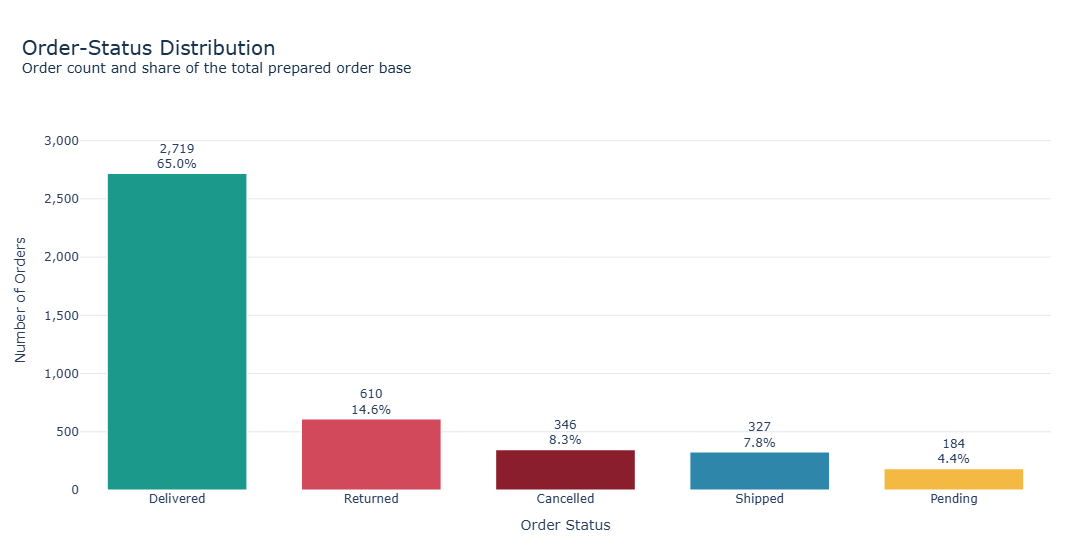

In [99]:
status_order = ["Delivered","Returned","Cancelled","Shipped","Pending"]
status_distribution = (df["order_status"].value_counts().reindex(status_order).fillna(0).astype(int).rename_axis("order_status").reset_index(name="orders"))
status_distribution["order_share_pct"] = (status_distribution["orders"] / status_distribution["orders"].sum() * 100)
status_distribution["display_label"] = (status_distribution["orders"].map(lambda value: f"{value:,}") + "<br>" + status_distribution["order_share_pct"].map(lambda value: f"{value:.1f}%"))
maximum_orders = (status_distribution["orders"].max())

fig = px.bar(status_distribution, x="order_status", y="orders",color="order_status", text="display_label", color_discrete_map=STATUS_COLORS, custom_data=["order_share_pct"],
    title=("Order-Status Distribution""<br><sup>" "Order count and share of the total prepared order base""</sup>" ),
    labels={"order_status": "Order Status","orders": "Number of Orders" },
    template=PLOTLY_TEMPLATE)

fig.update_traces(textposition="outside",cliponaxis=False,marker_line_color="white", marker_line_width=1.2,hovertemplate=("<b>%{x}</b><br>" "Orders: %{y:,.0f}<br>" "Order Share: %{customdata.2f}%" "<extra></extra>"))

fig.update_layout(height=560,showlegend=False, title={"x": 0.02, "xanchor": "left","font": {"size": 20,"color": COLORS["navy"]}},
    xaxis={"title": "Order Status","categoryorder": "array","categoryarray": status_order,"showgrid": False},
    yaxis={"title": "Number of Orders","range": [0, maximum_orders * 1.20],"tickformat": ",.0f","gridcolor": "#E4E7EC","zeroline": False},
    plot_bgcolor="white",paper_bgcolor="white",margin={"l": 80,"r": 40,"t": 110,"b": 70},
    bargap=0.28)

fig.show()

In [100]:
largest_status_row = (status_distribution.loc[status_distribution["orders"].idxmax()])
non_delivered_orders = int(status_distribution.loc[status_distribution["order_status"].ne("Delivered"), "orders"].sum())
non_delivered_share = (non_delivered_orders / status_distribution["orders"].sum() * 100)

status_finding = ( f"{largest_status_row['order_status']} is the largest status group, representing {largest_status_row['order_share_pct']:.2f}% of all orders. Non-Delivered statuses collectively represent {non_delivered_share:.2f}% of the order base.")
status_implication = ("A material share of orders is associated with Returned, Cancelled, Shipped, or Pending statuses. These outcomes represent customer, operational, and pipeline exposure that should be reviewed separately from Delivered orders.")
status_recommendation = ("The analyst recommends separate executive monitoring of every order status, product-level analysis of Returned orders, segment-level analysis of cancellations, and regular review of Pending and Shipped orders.")
status_decision = ("Top management should approve order-status targets, assign ownership for return and cancellation reduction, and establish escalation rules for incomplete orders.")
status_monitoring_kpis = ["Order count and share by status",
    "Delivery rate",
    "Return rate",
    "Cancellation rate",
    "Pending order count and recorded value",
    "Shipped order count and recorded value",
    "Average satisfaction by status"]

display_visual_interpretation(visual_title="Order-Status Distribution",
    finding=status_finding,
    implication=status_implication,
    recommendation=status_recommendation,
    decision=status_decision,
    monitoring_kpis=status_monitoring_kpis,
    interpretation_note=("Recorded financial values by order status are analyzed as supplied y the synthetic dataset and are not treated as accounting-recognized r realized revenue."))

##### 📦 Univariate Visual 2: Product-Category Order Distribution

**Executive Question:** Which product categories account for the largest share of order activity?

**Business Purpose:** Identify category-level demand concentration and establish the order-volume context for later sales, profitability, return, and cancellation analysis.

**Visual Encoding:**

- Bar length represents the number of unique orders.
- Categories are ranked from highest to lowest order volume.
- Data labels show the exact number of orders in each category.

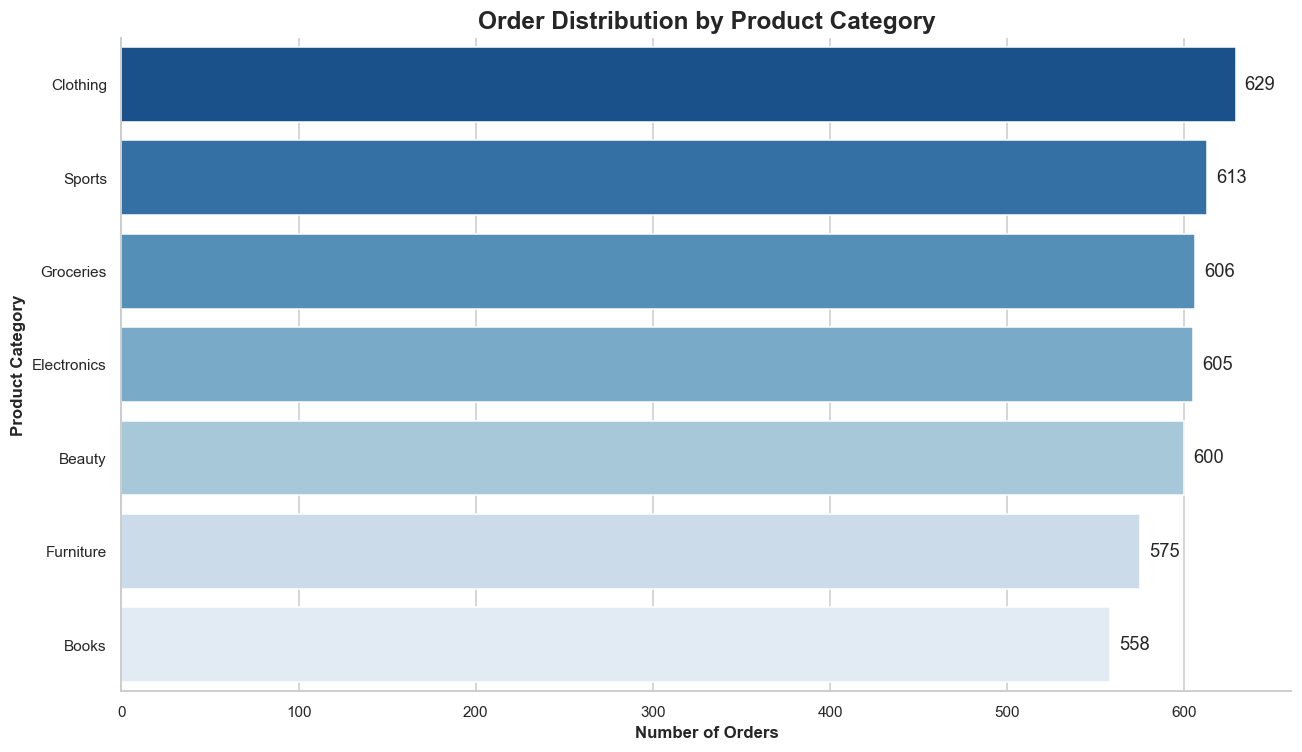

In [101]:
category_orders = (df.groupby("product_category",observed=True).agg(orders=("order_id","nunique")).sort_values("orders",ascending=False).reset_index())

plt.figure(figsize=(12, 7))
sns.barplot(data=category_orders,x="orders",y="product_category",hue="product_category",palette="Blues_r",legend=False)
plt.title("Order Distribution by Product Category")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")
for index, row in category_orders.iterrows():
    plt.text(row["orders"] + 5,index,f"{row['orders']:,.0f}",va="center")
plt.tight_layout()
plt.show()

In [102]:
largest_order_category = (category_orders.loc[category_orders["orders"].idxmax()])
smallest_order_category = (category_orders.loc[category_orders["orders"].idxmin()])
category_order_total = (category_orders["orders"].sum())
largest_category_share = (largest_order_category["orders"] / category_order_total * 100)

category_orders_finding = (f"{largest_order_category['product_category']} has the highest order volume with {largest_order_category['orders']:,.0f} orders, representing {largest_category_share:.2f}% of category orders. {smallest_order_category['product_category']} has the lowest order volume with {smallest_order_category['orders']:,.0f} orders.")
category_orders_implication = ("Order volume identifies customer activity but does not measure commercial value or profitability quality. A high-volume category may still have a low average order value, weak margin, or elevated return exposure.")
category_orders_recommendation = ("The analyst recommends reviewing category order volume together with recorded sales, recorded profit, weighted margin, return rate, and cancellation rate before making inventory or investment decisions.")
category_orders_decision = ("Top management should determine whether category resources should prioritize customer-volume leaders, profit leaders, margin leaders, or categories requiring corrective action.")
category_orders_kpis = ["Orders by product category",
    "Category share of total orders",
    "Units sold",
    "Average order value",
    "Recorded sales and profit",
    "Weighted category margin",
    "Return and cancellation rates"]

display_visual_interpretation(visual_title="Product-Category Order Distribution",
    finding=category_orders_finding,
    implication=category_orders_implication,
    recommendation=category_orders_recommendation,
    decision=category_orders_decision,
    monitoring_kpis=category_orders_kpis,
    interpretation_note=("Order volume is an activity measure and should not be used alone to rank category performance."))

##### 💰 Univariate Visual 3: Recorded Sales Distribution

**Executive Question:** Are recorded sales evenly distributed, or are the results concentrated in a smaller number of high-value orders?

**Business Purpose:** Evaluate the typical transaction profile, identify sales-value concentration, and determine whether high-value orders materially influence average order value.

**Visual Encoding:**

- The first histogram presents recorded sales on the original scale.
- The second histogram presents the same distribution using a logarithmic transformation.
- The logarithmic view improves visibility across low-, medium-, and high-value orders.

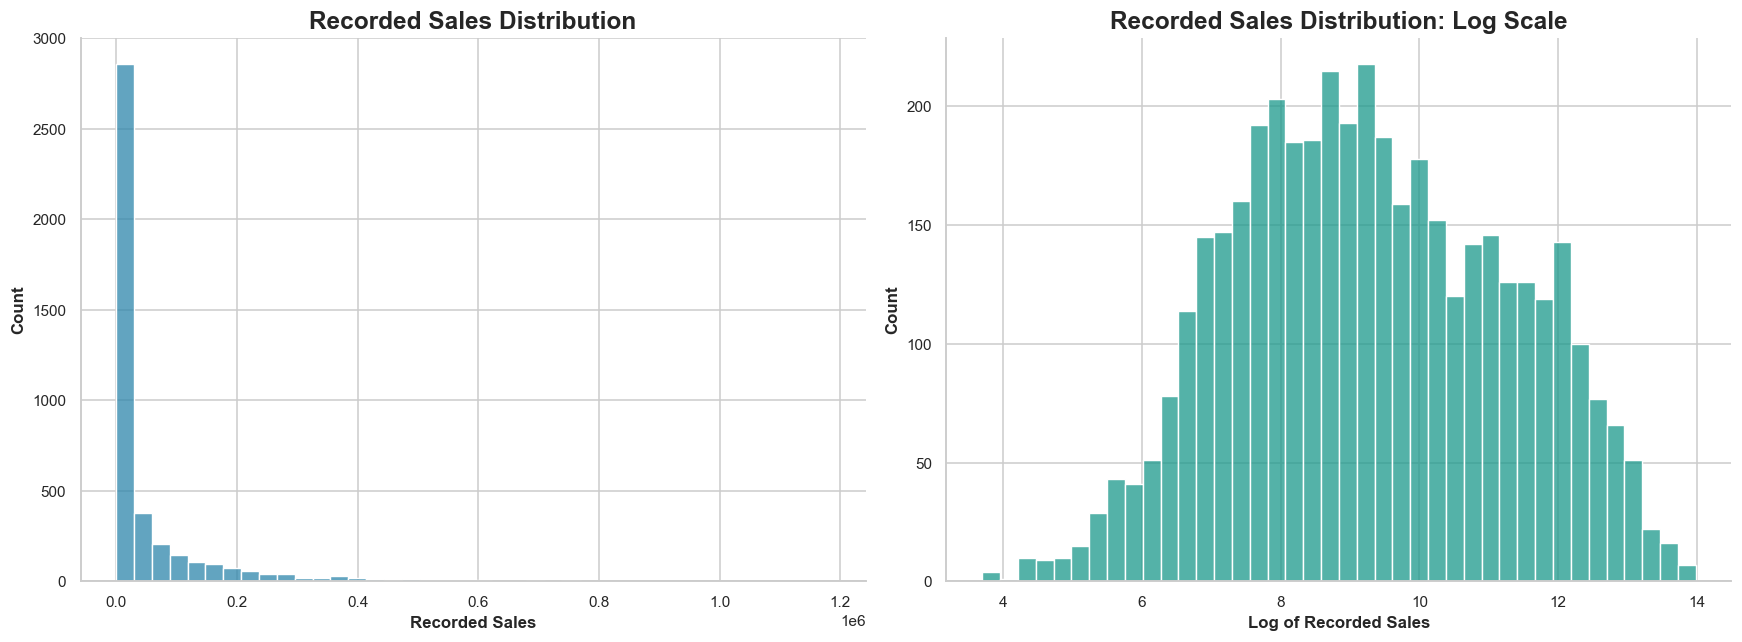

In [103]:
ig, axes = plt.subplots(1,2,figsize=(16, 6))

sns.histplot(data=df,x="sales_amount",bins=40,color=COLORS["blue"],ax=axes[0])
axes[0].set_title("Recorded Sales Distribution")
axes[0].set_xlabel("Recorded Sales")
sns.histplot(x=np.log1p(df["sales_amount"]),bins=40,color=COLORS["teal"],ax=axes[1])
axes[1].set_title("Recorded Sales Distribution: Log Scale")

axes[1].set_xlabel("Log of Recorded Sales")
plt.tight_layout()
plt.show()

In [104]:
sales_mean = float(df["sales_amount"].mean())
sales_median = float(df["sales_amount"].median())
sales_skewness = float(df["sales_amount"].skew())
sales_p90 = float(df["sales_amount"].quantile(0.90))
sales_p99 = float(df["sales_amount"].quantile(0.99))
top_one_percent_share = (df.loc[df["sales_amount"].ge(sales_p99),"sales_amount"].sum() / df["sales_amount"].sum() * 100)

sales_distribution_finding = (f"Average recorded sales per order are {format_currency(sales_mean)}, while the median is {format_currency(sales_median)}. The distribution has a skewness value of {sales_skewness:.2f}. The 90th percentile is {format_currency(sales_p90)}, and orders at or above the 99th percentile contribute {top_one_percent_share:.2f}% of total recorded sales.")
sales_distribution_implication = ("The difference between the mean and median confirms that high-value orders materially influence the average. Executive reporting based only on average order value may therefore overstate the typical transaction profile.")
sales_distribution_recommendation = ("The analyst recommends reporting the median, average, percentile thresholds, and high-value-order concentration together. High-value orders should be monitored separately for return, cancellation, and fulfillment exposure.")
sales_distribution_decision = ("Top management should approve a high-value-order definition and determine whether such orders require enhanced fulfillment controls or manual exception review.")
sales_distribution_kpis = ["Average order value",
    "Median order value",
    "90th and 99th percentile order values",
    "Top 1% share of recorded sales",
    "High-value order return rate",
    "High-value order cancellation rate"]
display_visual_interpretation(visual_title="Recorded Sales Distribution",
    finding=sales_distribution_finding,
    implication=sales_distribution_implication,
    recommendation=sales_distribution_recommendation,
    decision=sales_distribution_decision,
    monitoring_kpis=sales_distribution_kpis,
    interpretation_note=("Legitimate high-value orders are retained because transaction values differ substantially across product categories."))

##### ⭐ Univariate Visual 4: Customer Rating Distribution

**Executive Question:** How are customer ratings distributed, including orders where no valid feedback was submitted?

**Business Purpose:** Assess customer-feedback composition, identify the balance of positive and negative ratings, and make rating coverage visible alongside average satisfaction.

**Visual Encoding:**

- Bar height represents the number of orders.
- Ratings from 1 to 5 represent valid customer responses.
- Not Rated represents orders without a valid customer-satisfaction response.

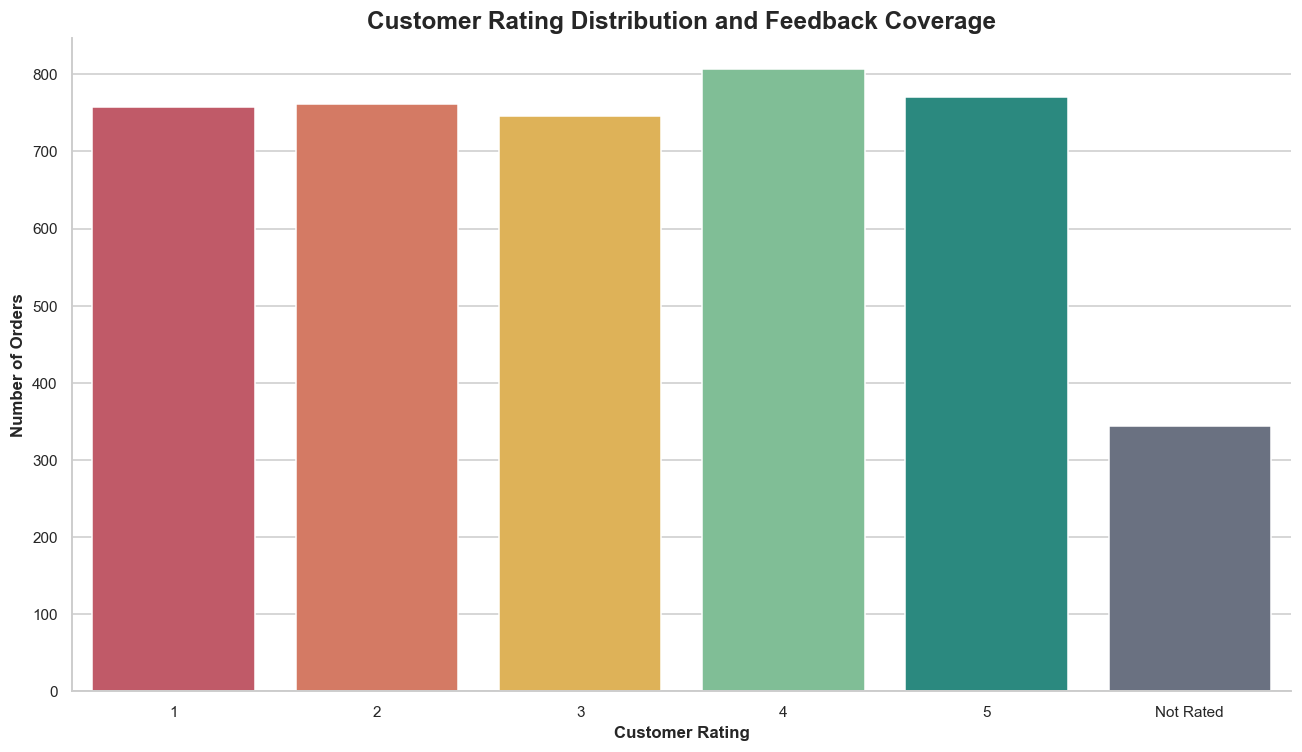

In [105]:
rating_distribution = (df["customer_satisfaction"].astype("Int64").astype("string").fillna("Not Rated").value_counts().reset_index())
rating_distribution.columns = ["rating","orders"]
rating_order = ["1","2","3","4","5","Not Rated"]
rating_distribution["rating"] = pd.Categorical(rating_distribution["rating"],categories=rating_order,ordered=True)
rating_distribution = (rating_distribution.sort_values("rating"))
rating_colors = [COLORS["red"],"#E76F51",COLORS["gold"],"#76C893",COLORS["teal"],COLORS["gray"]]

plt.figure(figsize=(12, 7))
sns.barplot(data=rating_distribution,x="rating",y="orders",hue="rating",palette=rating_colors,legend=False)
plt.title("Customer Rating Distribution and Feedback Coverage")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [106]:
rated_orders = int(df["customer_satisfaction"].notna().sum())
not_rated_orders = int(df["customer_satisfaction"].isna().sum())
rating_coverage_value = (rated_orders / len(df) * 100)
average_rating_value = float(df["customer_satisfaction"].mean())
positive_rating_share = (df["customer_satisfaction"].isin([4, 5]).sum() / rated_orders * 100)
low_rating_share = (df["customer_satisfaction"].isin([1, 2]).sum() / rated_orders * 100)
rating_finding = (f"{rated_orders:,} orders have a valid rating, producing rating coverage of {rating_coverage_value:.2f}%. The average rating is {average_rating_value:.2f} out of 5. Ratings of 4 or 5 represent {positive_rating_share:.2f}% of rated orders, while ratings of 1 or 2 represent {low_rating_share:.2f}%. {not_rated_orders:,} orders remain Not Rated.")
rating_implication = ("The average satisfaction score should not be assessed alone. The distribution of positive, neutral, negative, and missing feedback provides a fuller view of customer experience and survey coverage.")
rating_recommendation = ("The analyst recommends monitoring low ratings and Not Rated orders by category, region, shipping speed, payment method, and order status. Returned orders should receive priority because returned orders have materially weaker satisfaction.")
rating_decision = ("Top management should approve a customer-feedback target, assign ownership for feedback collection, and establish a service-recovery process for low ratings.")
rating_monitoring_kpis = ["Average customer satisfaction",
    "Rating coverage",
    "Share of ratings 4 and 5",
    "Share of ratings 1 and 2",
    "Not Rated order count",
    "Satisfaction by category and region",
    "Satisfaction by order status"]

display_visual_interpretation(visual_title="Customer Rating Distribution",
    finding=rating_finding,
    implication=rating_implication,
    recommendation=rating_recommendation,
    decision=rating_decision,
    monitoring_kpis=rating_monitoring_kpis,
    interpretation_note=("Average satisfaction excludes orders without a valid rating. Rating coverage must therefore be presented with satisfaction."))

##### 👥 Univariate Visual 5: Customer Age-Group Distribution

**Executive Question:** Which customer age groups account for the largest proportion of orders represented in the dataset?

**Business Purpose:** Identify demographic concentration and establish the segment-size context required for later comparisons of sales, profitability, returns, product preference, and satisfaction.

**Visual Encoding:**

- Bar height represents the number of orders.
- Bar color and label represent each age group's share of total orders.
- Age groups are displayed in ascending order.

In [107]:
age_group_distribution = (df["age_group"].value_counts().reindex(age_group_order).dropna().reset_index())
age_group_distribution.columns = ["age_group","orders"]
age_group_distribution["order_share_pct"] = (age_group_distribution["orders"] / age_group_distribution["orders"].sum() * 100)
fig = px.bar(age_group_distribution,x="age_group",y="orders",color="order_share_pct",text="order_share_pct",color_continuous_scale="Blues",
    title="Order Distribution by Customer Age Group",labels={"age_group": "Age Group","orders": "Orders","order_share_pct": "Order Share (%)"},template=PLOTLY_TEMPLATE)

fig.update_traces(texttemplate="%{text:.1f}%",textposition="outside")
fig.update_layout(width=1100,height=500)
fig.show()

In [108]:
largest_age_group = (age_group_distribution.loc[age_group_distribution["orders"].idxmax()])
smallest_age_group = (age_group_distribution.loc[age_group_distribution["orders"].idxmin()])
age_group_finding = (f"The {largest_age_group['age_group']} segment is the largest age group, accounting for {largest_age_group['order_share_pct']:.2f}% of orders. The {smallest_age_group['age_group']} segment is the smallest, contributing {smallest_age_group['order_share_pct']:.2f}% of orders.")
age_group_implication = ("Customer age concentration can influence product demand, order value, discount response, and satisfaction. However, order representation does not automatically indicate customer profitability or growth potential.")
age_group_recommendation = ("The analyst recommends comparing age groups across recorded sales, profit, weighted margin, product preference, satisfaction, and returns before designing segment-specific commercial actions.")
age_group_decision = ("Top management should determine whether customer-segment analysis should influence assortment, communication, promotional testing, or customer-experience initiatives.")
age_group_kpis = ["Orders by age group",
    "Age-group share of total orders",
    "Recorded sales by age group",
    "Weighted margin by age group",
    "Average order value",
    "Return rate",
    "Average satisfaction"]

display_visual_interpretation(visual_title="Customer Age-Group Distribution",
    finding=age_group_finding,
    implication=age_group_implication,
    recommendation=age_group_recommendation,
    decision=age_group_decision,
    monitoring_kpis=age_group_kpis,
    interpretation_note=("The dataset is synthetic, and age-based findings should not be generalized to a wider customer population."))

#### 🔗 Section B: Bivariate Visual Analysis

Bivariate analysis examines the relationship between two principal variables.

These visuals evaluate how a key management measure changes across time, product category, region, discount level, or shipping-performance group.

##### 🔗 Bivariate Visual 1: Annual Recorded Sales Trend

**Executive Question:** How have recorded sales changed from 2020 through 2024?

**Business Purpose:** Identify periods of commercial growth, decline, and recovery and establish the annual performance pattern for comparison with profit and margin.

**Visual Encoding:**

- The horizontal axis represents the calendar year.
- The vertical axis represents total recorded sales.
- Markers show the annual sales totals.
- Interactive hover information provides recorded sales and year-over-year growth.

In [109]:
annual_sales_visual = (df.groupby("year",as_index=False ).agg(recorded_sales=("sales_amount","sum")).sort_values("year").reset_index(drop=True))
# Calculate year-over-year sales growth
annual_sales_visual["sales_growth_pct"] = (annual_sales_visual["recorded_sales"].pct_change().mul(100))
fig = px.line(annual_sales_visual,x="year",y="recorded_sales",markers=True,
    title=("Annual Recorded Sales Trend<br><sup>Commercial performance from 2020 to 2024</sup>"),
    labels={"year": "Year","recorded_sales": "Recorded Sales"},template=PLOTLY_TEMPLATE)

fig.update_traces(line={"color": COLORS["blue"],"width": 4},marker={"size": 11,"color": COLORS["navy"],"line": {"width": 2,"color": "white"}},
    customdata=annual_sales_visual[["sales_growth_pct"]],hovertemplate=("<b>Year: %{x}</b><br>Recorded Sales: INR %{y:,.2f}<br>Sales Growth: %{customdata.2f}%<extra></extra>"))

fig.update_layout(height=550,title={"x": 0.02,"xanchor": "left"},
    xaxis={"dtick": 1,"title": "Year"},
    yaxis={"title": "Recorded Sales","tickprefix": "INR ","tickformat": ",.0f"},
    margin={"l": 100,"r": 40,"t": 100, "b": 60})

fig.show()

In [110]:
highest_sales_year_row = (annual_sales_visual.loc[annual_sales_visual["recorded_sales"].idxmax()])
lowest_sales_year_row = (annual_sales_visual.loc[annual_sales_visual["recorded_sales"].idxmin()])
latest_sales_row = (annual_sales_visual.loc[annual_sales_visual["year"].idxmax()])
latest_growth_value = float(latest_sales_row["sales_growth_pct"])
annual_sales_finding = (f"{int(highest_sales_year_row['year'])} records the highest annual sales at {format_currency(highest_sales_year_row['recorded_sales'])}. {int(lowest_sales_year_row['year'])} records the lowest annual sales at {format_currency(lowest_sales_year_row['recorded_sales'])}. In the latest year, recorded sales changed by {latest_growth_value:.2f}% compared with the previous year.")
annual_sales_implication = ("he annual sales trend identifies periods of commercial expansion, contraction, and recovery. Sales movement should be assessed together with recorded profit, weighted margin, order volume, and average order value because higher sales do not automatically indicate stronger profitability.")
annual_sales_recommendation = ("The analyst recommends comparing the strongest and weakest years by product category, product, region, discount band, return rate, cancellation rate, and average order value to identify the principal drivers of annual performance.")
annual_sales_decision = ("Top management should determine whether the next-period priority is sales acceleration, profit growth, margin protection, product-mix improvement, or operational risk reduction.")
annual_sales_kpis = ["Annual recorded sales",
    "Year-over-year sales growth",
    "Annual recorded profit",
    "Weighted annual profit margin",
    "Annual order volume",
    "Average order value",
    "Annual return rate",
    "Annual cancellation rate"]
display_visual_interpretation(
    visual_title="Annual Recorded Sales Trend",
    finding=annual_sales_finding,
    implication=annual_sales_implication,
    recommendation=annual_sales_recommendation,
    decision=annual_sales_decision,
    monitoring_kpis=annual_sales_kpis,
    interpretation_note=("Sales growth should not be interpreted as profitable growth without reviewing recorded profit and weighted profit margin."))

##### 💰 Bivariate Visual 2: Weighted Profit Margin by Product Category

**Executive Question:** Which product categories generate the strongest recorded profit relative to recorded sales?

**Business Purpose:** Compare profitability quality across categories and distinguish margin leaders from categories that rely mainly on commercial scale.

**Visual Encoding:**

- Bar length represents weighted profit margin.
- Categories are ranked from highest to lowest margin.
- Weighted margin is calculated as total category profit divided by total category sales.

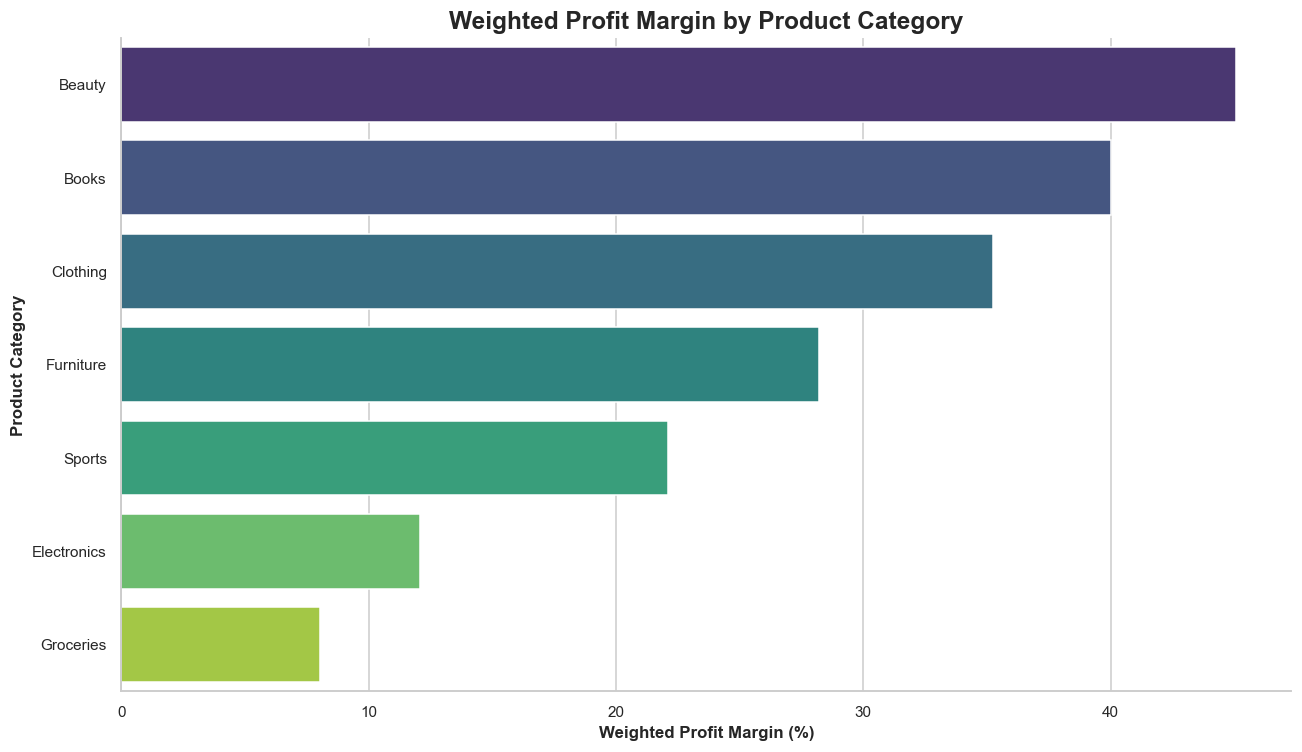

In [111]:
category_margin_visual = (category_performance.reset_index().sort_values("weighted_profit_margin_pct",ascending=False))
plt.figure(figsize=(12, 7))
sns.barplot(data=category_margin_visual,x="weighted_profit_margin_pct",y="product_category",hue="product_category",palette="viridis",legend=False)
plt.title("Weighted Profit Margin by Product Category")
plt.xlabel("Weighted Profit Margin (%)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [112]:
highest_margin_category_row = (category_margin_visual.loc[category_margin_visual["weighted_profit_margin_pct"].idxmax()])
lowest_margin_category_row = (category_margin_visual.loc[category_margin_visual["weighted_profit_margin_pct"].idxmin()])
category_margin_gap = (highest_margin_category_row["weighted_profit_margin_pct"]- lowest_margin_category_row["weighted_profit_margin_pct"])
category_margin_finding = (f"{highest_margin_category_row['product_category']} records the highest weighted category margin at {highest_margin_category_row['weighted_profit_margin_pct']:.2f}%. {lowest_margin_category_row['product_category']} records the lowest margin at {lowest_margin_category_row['weighted_profit_margin_pct']:.2f}%. The difference is {category_margin_gap:.2f} percentage points.")
category_margin_implication = ("The large difference in category margins confirms that recorded sales do not generate equal profitability across the portfolio. Lower-margin categories require greater volume to produce similar profit.")
category_margin_recommendation = (f"The analyst recommends protecting profitable growth in {highest_margin_category_row['product_category']} and reviewing pricing, discounting, sourcing, and fulfillment economics in {lowest_margin_category_row['product_category']}.")
category_margin_decision = ("Top management should approve category-level margin targets, determine which categories should receive growth investment, and assign ownership for margin-improvement initiatives.")
category_margin_kpis = ["Weighted profit margin by category",
    "Recorded profit by category",
    "Recorded sales by category",
    "Average order value",
    "Discount level by category",
    "Return and cancellation rates"]

display_visual_interpretation(visual_title="Weighted Profit Margin by Product Category",
    finding=category_margin_finding,
    implication=category_margin_implication,
    recommendation=category_margin_recommendation,
    decision=category_margin_decision,
    monitoring_kpis=category_margin_kpis)

##### 🚚 Bivariate Visual 3: Average Shipping Cost by Region

**Executive Question:** How does average shipping cost vary across geographic regions?

**Business Purpose:** Identify regional shipping-cost differences that may affect order economics, profitability, and fulfillment strategy.

**Visual Encoding:**

- Bar height represents average shipping cost per order.
- Regions are compared using a continuous color scale.
- Data labels show the average shipping cost for each region.

In [113]:
regional_shipping_visual = (regional_performance.reset_index().sort_values("average_shipping_cost",ascending=False))

fig = px.bar(regional_shipping_visual,x="region",y="average_shipping_cost",color="average_shipping_cost",text="average_shipping_cost",color_continuous_scale="Oranges",
             title="Average Shipping Cost by Region",labels={"region": "Region","average_shipping_cost":"Average Shipping Cost"},template=PLOTLY_TEMPLATE)
fig.update_traces(texttemplate="INR %{text:.2f}",textposition="outside")
fig.update_layout(width=800,height=500)
fig.show()

In [114]:
highest_cost_region_row = (regional_shipping_visual.loc[regional_shipping_visual["average_shipping_cost"].idxmax()])
lowest_cost_region_row = (regional_shipping_visual.loc[regional_shipping_visual["average_shipping_cost"].idxmin()])
shipping_cost_gap = (highest_cost_region_row["average_shipping_cost"] - lowest_cost_region_row["average_shipping_cost"])
regional_cost_finding = (f"{highest_cost_region_row['region']} has the highest average shipping cost at {format_currency(highest_cost_region_row['average_shipping_cost'])}. {lowest_cost_region_row['region']} has the lowest at {format_currency(lowest_cost_region_row['average_shipping_cost'])}. The difference is {format_currency(shipping_cost_gap)} per order.")
regional_cost_implication = ("Higher shipping cost may weaken regional profitability, particularly for low-value orders. However, cost differences may also reflect product mix, order value, distance, or fulfillment method.")
regional_cost_recommendation = (f"The analyst recommends reviewing category mix, average order value, carrier arrangements, and weighted margin in {highest_cost_region_row['region']} before introducing logistics changes.")
regional_cost_decision = ("Top management should determine whether regional shipping-cost targets, carrier reviews, or category-specific fulfillment policies are required.")
regional_cost_kpis = ["Average shipping cost by region",
    "Shipping cost per order",
    "Weighted regional margin",
    "Average order value",
    "Category mix by region",
    "Return and cancellation rates"]

display_visual_interpretation(visual_title="Average Shipping Cost by Region",
    finding=regional_cost_finding,
    implication=regional_cost_implication,
    recommendation=regional_cost_recommendation,
    decision=regional_cost_decision,
    monitoring_kpis=regional_cost_kpis,
    interpretation_note=("The dataset does not confirm whether shipping cost is already included in recorded profit."))

##### 🏷️ Bivariate Visual 4: Return Rate by Discount Band

**Executive Question:** How does return exposure vary across different discount levels?

**Business Purpose:** Identify discount bands associated with higher return exposure and determine where promotional activity requires deeper product- and category-level investigation.

**Visual Encoding:**

- The horizontal axis represents the discount band.
- The vertical axis represents the return rate.
- Discount bands are displayed in their defined commercial order.
- 

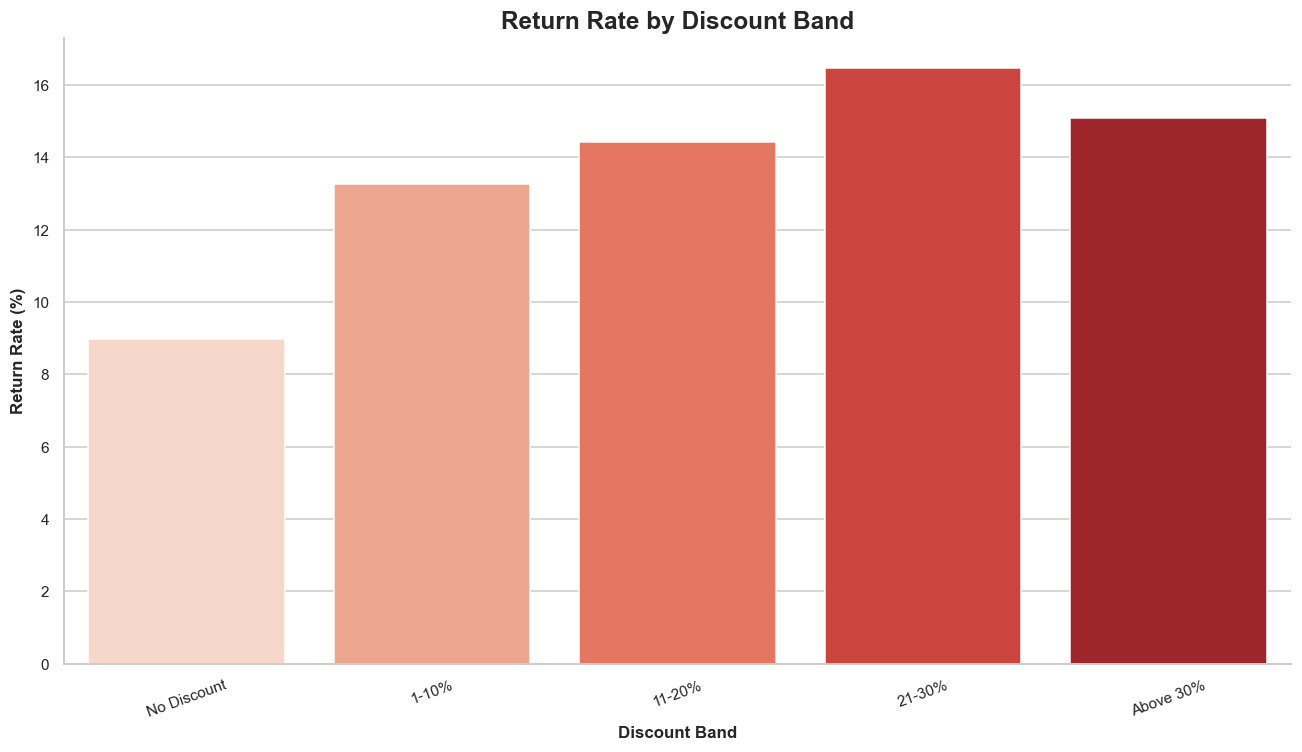

In [115]:
discount_return_visual = (discount_effectiveness.reset_index())
discount_return_visual["discount_band"] = pd.Categorical(discount_return_visual["discount_band"],categories=discount_order,ordered=True)
discount_return_visual = (discount_return_visual.sort_values("discount_band"))

plt.figure(figsize=(12, 7))
sns.barplot(data=discount_return_visual,x="discount_band",y="return_rate_pct",hue="discount_band",palette="Reds",legend=False)
plt.title("Return Rate by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [116]:
highest_return_band_row = (discount_return_visual.loc[discount_return_visual["return_rate_pct"].idxmax()])
lowest_return_band_row = (discount_return_visual.loc[discount_return_visual["return_rate_pct"].idxmin()])
discount_return_gap = (highest_return_band_row["return_rate_pct"] - lowest_return_band_row["return_rate_pct"])
discount_return_finding = (f"The {highest_return_band_row['discount_band']} discount band has the highest return rate at {highest_return_band_row['return_rate_pct']:.2f}%. The {lowest_return_band_row['discount_band']} band has the lowest return rate at {lowest_return_band_row['return_rate_pct']:.2f}%. The difference is {discount_return_gap:.2f} percentage points.")
discount_return_implication = ("The result indicates that return exposure differs by discount band, but the relationship may be influenced by category, product, and order-value mix.")
discount_return_recommendation = (f"The analyst recommends product- and category-level analysis within the {highest_return_band_row['discount_band']} band before changing the discount policy. Controlled promotional tests should monitor returns and margin together.")
discount_return_decision = ("Top management should determine whether deeper discounts require additional approval, return-rate guardrails, or category-specific limits.")
discount_return_kpis = ["Return rate by discount band",
    "Cancellation rate by discount band",
    "Weighted margin by discount band",
    "Average order value",
    "Category and product mix",
    "Recorded profit by discount band"]

display_visual_interpretation(visual_title="Return Rate by Discount Band",
    finding=discount_return_finding,
    implication=discount_return_implication,
    recommendation=discount_return_recommendation,
    decision=discount_return_decision,
    monitoring_kpis=discount_return_kpis,
    interpretation_note=("The visual shows association and does not demonstrate that discounting caused returns."))

##### ⭐ Bivariate Visual 5: Customer Satisfaction by Shipping Speed

**Executive Question:** Does average customer satisfaction vary across shipping-speed groups?

**Business Purpose:** Evaluate whether customer experience differs among Fast, Standard, Moderate, and Slow shipping groups and identify segments requiring service review.

**Visual Encoding:**

- The horizontal axis represents the shipping-speed group.
- The vertical axis represents average customer satisfaction.
- Markers identify the average satisfaction score for each group.
- The satisfaction scale is displayed from 1 to 5.

In [117]:
shipping_satisfaction = (df.groupby("shipping_speed",observed=True).agg(average_satisfaction=("customer_satisfaction","mean"),rating_coverage_pct=("customer_satisfaction",rating_coverage)).reindex(shipping_speed_order).reset_index())

fig = px.line(shipping_satisfaction,x="shipping_speed",y="average_satisfaction",markers=True,
    title="Average Customer Satisfaction by Shipping Speed",labels={"shipping_speed":"Shipping Speed","average_satisfaction":"Average Satisfaction"},template=PLOTLY_TEMPLATE)
fig.update_traces(line={"color": COLORS["teal"],"width": 3},marker={"size": 10})
fig.update_yaxes(range=[1, 5])
fig.show()

In [118]:
best_shipping_rating_row = (shipping_satisfaction.loc[shipping_satisfaction["average_satisfaction"].idxmax()])
lowest_shipping_rating_row = (shipping_satisfaction.loc[shipping_satisfaction["average_satisfaction"].idxmin()])
shipping_satisfaction_gap = (best_shipping_rating_row["average_satisfaction"] - lowest_shipping_rating_row["average_satisfaction"])
shipping_rating_finding = (f"The {best_shipping_rating_row['shipping_speed']} group records the highest average satisfaction at {best_shipping_rating_row['average_satisfaction']:.2f} out of 5. The {lowest_shipping_rating_row['shipping_speed']} group records the lowest satisfaction at {lowest_shipping_rating_row['average_satisfaction']:.2f}. The difference is {shipping_satisfaction_gap:.2f} rating points.")
shipping_rating_implication = ("Shipping speed may be associated with customer satisfaction, but differences may also reflect order status, product mix, returns, and rating coverage.")
shipping_rating_recommendation = (f"The analyst recommends reviewing low-rated orders within the {lowest_shipping_rating_row['shipping_speed']} group by category, region, order status, and return outcome before modifying service levels.")
shipping_rating_decision = ("Top management should determine whether shipping-speed service targets or customer communication standards should be adjusted.")
shipping_rating_kpis = ["Average satisfaction by shipping speed",
    "Rating coverage by shipping speed",
    "Return rate by shipping speed",
    "Cancellation rate by shipping speed",
    "Order volume by shipping speed",
    "Average shipping days"]


display_visual_interpretation(visual_title="Customer Satisfaction by Shipping Speed",
    finding=shipping_rating_finding,
    implication=shipping_rating_implication,
    recommendation=shipping_rating_recommendation,
    decision=shipping_rating_decision,
    monitoring_kpis=shipping_rating_kpis,
    interpretation_note=("The visual identifies association and does not prove that shipping speed caused the satisfaction result."))

#### 🧭 Section C: Multivariate Visual Analysis

Multivariate analysis combines three or more business measures or dimensions.

These visuals support executive trade-off analysis by connecting commercial scale, profitability, customer experience, product mix, geography, discounts, fulfillment, and operating risk.

##### 💰 Multivariate Visual 1: Annual Sales, Profit, and Weighted Margin

**Executive Question:** Do annual recorded sales, recorded profit, and weighted profit margin move in the same direction?

**Business Purpose:** Distinguish commercial growth from profitable growth and evaluate the quality and sustainability of annual performance.

**Visual Encoding:**

- Blue bars represent annual recorded sales.
- Teal bars represent annual recorded profit.
- The gold line represents annual weighted profit margin.
- The secondary vertical axis displays weighted margin as a percentage.

In [119]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Bar(x=annual_performance["year"],y=annual_performance["recorded_sales"],name="Recorded Sales",marker_color=COLORS["blue"]),secondary_y=False)
fig.add_trace(go.Bar(x=annual_performance["year"],y=annual_performance["recorded_profit"],name="Recorded Profit",marker_color=COLORS["teal"]),secondary_y=False)
fig.add_trace(go.Scatter(x=annual_performance["year"],y=annual_performance["weighted_profit_margin_pct"],name="Weighted Margin",mode="lines+markers",line={"color": COLORS["gold"],"width": 4}),secondary_y=True)
fig.update_layout(width=800,height=500,title="Annual Sales, Profit, and Weighted Margin",barmode="group",template=PLOTLY_TEMPLATE,hovermode="x unified")
fig.update_yaxes(title_text="Recorded Value",tickprefix="INR ",tickformat=",.0f",secondary_y=False)
fig.update_yaxes(title_text="Weighted Margin (%)",secondary_y=True)
fig.show()

In [120]:
highest_sales_annual = (annual_performance.loc[annual_performance["recorded_sales"].idxmax()])
highest_profit_annual = (annual_performance.loc[annual_performance["recorded_profit"].idxmax()])
highest_margin_annual = (annual_performance.loc[annual_performance["weighted_profit_margin_pct"].idxmax()])
latest_annual = (annual_performance.loc[annual_performance["year"].idxmax()])

annual_multi_finding = (f"{int(highest_sales_annual['year'])} records the highest sales at {format_currency(highest_sales_annual['recorded_sales'])}. {int(highest_profit_annual['year'])} records the highest profit at {format_currency(highest_profit_annual['recorded_profit'])}. {int(highest_margin_annual['year'])} records the strongest weighted margin at {highest_margin_annual['weighted_profit_margin_pct']:.2f}%. In {int(latest_annual['year'])}, sales changed by {latest_annual['sales_growth_pct']:.2f}% while profit changed by {latest_annual['profit_growth_pct']:.2f}%.")
annual_multi_implication = ("Annual sales, profit, and margin do not always peak in the same year. This confirms that commercial growth and profitability quality must be evaluated separately.")
annual_multi_recommendation = ("The analyst recommends a year-over-year contribution bridge covering categories, products, regions, discounts, returns, average order value, and high-value orders.")
annual_multi_decision = ("Top management should determine whether the next planning cycle should prioritize sales growth, profit growth, margin protection, or portfolio rebalancing.")
annual_multi_kpis = ["Annual recorded sales",
    "Annual recorded profit",
    "Weighted annual margin",
    "Sales and profit growth",
    "Annual order volume",
    "Average order value",
    "Category contribution"]


display_visual_interpretation(visual_title="Annual Sales, Profit, and Weighted Margin",
    finding=annual_multi_finding,
    implication=annual_multi_implication,
    recommendation=annual_multi_recommendation,
    decision=annual_multi_decision,
    monitoring_kpis=annual_multi_kpis)

##### 📦 Multivariate Visual 2: Category Commercial Position

**Executive Question:** Which product categories combine commercial scale, profitability quality, order volume, and manageable return exposure?

**Business Purpose:** Support category investment, corrective action, portfolio prioritization, and controlled-growth decisions.

**Visual Encoding:**

- The horizontal axis represents recorded sales.
- The vertical axis represents weighted profit margin.
- Bubble size represents order volume.
- Bubble color represents return rate.
- Category labels identify the portfolio position of each category.

In [121]:
category_position = (category_performance.reset_index())

fig = px.scatter(category_position,x="recorded_sales",y="weighted_profit_margin_pct",size="orders",color="return_rate_pct",text="product_category",
    hover_data={"recorded_profit": ":,.2f","average_order_value": ":,.2f","cancellation_rate_pct": ":.2f","average_satisfaction": ":.2f"},
    color_continuous_scale="RdYlGn_r",title=("Category Commercial Position: ""Sales, Margin, Scale, and Returns"),
    labels={"recorded_sales": "Recorded Sales","weighted_profit_margin_pct":"Weighted Margin (%)","return_rate_pct": "Return Rate (%)","orders": "Orders"},template=PLOTLY_TEMPLATE)

fig.update_traces(textposition="top center")
fig.update_layout(width=800,height=600)
fig.show()

In [122]:
highest_sales_category_row = (category_position.loc[category_position["recorded_sales"].idxmax()])
highest_margin_category_row = (category_position.loc[category_position["weighted_profit_margin_pct"].idxmax()])
highest_return_category_row = (category_position.loc[category_position["return_rate_pct"].idxmax()])

category_position_finding = (f"{highest_sales_category_row['product_category']} leads recorded sales at {format_currency(highest_sales_category_row['recorded_sales'])}, with a weighted margin of {highest_sales_category_row['weighted_profit_margin_pct']:.2f}%. {highest_margin_category_row['product_category']} records the highest margin at {highest_margin_category_row['weighted_profit_margin_pct']:.2f}%. {highest_return_category_row['product_category']} has the highest return rate at {highest_return_category_row['return_rate_pct']:.2f}%.")
category_position_implication = ("Category leadership differs depending on whether management evaluates sales scale, profit quality, order volume, or return exposure. The highest-sales category is not automatically the strongest investment.")
category_position_recommendation = ("The analyst recommends protecting categories that combine strong profit and healthy margin, improving high-sales categories with weaker margins, and conducting product-level analysis in the highest-return category.")
category_position_decision = ("Top management should approve category investment priorities, margin targets, return-reduction ownership, and controlled growth tests.")
category_position_kpis = ["Recorded sales and profit by category",
    "Weighted category margin",
    "Category order volume",
    "Average order value",
    "Return rate",
    "Cancellation rate",
    "Average satisfaction"]

display_visual_interpretation(
    visual_title="Category Commercial Position",
    finding=category_position_finding,
    implication=category_position_implication,
    recommendation=category_position_recommendation,
    decision=category_position_decision,
    monitoring_kpis=category_position_kpis)

##### 🌐 Multivariate Visual 3: Regional Commercial and Operational Position

**Executive Question:** How do regional sales, weighted margin, order scale, satisfaction, returns, cancellations, and shipping performance interact?

**Business Purpose:** Compare regional commercial strength with profitability, customer experience, and operational quality to support balanced regional investment decisions.

**Visual Encoding:**

- The horizontal axis represents recorded sales.
- The vertical axis represents weighted profit margin.
- Bubble size represents order volume.
- Bubble color represents average customer satisfaction.
- Hover information provides recorded profit, returns, cancellations, shipping cost, and shipping duration.

In [123]:
regional_position = (regional_performance.reset_index())

fig = px.scatter(
    regional_position,
    x="recorded_sales",
    y="weighted_profit_margin_pct",
    size="orders",
    color="average_satisfaction",
    text="region",
    hover_data={"recorded_profit": ":,.2f","return_rate_pct": ":.2f","cancellation_rate_pct": ":.2f","average_shipping_cost": ":,.2f","average_shipping_days": ":.2f"},
    color_continuous_scale="Viridis",
    title=("Regional Commercial and Operational Position"),
    labels={"recorded_sales": "Recorded Sales","weighted_profit_margin_pct":"Weighted Margin (%)","average_satisfaction":"Average Satisfaction","orders": "Orders"},
    template=PLOTLY_TEMPLATE)

fig.update_traces(textposition="top center")
fig.update_layout(width=800,height=500)
fig.show()

In [124]:
highest_sales_region_row = (regional_position.loc[regional_position["recorded_sales"].idxmax()])
highest_margin_region_row = (regional_position.loc[regional_position["weighted_profit_margin_pct"].idxmax()])
highest_return_region_row = (regional_position.loc[regional_position["return_rate_pct"].idxmax()])
highest_cost_region_row = (regional_position.loc[regional_position["average_shipping_cost"].idxmax()])
highest_satisfaction_region_row = (regional_position.loc[regional_position["average_satisfaction"].idxmax()])
regional_position_finding = (f"{highest_sales_region_row['region']} leads regional recorded sales at {format_currency(highest_sales_region_row['recorded_sales'])}. {highest_margin_region_row['region']} records the strongest weighted margin at {highest_margin_region_row['weighted_profit_margin_pct']:.2f}%. {highest_return_region_row['region']} has the highest return rate at {highest_return_region_row['return_rate_pct']:.2f}%. {highest_cost_region_row['region']} has the highest average shipping cost, while {highest_satisfaction_region_row['region']} records the highest average satisfaction.")
regional_position_implication = ("No region leads across commercial scale, profitability, customer experience, shipping economics, and return performance. Regional investment decisions should therefore balance growth opportunity with operating quality and customer outcomes.")
regional_position_recommendation = (f"The analyst recommends protecting commercial momentum in {highest_sales_region_row['region']}, investigating return drivers in {highest_return_region_row['region']}, reviewing shipping economics in {highest_cost_region_row['region']}, and assessing controlled growth opportunities in {highest_margin_region_row['region']}.")
regional_position_decision = ("Top management should approve regional investment priorities, assign ownership for return and shipping-cost improvements, and establish regional profitability and service targets.")
regional_position_kpis = ["Regional recorded sales",
    "Regional recorded profit",
    "Weighted regional margin",
    "Regional order volume",
    "Average order value",
    "Average shipping cost",
    "Average shipping duration",
    "Return rate",
    "Cancellation rate",
    "Average satisfaction",
    "Rating coverage"]

display_visual_interpretation(visual_title=("Regional Commercial and Operational Position"),
    finding=regional_position_finding,
    implication=regional_position_implication,
    recommendation=regional_position_recommendation,
    decision=regional_position_decision,
    monitoring_kpis=regional_position_kpis,
    interpretation_note=("Regional performance may also reflect differences in product category and city mix. Regional actions should be validated through category-level and city-level analysis."))

##### 👥 Multivariate Visual 4: Recorded Sales by Age Group and Gender

**Executive Question:** How are recorded sales distributed across customer age groups and gender classifications?

**Business Purpose:** Identify customer-segment concentration and establish where demographic segments contribute the greatest recorded commercial value.

**Visual Encoding:**

- Heatmap rows represent age groups.
- Heatmap columns represent gender classifications.
- Cell color intensity represents total recorded sales.
- Cell labels show the recorded sales value for each segment combination.

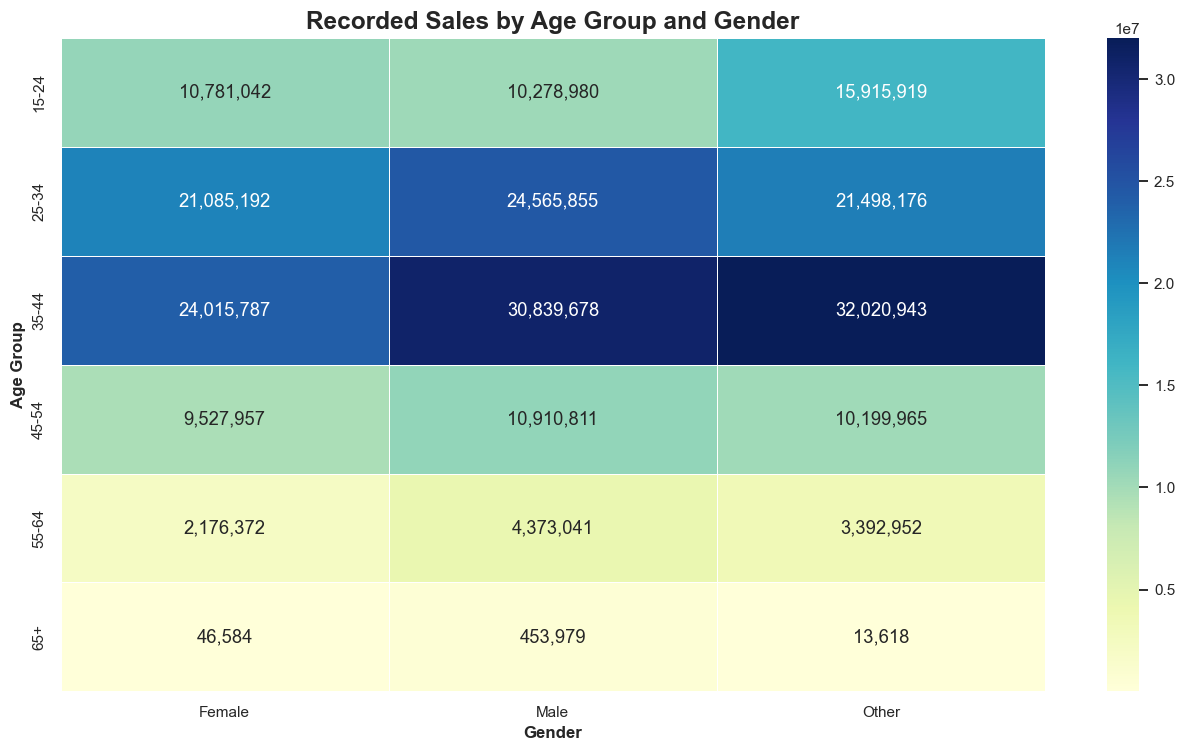

In [125]:
age_gender_sales = (df.pivot_table(index="age_group",columns="gender",values="sales_amount",aggfunc="sum",observed=True).reindex(age_group_order))
plt.figure(figsize=(12, 7))
sns.heatmap(age_gender_sales,annot=True,fmt=",.0f",cmap="YlGnBu",linewidths=0.5)
plt.title("Recorded Sales by Age Group and Gender")
plt.xlabel("Gender")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

In [126]:
age_gender_sales_long = (age_gender_sales.stack().reset_index())
age_gender_sales_long.columns = ["age_group","gender","recorded_sales"]
highest_demo_cell = (age_gender_sales_long.loc[age_gender_sales_long["recorded_sales"].idxmax()])
lowest_demo_cell = (age_gender_sales_long.loc[age_gender_sales_long["recorded_sales"].idxmin()])

demographic_finding = (f"The largest recorded-sales combination is the {highest_demo_cell['age_group']} age group and {highest_demo_cell['gender']} classification, generating {format_currency(highest_demo_cell['recorded_sales'])}. The smallest combination is the {lowest_demo_cell['age_group']} age group and {lowest_demo_cell['gender']} classification.")
demographic_implication = ("Total segment sales reflect both segment size and transaction value. A large sales total does not automatically indicate a stronger margin, higher satisfaction, or better customer potential.")
demographic_recommendation = ("The analyst recommends comparing demographic segments using order volume, average order value, product mix, weighted margin, satisfaction, and returns before proposing targeted commercial initiatives.")
demographic_decision = ("Top management should determine whether demographic segmentation adds sufficient decision value to assortment, communication, or customer-experience planning.")
demographic_kpis = ["Recorded sales by age group and gender",
    "Orders by customer segment",
    "Average order value",
    "Weighted margin",
    "Product-category preference",
    "Return rate",
    "Average satisfaction"]

display_visual_interpretation(visual_title="Age Group and Gender Sales",
    finding=demographic_finding,
    implication=demographic_implication,
    recommendation=demographic_recommendation,
    decision=demographic_decision,
    monitoring_kpis=demographic_kpis,
    interpretation_note=("The dataset is synthetic. Demographic observations should not be generalized or used to make assumptions about a wider population."))

##### 🏷️ Multivariate Visual 5: Discount Commercial and Risk Position

**Executive Question:** Which discount bands provide the strongest balance of recorded sales, weighted margin, order scale, and return exposure?

**Business Purpose:** Support discount governance by distinguishing commercially productive discount levels from bands associated with weaker order value or higher operational risk.

**Visual Encoding:**

- The horizontal axis represents recorded sales.
- The vertical axis represents weighted profit margin.
- Bubble size represents order volume.
- Bubble color represents return rate.
- Hover information provides profit, average order value, cancellation rate, and satisfaction.

In [127]:
discount_position = (discount_effectiveness.reset_index())

fig = px.scatter(discount_position,x="recorded_sales",y="weighted_profit_margin_pct",size="orders",color="return_rate_pct",text="discount_band",
    hover_data={"recorded_profit": ":,.2f","average_order_value": ":,.2f","cancellation_rate_pct": ":.2f","average_satisfaction": ":.2f"},
    color_continuous_scale="RdYlGn_r",title=("Discount Commercial and Risk Position"),
    labels={"recorded_sales": "Recorded Sales","weighted_profit_margin_pct":"Weighted Margin (%)","return_rate_pct": "Return Rate (%)","orders": "Orders"},
    template=PLOTLY_TEMPLATE)

fig.update_traces(textposition="top center")
fig.update_layout(width=800,height=500)
fig.show()

In [128]:
highest_sales_discount_row = (discount_position.loc[discount_position["recorded_sales"].idxmax()])
highest_margin_discount_row = (discount_position.loc[discount_position["weighted_profit_margin_pct"].idxmax()])
highest_return_discount_row = (discount_position.loc[discount_position["return_rate_pct"].idxmax()])
discount_margin_range = (discount_position["weighted_profit_margin_pct"].max() - discount_position["weighted_profit_margin_pct"].min())

discount_position_finding = (f"The {highest_sales_discount_row['discount_band']} band leads recorded sales at {format_currency(highest_sales_discount_row['recorded_sales'])}. The {highest_margin_discount_row['discount_band']} band records the highest weighted margin at {highest_margin_discount_row['weighted_profit_margin_pct']:.2f}%. The margin range across all bands is only {discount_margin_range:.2f} percentage points. The {highest_return_discount_row['discount_band']} band has the highest return rate at {highest_return_discount_row['return_rate_pct']:.2f}%.")
discount_position_implication = ("Discount bands have relatively similar weighted margins. The larger management differences are recorded sales, average order value, returns, cancellations, and category mix.")
discount_position_recommendation = (f"The analyst recommends protecting commercially productive moderate discounts while reviewing product and category drivers within the {highest_return_discount_row['discount_band']} band. Deeper discounts should be tested rather than expanded automatically.")
discount_position_decision = ("Top management should determine category-specific discount limits, margin guardrails, approval levels, and controlled testing requirements.")
discount_position_kpis = ["Recorded sales and profit by discount band",
    "Weighted margin by discount band",
    "Average order value",
    "Return rate",
    "Cancellation rate",
    "Customer satisfaction",
    "Product-category mix"]

display_visual_interpretation(visual_title="Discount Commercial and Risk Position",
    finding=discount_position_finding,
    implication=discount_position_implication,
    recommendation=discount_position_recommendation,
    decision=discount_position_decision,
    monitoring_kpis=discount_position_kpis,
    interpretation_note=("The analysis identifies association and does not demonstrate that discount level caused the observed outcome."))

##### 🧭 Multivariate Visual 6: High-Value Order 3D Diagnostic

**Executive Question:** How are recorded sales, recorded profit, discount, quantity, product category, region, and order status related among the highest-value orders?

**Business Purpose:** Examine high-value order concentration and identify clusters or exceptions that may create disproportionate commercial, fulfillment, return, or cancellation exposure.

**Visual Encoding:**

- The horizontal axis represents recorded sales.
- The vertical axis represents recorded profit.
- The depth axis represents discount percentage.
- Bubble size represents quantity.
- Bubble color represents product category.
- Hover information provides product, region, status, and customer satisfaction.

In [129]:
high_value_orders = (df.nlargest(min(500, len(df)),"sales_amount"))

fig = px.scatter_3d(high_value_orders,x="sales_amount",y="profit",z="discount_pct",color="product_category",size="quantity",
    hover_data={"product_name": True,
        "region": True,
        "order_status": True,
        "customer_satisfaction": ":.2f",
        "sales_amount": ":,.2f",
        "profit": ":,.2f",
        "discount_pct": ":.2%",
        "quantity": ":,.0f"},
    title=("High-Value Order Diagnostic""<br><sup>""Recorded sales, profit, discount, quantity, and product category""</sup>"),
    labels={"sales_amount": "Recorded Sales",
        "profit": "Recorded Profit",
        "discount_pct": "Discount Percentage",
        "quantity": "Quantity",
        "product_category": "Product Category",
        "product_name": "Product",
        "order_status": "Order Status",
        "customer_satisfaction": "Customer Satisfaction"},
    template=PLOTLY_TEMPLATE,opacity=0.78)
fig.update_traces(marker={"line": {"width": 0.6,"color": "white"}})
fig.update_layout(width=1100,height=760,title={"x": 0.02,"xanchor": "left","y": 0.97,"yanchor": "top","font": {"size": 21,"color": COLORS["navy"]}},
    scene={"xaxis": {"title": "Recorded Sales","tickprefix": "INR ","tickformat": ",.0f","gridcolor": "#D9E2EC","backgroundcolor": "white","showbackground": True},
        "yaxis": {"title": "Recorded Profit","tickprefix": "INR ","tickformat": ",.0f","gridcolor": "#D9E2EC","backgroundcolor": "white","showbackground": True},
        "zaxis": {"title": "Discount Percentage","tickformat": ".0%","gridcolor": "#D9E2EC","backgroundcolor": "white","showbackground": True},
        "aspectmode": "manual",
        "aspectratio": {"x": 1.35,"y": 1.05,"z": 0.90},
        "camera": {"eye": {"x": 1.55,"y": 1.55,"z": 1.25}},
        "domain": {"x": [0.00, 0.78],"y": [0.02, 0.94]}},
    legend={"title": {"text": "Product Category"},"x": 0.81,"xanchor": "left","y": 0.85,"yanchor": "top","bgcolor": "rgba(255,255,255,0.85)","bordercolor": "#D0D5DD","borderwidth": 1},
    margin={"l": 20,"r": 20,"t": 105,"b": 20},paper_bgcolor="white")

fig.show(config={"responsive": True,"displaylogo": False,"scrollZoom": True})

In [130]:
high_value_sales = float(high_value_orders["sales_amount"].sum())
high_value_profit = float(high_value_orders["profit"].sum())
high_value_sales_share = (high_value_sales / df["sales_amount"].sum() * 100)
high_value_profit_share = (high_value_profit/ df["profit"].sum()* 100)
high_value_return_rate = (high_value_orders["is_returned"].mean() * 100)
high_value_cancel_rate = (high_value_orders["is_cancelled"].mean() * 100)
dominant_high_value_category = (high_value_orders["product_category"].value_counts().idxmax())

high_value_finding = (f"The {len(high_value_orders):,} highest-value orders contribute {high_value_sales_share:.2f}% of total recorded sales and {high_value_profit_share:.2f}% of recorded profit. {dominant_high_value_category} is the most frequent category within the selected high-value orders. Their return and cancellation rates are {high_value_return_rate:.2f}% and {high_value_cancel_rate:.2f}%, respectively.")
high_value_implication = ("A relatively small group of high-value orders may create significant commercial concentration and operational exposure. Returns or cancellations within this group may have a disproportionate effect.")
high_value_recommendation = ("The analyst recommends a separate high-value-order monitoring process covering fulfillment, return exposure, cancellation risk, category concentration, and manual exception review.")
high_value_decision = ("Top management should approve the threshold defining a high-value order and determine whether such orders require enhanced service, verification, or escalation controls.")
high_value_kpis = ["High-value order count","High-value order share of sales","High-value order share of profit","Return rate","Cancellation rate","Category and regional concentration","Average discount","Average shipping duration"]

display_visual_interpretation(visual_title="High-Value Order 3D Diagnostic",
    finding=high_value_finding,
    implication=high_value_implication,
    recommendation=high_value_recommendation,
    decision=high_value_decision,
    monitoring_kpis=high_value_kpis,
    interpretation_note=("The 3D chart is an exploratory diagnostic. Ranked tables and two-dimensional scorecards should remain the primary basis for executive decisions."))

##### 🌍 Multivariate Visual 7: City Commercial Performance Map

**Executive Question:** Which cities contribute the highest commercial value, and where are profitability or order-outcome risks concentrated?

**Business Purpose:** Compare city-level recorded sales, recorded profit, order volume, weighted margin, returns, cancellations, shipping performance, and customer satisfaction geographically.

**Visual Encoding:**

- Bubble location represents the approximate city-center location.
- Bubble size represents recorded sales.
- Bubble color represents weighted profit margin.
- Hover information provides region, orders, customers, profit, average order value, returns, cancellations, shipping duration, satisfaction, and rating coverage.

In [131]:
city_coordinates = pd.DataFrame({"city": ["Ahmedabad","Amritsar","Bangalore","Bhopal","Bhubaneswar","Chandigarh","Chennai","Delhi","Guwahati","Hyderabad","Indore","Kochi","Kolkata","Ludhiana","Mumbai","Nagpur","Patna","Pune","Raipur","Surat"],
    "latitude": [23.0225,31.6340,12.9716,23.2599,20.2961,30.7333,13.0827,28.6139,26.1445,17.3850,22.7196,9.9312,22.5726,30.9010,19.0760,21.1458,25.5941,18.5204,21.2514,21.1702],
    "longitude": [72.5714,74.8723,77.5946,77.4126,85.8245,76.7794,80.2707,77.2090,91.7362,78.4867,75.8577,76.2673,88.3639,75.8573,72.8777,79.0882,85.1376,73.8567,81.6296,72.8311]})

display(city_coordinates.head())

,city,latitude,longitude
0,Ahmedabad,23.02,72.57
1,Amritsar,31.63,74.87
2,Bangalore,12.97,77.59
3,Bhopal,23.26,77.41
4,Bhubaneswar,20.30,85.82


In [132]:
city_performance = (df.groupby(["city", "region"], as_index=False,observed=True).agg(orders=("order_id","nunique"),
        customers=( "customer_id","nunique"),
        recorded_sales=("sales_amount","sum"),
        recorded_profit=("profit","sum"),
        average_order_value=( "sales_amount","mean"),
        average_shipping_cost=("shipping_cost","mean"),
        average_shipping_days=("days_to_ship","mean"),
        average_satisfaction=("customer_satisfaction","mean"),
        rating_coverage_pct=("customer_satisfaction",rating_coverage),
        return_rate_pct=("is_returned",percentage_of_true),
        cancellation_rate_pct=("is_cancelled",percentage_of_true)))


city_performance["weighted_profit_margin_pct"] = np.where(city_performance["recorded_sales"] > 0,(city_performance["recorded_profit"]/ city_performance["recorded_sales"]* 100),np.nan)
city_performance["sales_share_pct"] = (city_performance["recorded_sales"]/ city_performance["recorded_sales"].sum() * 100)


In [133]:
city_map_data = city_performance.merge(city_coordinates,on="city",how="left",validate="one_to_one")
missing_coordinate_cities = (city_map_data.loc[city_map_data[["latitude", "longitude"]].isna().any(axis=1),"city"].tolist())
if missing_coordinate_cities:
    raise ValueError("Coordinates are missing for: "f"{missing_coordinate_cities}")
assert (city_map_data["city"].nunique()== df["city"].nunique()), "Not all dataset cities were included in the map."
print("Cities included in map:",city_map_data["city"].nunique())
display(city_map_data[["city","region","orders","recorded_sales","recorded_profit","weighted_profit_margin_pct","return_rate_pct","latitude","longitude"]].sort_values("recorded_sales",ascending=False))

Cities included in map: 20


,city,region,orders,recorded_sales,recorded_profit,weighted_profit_margin_pct,return_rate_pct,latitude,longitude
6,Chennai,South,229,"17,275,186.07","3,067,821.53",17.76,13.97,13.08,80.27
9,Hyderabad,South,220,"13,621,666.84","2,461,237.31",18.07,16.82,17.39,78.49
14,Mumbai,West,226,"13,476,961.28","2,412,295.81",17.90,17.70,19.08,72.88
12,Kolkata,East,212,"13,385,647.45","2,282,782.34",17.05,12.26,22.57,88.36
1,Amritsar,North,234,"12,456,805.22","2,304,296.08",18.50,17.95,31.63,74.87
8,Guwahati,East,232,"12,155,655.79","2,329,757.00",19.17,11.21,26.14,91.74
0,Ahmedabad,West,211,"11,996,402.20","2,195,850.92",18.30,11.37,23.02,72.57
7,Delhi,North,196,"11,611,271.09","2,208,600.17",19.02,14.29,28.61,77.21
4,Bhubaneswar,East,191,"11,582,493.33","1,890,785.32",16.32,16.23,20.30,85.82
19,Surat,West,232,"11,469,819.64","2,107,720.85",18.38,12.50,21.17,72.83


In [134]:
city_map_data["recorded_sales_display"] = city_map_data["recorded_sales"].map(lambda value:f"INR {value:,.2f}")
city_map_data["recorded_profit_display"] = city_map_data["recorded_profit"].map(lambda value:f"INR {value:,.2f}")
city_map_data["average_order_value_display"] = city_map_data["average_order_value"].map(lambda value:f"INR {value:,.2f}")
city_map_data["weighted_margin_display"] = city_map_data["weighted_profit_margin_pct"].map(lambda value:f"{value:.2f}%")
city_map_data["return_rate_display"] = city_map_data["return_rate_pct"].map(lambda value:f"{value:.2f}%")
city_map_data["cancellation_rate_display"] = city_map_data["cancellation_rate_pct"].map(lambda value:f"{value:.2f}%")

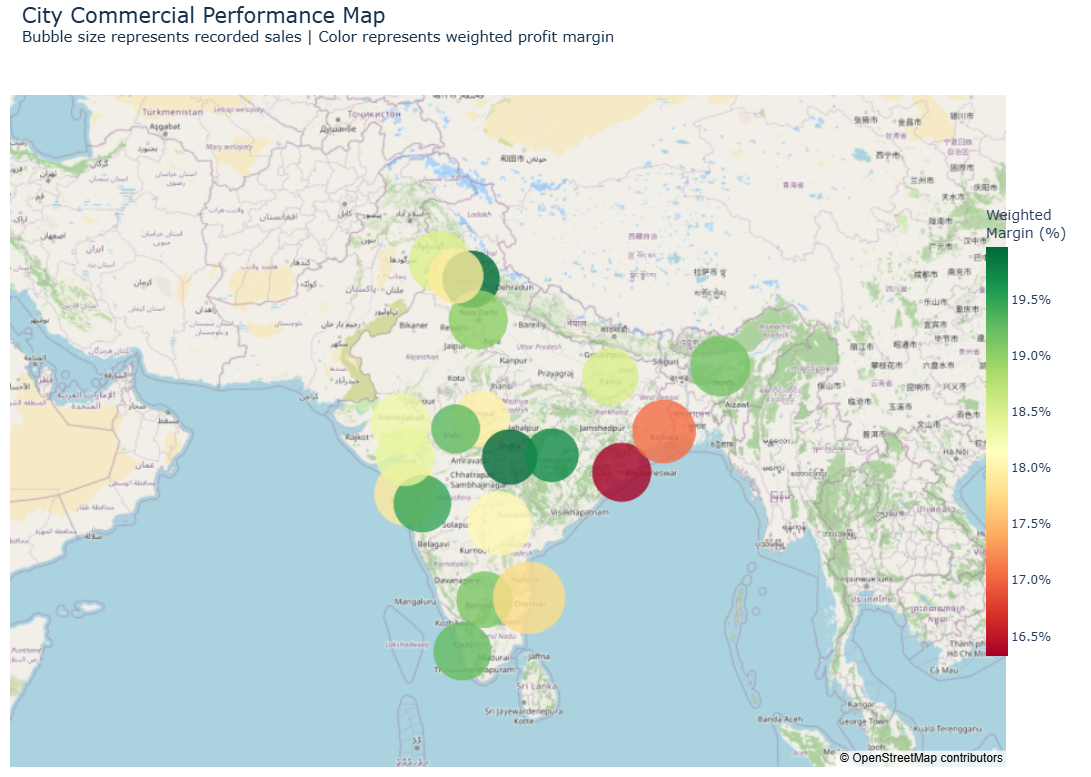

In [139]:
fig = px.scatter_mapbox(city_map_data,lat="latitude",lon="longitude",size="recorded_sales",color="weighted_profit_margin_pct",hover_name="city",
    hover_data={"region": True,
        "orders": ":,.0f",
        "customers": ":,.0f",
        "recorded_sales_display": True,
        "recorded_profit_display": True,
        "average_order_value_display": True,
        "weighted_margin_display": True,
        "return_rate_display": True,
        "cancellation_rate_display": True,
        "average_shipping_days": ":.2f",
        "average_satisfaction": ":.2f",
        "rating_coverage_pct": ":.2f",
        "latitude": False,
        "longitude": False,
        "recorded_sales": False,
        "weighted_profit_margin_pct": False},
    color_continuous_scale="RdYlGn",size_max=52,zoom=3.5,center={"lat": 22.6,"lon": 79.0},mapbox_style="open-street-map",
    title=("City Commercial Performance Map<br><sup>Bubble size represents recorded sales | Color represents weighted profit margin</sup>"),
    labels={"weighted_profit_margin_pct":"Weighted Margin (%)",
        "recorded_sales_display":"Recorded Sales",
        "recorded_profit_display":"Recorded Profit",
        "average_order_value_display":"Average Order Value",
        "weighted_margin_display":"Weighted Margin",
        "return_rate_display":"Return Rate",
        "cancellation_rate_display":"Cancellation Rate",
        "average_shipping_days":"Average Shipping Days",
        "average_satisfaction":"Average Satisfaction",
        "rating_coverage_pct":"Rating Coverage (%)"},
    template=PLOTLY_TEMPLATE)

fig.update_traces(marker={"opacity": 0.80})
fig.update_layout(width=1100,height=760,title={"x": 0.02,"xanchor": "left","y": 0.97,"yanchor": "top","font": {"size": 21,"color": COLORS["navy"]}},
    mapbox={"center": {"lat": 22.6,"lon": 79.0},"zoom": 3.55},
    margin={"l": 10,"r": 85,"t": 95,"b": 10},
    coloraxis_colorbar={"title": {"text": "Weighted<br>Margin (%)"},"x": 0.97,"xanchor": "left","y": 0.50,"yanchor": "middle","len": 0.70,"thickness": 22,"tickformat": ".1f","ticksuffix": "%","outlinewidth": 0},
    paper_bgcolor="white")
fig.show(config={"responsive": True,"displaylogo": False,"scrollZoom": True})

In [136]:
highest_sales_city = (city_map_data.loc[city_map_data["recorded_sales"].idxmax()])
highest_profit_city = (city_map_data.loc[city_map_data["recorded_profit"].idxmax()])
highest_margin_city = (city_map_data.loc[city_map_data["weighted_profit_margin_pct"].idxmax()])
highest_return_city = (city_map_data.loc[city_map_data["return_rate_pct"].idxmax()])
highest_cancellation_city = (city_map_data.loc[city_map_data["cancellation_rate_pct"].idxmax()])
highest_shipping_cost_city = (city_map_data.loc[city_map_data["average_shipping_cost"].idxmax()])
city_map_finding = (f"{highest_sales_city['city']} leads city-level recorded sales at {format_currency(highest_sales_city['recorded_sales'])}, while {highest_profit_city['city']} records the highest city-level profit. {highest_margin_city['city']} has the strongest weighted margin at {highest_margin_city['weighted_profit_margin_pct']:.2f}%. {highest_return_city['city']} has the highest return rate at {highest_return_city['return_rate_pct']:.2f}%, while {highest_cancellation_city['city']} has the highest cancellation rate.")
city_map_implication = ("City-level commercial leadership may differ from profitability and operational quality. A high-sales city with weaker margin, higher returns, or higher shipping costs may require improvement before additional growth investment is approved.")
city_map_recommendation = (f"The analyst recommends protecting commercial momentum in {highest_sales_city['city']}, investigating return drivers in {highest_return_city['city']}, reviewing cancellation drivers in {highest_cancellation_city['city']}, and assessing controlled growth opportunities in {highest_margin_city['city']}. Shipping economics should also be reviewed in {highest_shipping_cost_city['city']}.")
city_map_decision = ("Top management should determine city-level investment priorities, assign ownership for return, cancellation, and shipping-cost improvements, and approve criteria for targeted commercial expansion.")
city_map_monitoring_kpis = ["Recorded sales by city","Recorded profit by city","Weighted city profit margin","City share of total sales","Average order value","Return rate","Cancellation rate","Average shipping cost","Average shipping duration","Average satisfaction","Rating coverage"]
display_visual_interpretation(visual_title="City Commercial Performance Map",
    finding=city_map_finding,
    implication=city_map_implication,
    recommendation=city_map_recommendation,
    decision=city_map_decision,
    monitoring_kpis=city_map_monitoring_kpis,
    interpretation_note=("The map uses approximate city-center coordinates for visual placement only. The coordinates do not represent customer addresses, order locations, or delivery routes. Observed city differences may also reflect product-category and order-value mix."))

#### 📋 Consolidated Visual EDA Findings

The consolidated visual assessment integrates evidence from the univariate, bivariate, multivariate, and geographic analyses.

The objective is to identify the most material commercial, profitability, customer-experience, and operational priorities for executive review.

In [137]:
consolidated_visual_finding = (f"The visual analysis confirms that commercial scale, profitability, customer experience, and operational quality do not always move in the same direction. {highest_sales_category_row['product_category']} leads category recorded sales, while {highest_margin_category_row['product_category']} leads weighted category margin. {highest_sales_region_row['region']} leads regional sales, while {highest_margin_region_row['region']} leads regional margin. The {highest_sales_discount_row['discount_band']} discount band leads recorded sales, while the {highest_return_discount_row['discount_band']} band records the highest return exposure.")
consolidated_visual_implication = ("Top management should evaluate performance through an integrated commercial, profitability, customer-experience, and operating framework. Recorded sales alone do not identify the strongest categories, regions, discount policies, or customer segments.")
consolidated_visual_recommendation = ("The analyst recommends prioritizing category margin and return improvement, regional shipping-cost review, discount governance, incomplete-order monitoring, returned-order customer-experience analysis, and enhanced controls for high-value orders.")
consolidated_visual_decision = ("The executive team should approve priority improvement workstreams, functional ownership, KPI targets, reporting frequency, escalation criteria, and category and regional investment priorities.")
consolidated_visual_kpis = ["Recorded sales and recorded profit","Weighted profit margin","Average order value","Category and regional contribution","Return and cancellation rates","Shipping cost and duration","Order-status pipeline exposure","Average customer satisfaction","Rating coverage","High-value-order concentration",]
display_visual_interpretation(visual_title="Consolidated Visual EDA",
    finding=consolidated_visual_finding,
    implication=consolidated_visual_implication,
    recommendation=consolidated_visual_recommendation,
    decision=consolidated_visual_decision,
    monitoring_kpis=consolidated_visual_kpis,
    interpretation_note=("All findings are based on a synthetic dataset and should be validated using actual operational and financial information before implementation."),)

#### ✅ Visual EDA Conclusion


The visual analysis confirmed that annual, category, regional, discount, customer, fulfillment, and city-level performance varies according to the KPI being evaluated.

The visual findings provide the evidence base for the consolidated executive recommendations and final project conclusion.


### ⚠️ Project Assumptions and Limitations

- The dataset is synthetic and does not represent audited organizational performance.
- The analysis is descriptive and does not establish causality.
- Recorded sales and profit are analyzed as supplied by the dataset.
- Customer-satisfaction averages exclude orders without valid ratings.
- Status-change timestamps are unavailable, so formal order-aging analysis cannot be performed.
- Return reasons, cancellation reasons, promised delivery dates, and campaign identifiers are unavailable.
- City coordinates are approximate visualization anchors, not customer addresses or delivery routes.


## Final Project Conclusion

The project transformed 4,310 raw retail records into a validated analytical dataset containing 4,186 unique orders. Cleaning addressed duplicates, empty observations, mixed date formats, inconsistent categories, missing information, invalid numerical values, and confirmed extreme errors.

The non-visual and visual analyses show that commercial scale does not always correspond with stronger profitability, lower returns, better fulfillment, or higher customer satisfaction. Management decisions should therefore evaluate recorded sales, recorded profit, weighted margin, order outcomes, shipping performance, satisfaction, and feedback coverage together.

Because the dataset is synthetic, the findings should be treated as analytical demonstrations and validated using actual organizational data before implementation.


### Export Prepared Dataset


In [138]:
export_filename = "Retail_Sales_Prepared_for_EDA.csv"
df.to_csv(export_filename, index=False)
print("Prepared dataset exported successfully:")
print(export_filename)


Prepared dataset exported successfully:
Retail_Sales_Prepared_for_EDA.csv
